# B09 · Defend a prediction-cost comparison

Skill: authenticate rows, measure the entire prediction system, and interpret a Pareto frontier. PROVIDED cells supply data and plumbing; TODO cells are live implementations; CHECK cells give immediate feedback; EXIT requires your written defense.

[Lesson](https://avist.github.io/relational/lessons/b09-cost-frontier.html). This portable notebook replays saved author evidence. It does **not** download or rerun large checkpoints by default. Fresh inference is a separate operator below.

In [1]:
# @colab-bootstrap
import sys, subprocess, importlib.util
for package in ["numpy", "matplotlib"]:
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable,"-m","pip","install",package])
import numpy as np
import base64, hashlib, io, json, zipfile
from IPython.display import display, Markdown

## Concept recap

A support set contains labeled examples; a query set withholds targets. A frozen checkpoint performs inference without gradient updates, but its wrapper may prepare transforms or ensembles.

An operating point includes those transforms, context size, hardware, precision and cache. Warm prediction omits cold load and may omit support work. Absolute peak RSS includes Python/native runtime memory; it is not GPU memory.

**Worked example:** preparation/prediction costs A=(6,.02), B=(1,.08) seconds give A=6.02 and B=1.08 for one request. At 100 requests with cached support: A=8, B=9.

RMSE is the square root of mean squared errors on the same row identities. Errors [0,2] yield √2. A Pareto point has no competitor no worse on all cost axes and strictly better on one. Equal points do not dominate each other.

Predict: is a smaller checkpoint always cheaper? Explain which operation could reverse your answer.

## Model architecture · current EXAONE release

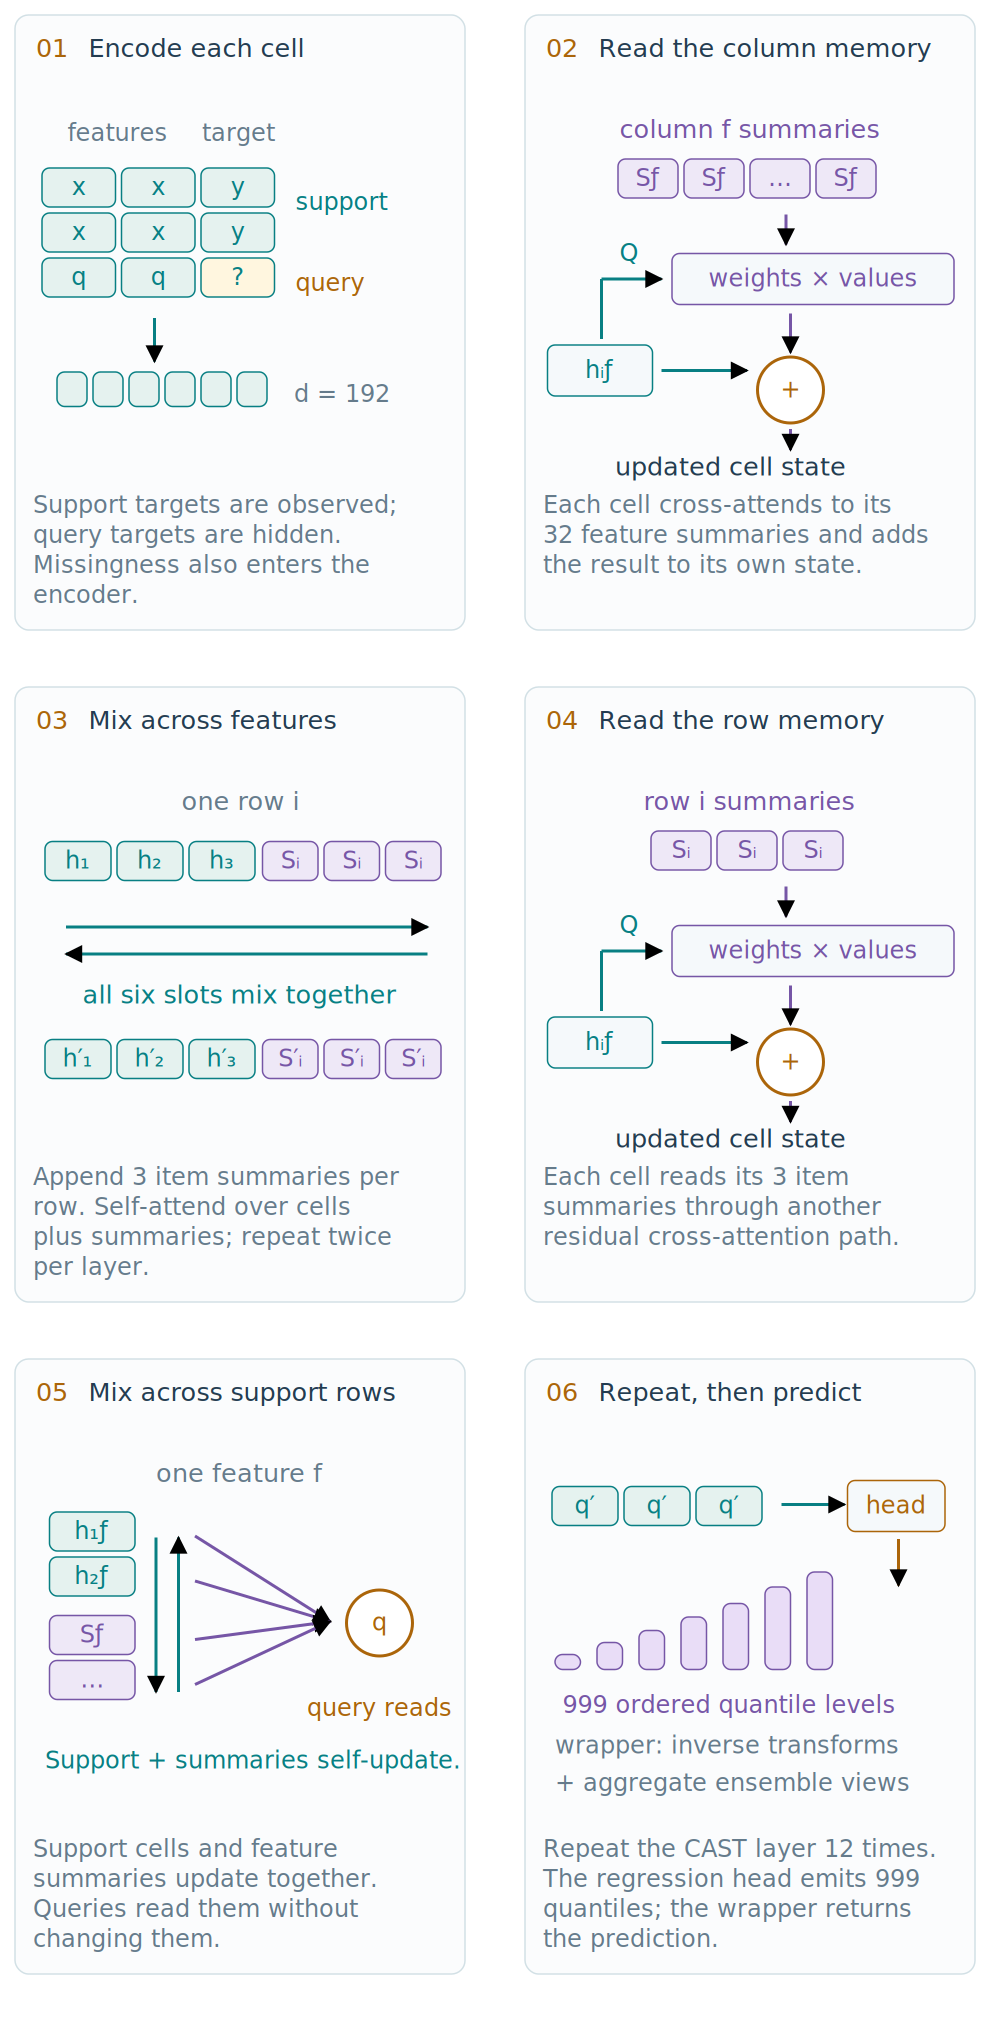

Cells carry vectors; item summaries collect columns for each row; feature summaries collect support rows for each column. Cells read the opposite-axis summaries before axis-wise attention. Current release: 12 layers, width 192, two feature-attention repetitions, 3 item slots and 32 feature slots. The regression head produces 999 quantiles before point aggregation. The portable visibility task is scaled dot-product attention, not full SSMax. Full inference source is visible in the appendix.

TabFM embeds numeric feature groups with Fourier features, alternates column/row attention, pools rows, then predicts through an ICL stack. Nori alternates feature/sample attention and decodes a quantile distribution. Their wrappers change work and evidence access; do not infer historical identity from names.

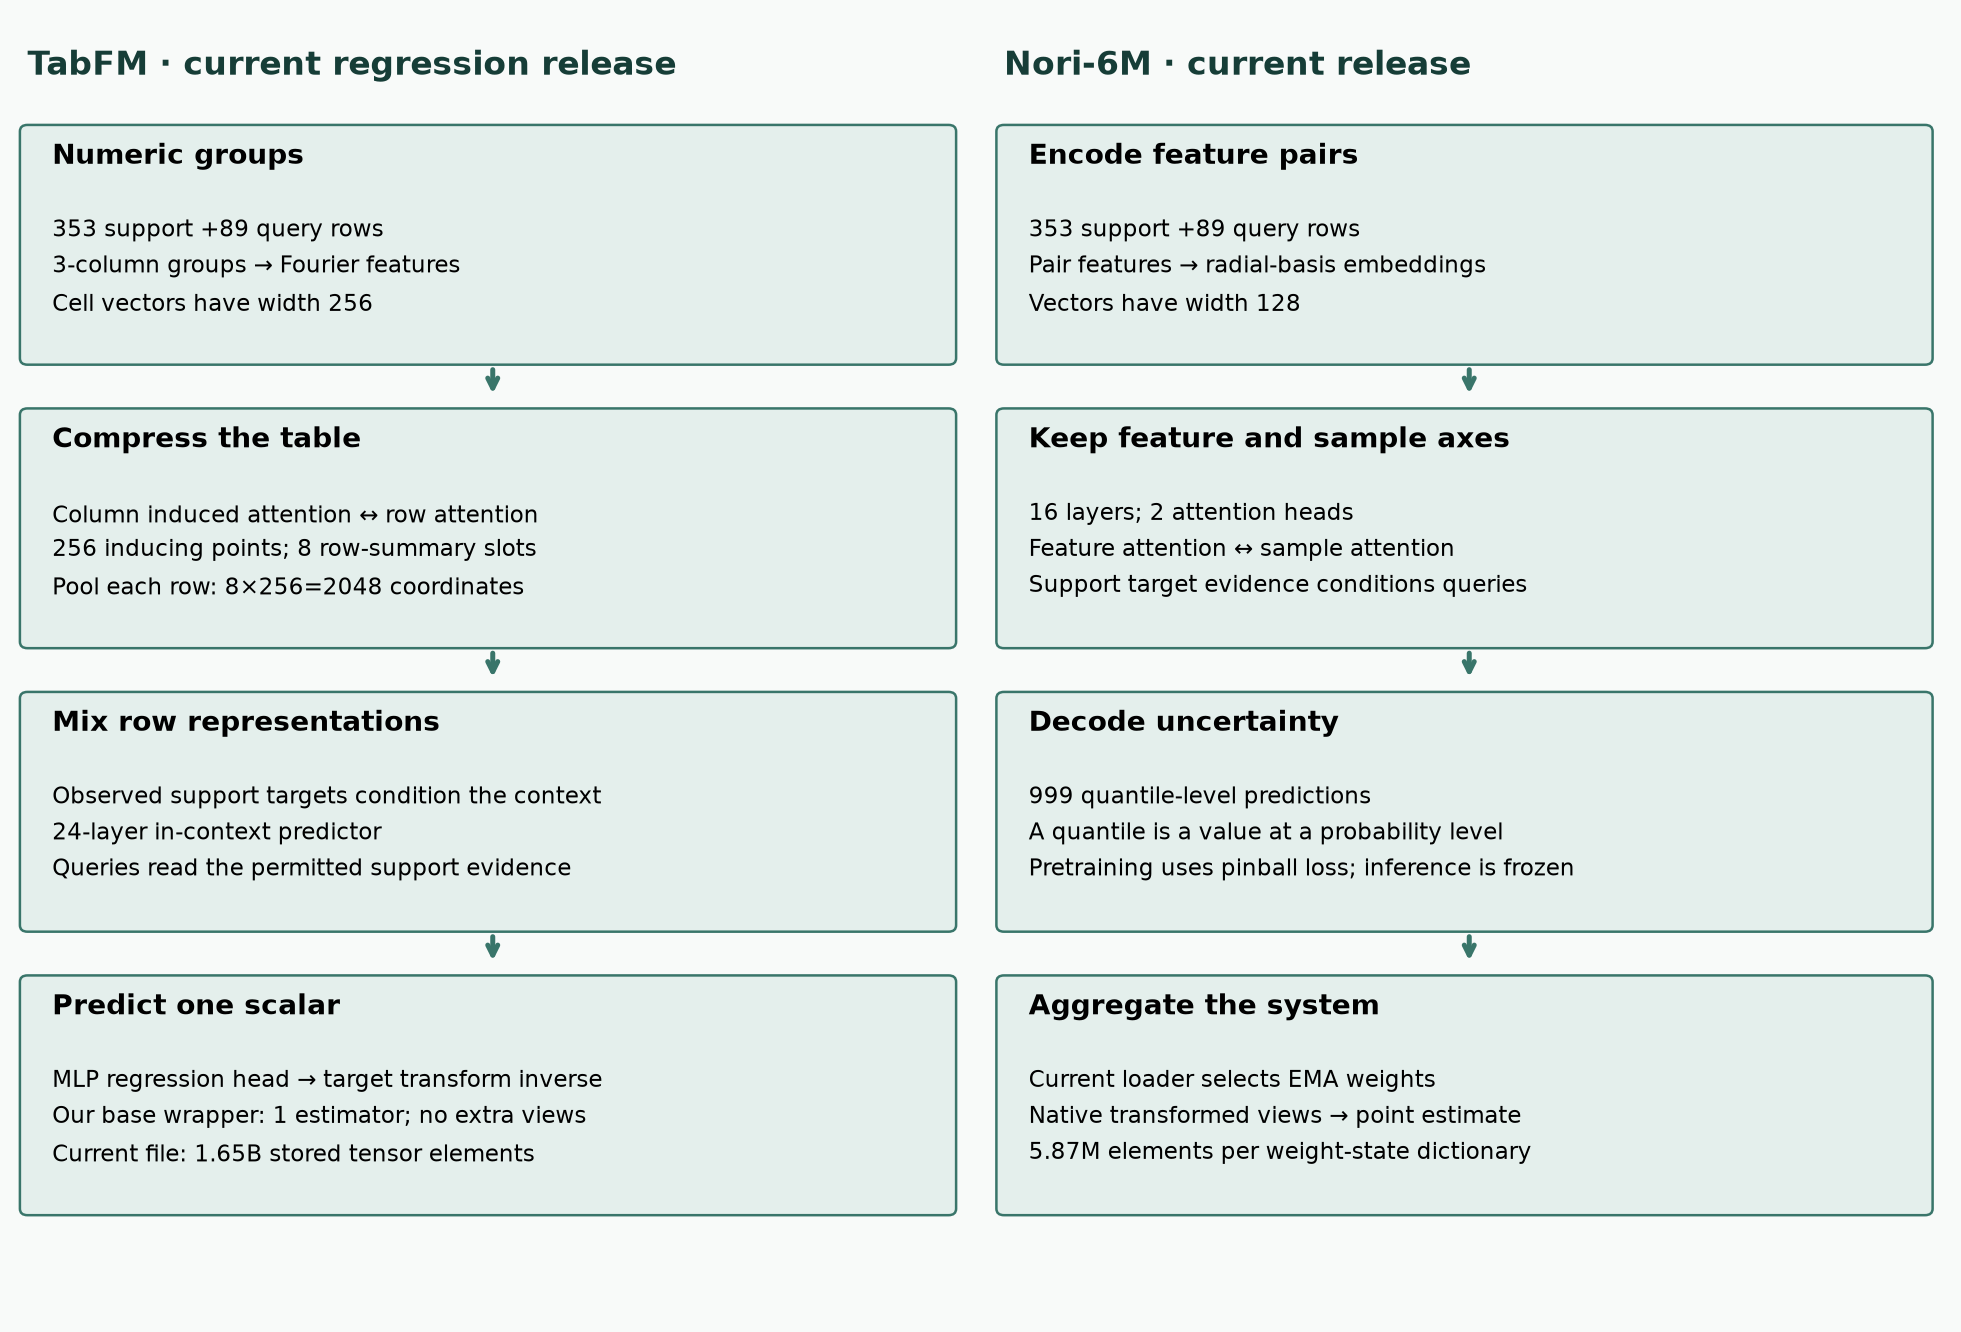

TabFM compresses rows before its ICL stack. Nori keeps alternating feature/sample axes. Source inspection is separate from executed checkpoint evidence.

## TODO 1 · aligned_rmse

**Goal:** Authenticate the complete query identity and calculate RMSE after alignment. Reject duplicate/missing/nonfinite entries.

**Why:** this contract prevents an apparently plausible but invalid benchmark conclusion. Implement the function; the CHECK uses an example different from the author dataset. Do not edit the CHECK.

In [2]:
def aligned_rmse(ids, truth, prediction_ids, predictions):
    """Authenticate full query identity before scoring; reject lost/duplicate rows."""
    ids=list(ids); prediction_ids=list(prediction_ids)
    truth=np.asarray(truth,dtype=float); predictions=np.asarray(predictions,dtype=float)
    if len(set(ids))!=len(ids) or len(set(prediction_ids))!=len(prediction_ids):
        raise ValueError('Duplicate query identity')
    if set(ids)!=set(prediction_ids) or truth.shape!=(len(ids),) or predictions.shape!=(len(ids),):
        raise ValueError('Query identity or shape mismatch')
    if not len(ids) or not np.isfinite(truth).all() or not np.isfinite(predictions).all():
        raise ValueError('Empty or nonfinite prediction packet')
    lookup=dict(zip(prediction_ids,predictions))
    errors=np.array([lookup[k] for k in ids])-truth
    return float(np.sqrt(np.mean(errors**2)))

In [3]:
# CHECK
assert abs(aligned_rmse([4,7],[2,6],[7,4],[8,2])-2**.5)<1e-12
for keys,values in [([4,4],[2,6]),([4,9],[2,6]),([4,7],[2,float('nan')])]:
    try: aligned_rmse([4,7],[2,6],keys,values)
    except ValueError: pass
    else: raise AssertionError('CHECK: duplicate, foreign or nonfinite rows must fail')
print('CHECK: reordered rows score correctly; corrupt packets fail')

CHECK: reordered rows score correctly; corrupt packets fail


## TODO 2 · pareto_front

**Goal:** Return a boolean for each nondominated point. All supplied axes are minimized; equal points must survive.

**Why:** this contract prevents an apparently plausible but invalid benchmark conclusion. Implement the function; the CHECK uses an example different from the author dataset. Do not edit the CHECK.

In [4]:
def pareto_front(points):
    """Keep points with no weakly better competitor that is strictly better somewhere."""
    p=np.asarray(points,dtype=float)
    if p.ndim!=2 or not np.isfinite(p).all():raise ValueError('Finite matrix required')
    return np.array([not np.any(np.all(p<=x,axis=1)&np.any(p<x,axis=1)) for x in p])

In [5]:
# CHECK
assert pareto_front([[1,2,4],[2,3,5],[2,1,4],[1,2,4]]).tolist()==[True,False,True,True]
print('CHECK: strict dominance and exact ties handled')

CHECK: strict dominance and exact ties handled


## TODO 3 · support_attention

**Goal:** Compute scaled dot-product attention using only the first support_count keys and values. A forbidden query must have no influence.

**Why:** this contract prevents an apparently plausible but invalid benchmark conclusion. Implement the function; the CHECK uses an example different from the author dataset. Do not edit the CHECK.

In [6]:
def support_attention(query, keys, values, support_count):
    """Illustrative scaled dot-product attention, not EXAONE SSMax or a checkpoint."""
    q=np.asarray(query,float);k=np.asarray(keys,float);v=np.asarray(values,float)
    if not 0<support_count<=len(k) or len(k)!=len(v):raise ValueError('Invalid support boundary')
    logits=q@k[:support_count].T/np.sqrt(q.shape[-1])
    logits-=logits.max(axis=-1,keepdims=True)
    weights=np.exp(logits);weights/=weights.sum(axis=-1,keepdims=True)
    return weights@v[:support_count]

In [7]:
# CHECK
q=np.array([[1.,0.]]);k=np.array([[0.,1.],[0.,-1.],[100.,0.]])
v=np.array([[2.],[6.],[999.]])
np.testing.assert_allclose(support_attention(q,k,v,2),[[4.]])
v[-1]=-1000
np.testing.assert_allclose(support_attention(q,k,v,2),[[4.]])
print('CHECK: forbidden query values cannot change the readout')

CHECK: forbidden query values cannot change the readout


## PROVIDED · authenticated author-reference packet

This is saved-evidence replay, not fresh inference. Raw diabetes features were split 80/20 using seeds0/1/2; support353, queries89. Each completed arm saved full query identities. No checkpoint is trained in this notebook. Source and weight hashes accompany the downloadable reproduction ledger.

In [8]:
payload=base64.b64decode('...')
assert hashlib.sha256(payload).hexdigest()=='7c2fbc3627a21025e52f47c083a7ff63aef3aef140f50d5f9e4f3960306f3ce0'
archive=zipfile.ZipFile(io.BytesIO(payload))
audit=json.loads(archive.read("audit.json"))
print(audit["status"], audit["completed"], "/", audit["expected"])

INCOMPLETE 6 / 9


In [9]:
# CHECK: your alignment function scores every complete author run.
records=[]
for row in audit['rows']:
    seed=row['seed'];model=row['model']
    d=np.load(io.BytesIO(archive.read(f'data/split-{seed}.npz')))
    p=np.load(io.BytesIO(archive.read(f'predictions/{model}-{seed}-predictions.npz')))
    score=aligned_rmse(d['test'],d['y'][d['test']],p['ids'],p['predictions'])
    assert abs(score-row['rmse'])<1e-9
    records.append((model,seed,score,row['warm_median_s'],row['peak_rss_mib']))
print('Authenticated completed runs:',len(records),'Missing:',audit['missing'])
if len(records)==9:
    points=np.array([[r[3],r[4],r[2]] for r in records])
    print('Run-level nondominated flags:',pareto_front(points).tolist())
else:
    print('No complete three-model frontier claim: missing arms remain visible.')

Authenticated completed runs: 6 Missing: ['tabfm/0', 'tabfm/1', 'tabfm/2']
No complete three-model frontier claim: missing arms remain visible.


## Author-reference results

**Course status: INCOMPLETE; 6/9 model–seed runs completed.**

| Model | Seed | RMSE ↓ | Load s | Fit s | First call s | Warm median s | Peak RSS MiB |
|---|---:|---:|---:|---:|---:|---:|---:|
| tabfm | 0 | INCOMPLETE_RESOURCE_GATE | — | — | — | — | — |
| tabfm | 1 | INCOMPLETE_RESOURCE_GATE | — | — | — | — | — |
| tabfm | 2 | INCOMPLETE_RESOURCE_GATE | — | — | — | — | — |
| exaone | 0 | 57.952 | 0.413 | 0.011 | 30.724 | 39.619 | 3599.941 |
| exaone | 1 | 55.997 | 0.592 | 0.002 | 32.166 | 35.299 | 3604.105 |
| exaone | 2 | 55.462 | 0.348 | 0.001 | 33.319 | 36.120 | 3605.309 |
| nori | 0 | 58.058 | 1.538 | 0.005 | 5.903 | 6.616 | 710.551 |
| nori | 1 | 56.767 | 1.433 | 0.001 | 6.316 | 5.949 | 711.105 |
| nori | 2 | 55.988 | 1.274 | 0.000 | 5.970 | 5.646 | 710.520 |

Times are seconds per **89 query rows**, not per 1,000. Warm = median of ten timed calls after first call and two warmups. Process peak RSS includes all stages. Downloads are excluded from the load column and charged to preparation. The first saved prediction array is scored; timed repetitions measure repeatability separately.

exaone: RMSE **56.470 ± 1.311**, mean ± sample SD over three splits. nori: RMSE **56.938 ± 1.046**, mean ± sample SD over three splits. 

**Incomplete arms:** tabfm/0, tabfm/1, tabfm/2. Consult the attempt log and budget ledger; missing results are not zero-cost or low-error points. TabFM stopped at a conservative resource preflight: its unmodified-loader memory allowance exceeds available RAM. No measured out-of-memory failure is claimed.

Paired **Nori minus EXAONE RMSE** by split: +0.106, +0.770, +0.526. Negative favors Nori. These are paired dataset splits, not independent datasets. The missing TabFM arm prevents a complete three-model frontier. Support-mean RMSE by split: 71.657, 73.260, 74.795. This baseline uses only support targets.

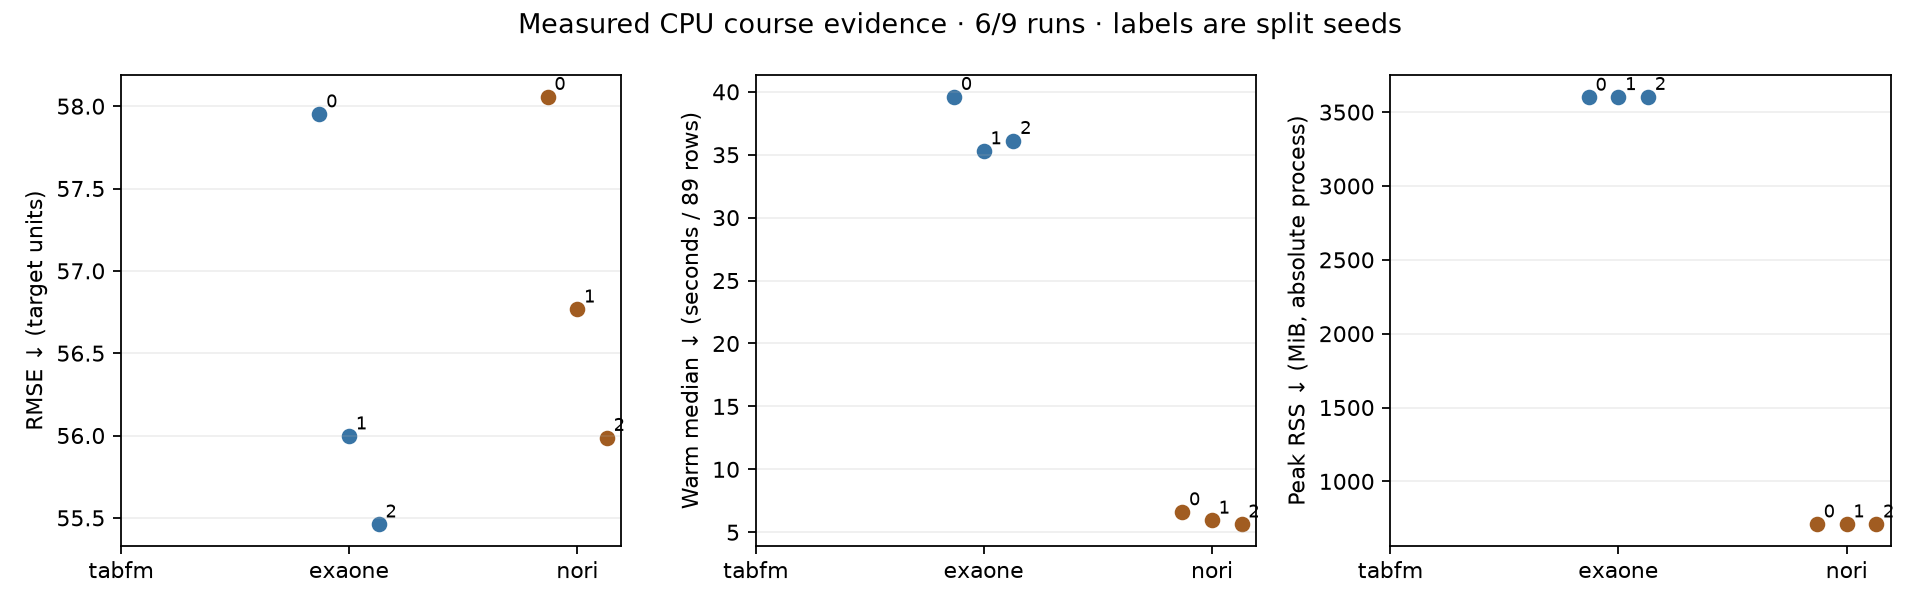

Labels are split seeds; each point is one completed model/split. Axes have different units. Missing points are unexecuted arms, never inferred values.

## EXIT · written defense

1. Explain why shuffled query IDs must be aligned before RMSE.
2. Choose a one-request or repeated-request workload and name every charged stage.
3. Defend what the completed matrix establishes and which missing arm blocks a stronger claim.
4. Distinguish current-release diabetes inference from historical Figure3(b).

Paste your answers to the tutor. Passing code leaves **PENDING_WRITTEN_DEFENSE**. Ask follow-up questions. Revisit the cost equation in1/7/30days after learner completion.

## Published-result gate and fresh inference

The exact target is EXAONE paper Figure3(b), regression accuracy–latency. Missing historical checkpoint/split/timing/Elo-pool identities block execution. No full pretraining or whole-paper claim is made.

From the repository root, follow `labs/b09-reproduction.md`; run `labs/_run_b09.py` only after pinned sources, weights and dependencies are ready and budget remains. The displayed worker below is the complete measurement operator. The saved notebook packet is intentionally a separate lane.

In [10]:
RUN_HISTORICAL_FIGURE=False
gate=json.loads(archive.read("gate.json"))
print(gate["status"],gate["gaps"])
if RUN_HISTORICAL_FIGURE:
    raise RuntimeError("Historical source protocol unresolved; no substitute run is allowed")

INCOMPLETE_SOURCE_PROTOCOL ['publication-era checkpoint/code mapping for every plotted variant', 'complete original outer-fold query/support identities and preprocessing', 'original measured hardware, precision, batching, warmup and caching per method', 'original TabArena baseline timing records and complete Elo comparison pool', 'regression-only timing aggregation matching Figure 3 rather than overall leaderboard cost']


### Visible measurement operator

```python
"""One fresh process/model/split. Timings exclude download, include wrapper work."""
import os,time,sys,json,resource,random,hashlib
from pathlib import Path
START=time.perf_counter();P=Path(__file__).resolve().parent
sys.path[:0]=['/tmp/b09-deps','/tmp/b09-src/tabfm','/tmp/b09-src/exaone/src','/tmp/b09-src/nori/src','/tmp/b09-src/nori/libs/synthefy/src']
import numpy as np
import torch
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from relkit.cost_b09 import aligned_rmse
name=sys.argv[1];seed=int(sys.argv[2]);E=P/'evidence/b09';out=E/f'{name}-{seed}.json'
torch.set_num_threads(4);torch.set_num_interop_threads(1);torch.manual_seed(seed);np.random.seed(seed);random.seed(seed)
x,y=load_diabetes(return_X_y=True,scaled=False);x=x.astype('float32');y=y.astype('float32')
train,test=train_test_split(np.arange(len(y)),test_size=.2,random_state=seed)
packet=P/f'data/b09/split-{seed}.npz'
if not packet.exists():np.savez(packet,x=x,y=y,train=train,test=test)
weights=Path('/tmp/b09-weights');t=time.perf_counter()
if name=='tabfm':
 from tabfm import TabFMRegressor,tabfm_v1_0_0_pytorch
 model=tabfm_v1_0_0_pytorch.load(model_type='regression',checkpoint_path=str(weights/'tabfm/regression'),device='cpu',dtype=torch.float32,use_cache=False)
 estimator=TabFMRegressor(model=model,n_estimators=1,norm_methods=['none'],feat_shuffle_method='none',random_state=seed,use_amp=False,cache_context=False)
 config=estimator.get_params();config['model']='pinned checkpoint';config={k:str(v) for k,v in config.items()}
elif name=='exaone':
 from exaonetabular import EXAONETabularRegressor
 estimator=EXAONETabularRegressor.from_pretrained(weights=str(weights/'exaone/exaone-tabular-regressor-v1_default.safetensors'),device='cpu',compute_dtype='float32',seed=seed)
 config=str(estimator.manifest)
else:
 from synthefy_nori import NoriRegressor
 estimator=NoriRegressor(model_path=str(weights/'nori/nori.pt'),device='cpu')
 config={k:str(v) for k,v in estimator.get_params().items()}
load_s=time.perf_counter()-t
t=time.perf_counter();estimator.fit(x[train],y[train]);fit_s=time.perf_counter()-t
t=time.perf_counter();pred=np.asarray(estimator.predict(x[test])).reshape(-1);first_s=time.perf_counter()-t
for _ in range(2):estimator.predict(x[test])
times=[];max_diff=0.
for _ in range(10):
 t=time.perf_counter();p=np.asarray(estimator.predict(x[test])).reshape(-1);times.append(time.perf_counter()-t);max_diff=max(max_diff,float(np.max(np.abs(p-pred))))
np.savez(E/f'{name}-{seed}-predictions.npz',ids=test,predictions=pred)
r=dict(model=name,seed=seed,status='COMPLETE',n_support=len(train),n_query=len(test),rmse=aligned_rmse(test,y[test],test,pred),load_s=load_s,fit_s=fit_s,first_predict_s=first_s,warm_s=times,warm_median_s=float(np.median(times)),warm_p90_s=float(np.quantile(times,.9)),peak_rss_mib=resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1024,repeat_max_abs_diff=max_diff,config=config,wall_s=time.perf_counter()-START,device='CPU',dtype='float32',threads=4,python=sys.version,torch=torch.__version__,numpy=np.__version__,input_sha256=hashlib.sha256(packet.read_bytes()).hexdigest())
out.write_text(json.dumps(r,indent=2));print(json.dumps(r,indent=2))

```

## Source-visible inference appendix

These are unmodified pinned release modules, provided for inspection with their licenses. They are not redefined or executed by the small visibility task. No unpublished pretraining trainer is invented. Full dependency modules are in the source archives. Follow the current wrapper configuration in each measured record; do not assume paper/release identity.

### EXAONE CAST layer

```python
"""Cross-Axis Summary Transformer (CAST) layer for classification models."""

from __future__ import annotations

import functools
import inspect
import math
import numbers
from typing import Any

import torch
from torch import nn
from torch.nn import functional as F

from exaonetabular.config import ModelConfig
from exaonetabular.model.attention import TensorAttention
from exaonetabular.model.mlp import FeedForward
from exaonetabular.runtime import FULL_FEATURE_ATTENTION_ROWS, run_in_chunks


_FLOAT_DTYPES = (torch.float16, torch.bfloat16, torch.float32, torch.float64)


def _config_value(config: ModelConfig, *names: str, default: Any = None) -> Any:
    for name in names:
        if hasattr(config, name):
            return getattr(config, name)
    return default


def _construct(component: type[nn.Module], values: dict[str, Any]) -> nn.Module:
    """Construct a frozen public primitive without coupling to spelling aliases."""
    signature = inspect.signature(component.__init__)
    kwargs: dict[str, Any] = {}
    missing: list[str] = []
    for name, parameter in signature.parameters.items():
        if name == "self" or parameter.kind in (
            inspect.Parameter.VAR_POSITIONAL,
            inspect.Parameter.VAR_KEYWORD,
        ):
            continue
        if name in values and values[name] is not None:
            kwargs[name] = values[name]
        elif parameter.default is inspect.Parameter.empty:
            missing.append(name)
    if missing:
        raise TypeError(
            f"Cannot construct {component.__name__}; unsupported required arguments: "
            + ", ".join(missing)
        )
    return component(**kwargs)


class CrossAxisSummaryLayer(nn.Module):
    """Mix item-summary and feature-summary states with item-by-feature cell states.

    Item-summary tokens have shape ``[batch, items, item_slots, width]`` and
    are concatenated with cells along the feature axis. Feature-summary tokens
    have shape ``[batch, feature_slots, features, width]`` and are concatenated
    with support cells along the item axis. Before each axis-wise self-attention,
    cells read from the summary state attached to the opposite axis.
    """

    def __init__(
        self,
        config: ModelConfig,
        expanded_width: int,
        *,
        activation: str = "gelu",
        layer_norm_epsilon: float = 1e-5,
        final_layer: bool = False,
        initial_head_scale: float = 0.43,
        score_scale: float | None = None,
        device: torch.device | str | None = None,
        dtype: torch.dtype | None = None,
        zero_residual_branches: bool = False,
    ) -> None:
        super().__init__()
        if not isinstance(config, ModelConfig):
            raise TypeError("config must be a ModelConfig")
        if isinstance(expanded_width, bool) or not isinstance(expanded_width, int):
            raise TypeError("expanded_width must be an integer")
        if expanded_width <= 0:
            raise ValueError("expanded_width must be positive")
        if not isinstance(activation, str):
            raise TypeError("activation must be a string")
        if activation not in ("gelu", "relu"):
            raise ValueError("activation must be 'gelu' or 'relu'")
        for name, value, positive in (
            ("layer_norm_epsilon", layer_norm_epsilon, True),
            ("initial_head_scale", initial_head_scale, False),
            ("score_scale", score_scale, True),
        ):
            if value is None and name == "score_scale":
                continue
            if isinstance(value, bool) or not isinstance(value, numbers.Real):
                raise TypeError(f"{name} must be a real scalar")
            if not math.isfinite(float(value)) or (positive and value <= 0):
                raise ValueError(f"invalid {name}")
        if not isinstance(final_layer, bool):
            raise TypeError("final_layer must be bool")
        if not isinstance(zero_residual_branches, bool):
            raise TypeError("zero_residual_branches must be bool")
        if dtype is not None and not isinstance(dtype, torch.dtype):
            raise TypeError("dtype must be a torch.dtype or None")
        if dtype is not None and dtype not in _FLOAT_DTYPES:
            raise ValueError("unsupported dtype")

        self.width = int(config.width)
        self.feature_summary_count = int(config.feature_summary_count)
        self.item_summary_count = int(config.item_summary_count)
        self.feature_attention_repeats = int(config.feature_attention_repeats)
        self.layer_norm_epsilon = float(layer_norm_epsilon)
        self.final_layer = final_layer

        common = {
            "width": self.width,
            "embedding_width": self.width,
            "embedding_dim": self.width,
            "model_width": self.width,
            "dim": self.width,
            "initial_head_scale": initial_head_scale,
            "head_scale": initial_head_scale,
            "score_scale": score_scale,
            # Absent from the frozen ModelConfig, so the per-call policy applies
            # unless a caller's config pins one kernel for the whole model.
            "sdpa_backend": _config_value(config, "sdpa_backend"),
            "device": device,
            "dtype": dtype,
        }
        feature_heads = _config_value(
            config,
            "feature_attention_heads",
            "feature_head_count",
            "feature_heads",
            "num_feature_heads",
            "attention_heads",
            "head_count",
            "num_heads",
        )
        item_heads = _config_value(
            config,
            "item_attention_heads",
            "item_head_count",
            "item_heads",
            "num_item_heads",
            "attention_heads",
            "head_count",
            "num_heads",
            default=feature_heads,
        )
        item_kv_heads = _config_value(
            config,
            "item_attention_kv_heads",
            "item_kv_head_count",
            "item_kv_heads",
            "num_item_kv_heads",
            default=item_heads,
        )

        def attention(
            heads: Any, kv_heads: Any = None, *, sdpa_backend: Any = None
        ) -> TensorAttention:
            values = dict(common)
            if sdpa_backend is not None:
                values["sdpa_backend"] = sdpa_backend
            values.update(
                {
                    "heads": heads,
                    "num_heads": heads,
                    "head_count": heads,
                    "query_heads": heads,
                    "kv_heads": kv_heads,
                    "num_kv_heads": kv_heads,
                    "kv_head_count": kv_heads,
                    "key_value_heads": kv_heads,
                }
            )
            return _construct(TensorAttention, values)  # type: ignore[return-value]

        self.feature_attentions = nn.ModuleList(
            attention(feature_heads) for _ in range(self.feature_attention_repeats)
        )
        # Rows are this call's sequence axis *and* the axis row-chunking splits,
        # so a per-call kernel choice here would follow the memory budget.
        self.feature_context_attentions = nn.ModuleList(
            attention(feature_heads, sdpa_backend=common["sdpa_backend"] or "flash")
            for _ in range(
                self.feature_attention_repeats
                if self.feature_summary_count > 1
                else 0
            )
        )
        self.item_attention = attention(item_heads, item_kv_heads)
        self.item_context_attention = (
            attention(item_heads) if self.item_summary_count > 1 else None
        )

        ff_values = {
            "width": self.width,
            "embedding_width": self.width,
            "embedding_dim": self.width,
            "model_width": self.width,
            "input_width": self.width,
            "dim": self.width,
            "expanded_width": expanded_width,
            "hidden_width": expanded_width,
            "intermediate_width": expanded_width,
            "hidden_dim": expanded_width,
            "activation": activation,
            "device": device,
            "dtype": dtype,
        }

        def feedforward() -> FeedForward:
            return _construct(FeedForward, ff_values)  # type: ignore[return-value]

        self.state_feedforward = feedforward()
        self.feature_summary_feedforward = None if final_layer else feedforward()
        self.item_summary_feedforward = None if final_layer else feedforward()

        self._cached_feature_input: torch.Tensor | None = None
        self._cached_summary_rows: torch.Tensor | None = None
        self._cached_support_rows: int | None = None

        if zero_residual_branches:
            with torch.no_grad():
                for module in self.modules():
                    if isinstance(module, TensorAttention):
                        module.output_weight.zero_()
                    elif isinstance(module, FeedForward):
                        module.projection_weight.zero_()

    @property
    def has_cached_support(self) -> bool:
        return (
            self._cached_feature_input is not None
            and self._cached_summary_rows is not None
            and self._cached_support_rows is not None
            and self.item_attention.has_cached_context
        )

    def clear_cache(self) -> None:
        self._cached_feature_input = None
        self._cached_summary_rows = None
        self._cached_support_rows = None
        self.item_attention.clear_cache()

    def reload_support_cache(self, device: torch.device | str) -> None:
        """Restore this layer's offloaded item-attention K/V onto ``device``."""
        self.item_attention.reload_cached_context(device)

    @staticmethod
    def _attention(
        module: TensorAttention,
        query: torch.Tensor,
        context: torch.Tensor | None = None,
        *,
        shared_context_head: bool = False,
        cache_context: bool = False,
        use_cached_context: bool = False,
    ) -> torch.Tensor:
        return module(
            query,
            context,
            cache_context=cache_context,
            use_cached_context=use_cached_context,
            reuse_first_context_head=shared_context_head,
        )

    @staticmethod
    def _feedforward(
        module: FeedForward,
        value: torch.Tensor,
        token_chunk: int,
    ) -> torch.Tensor:
        flat = value.reshape(-1, value.shape[-1])

        def apply(chunk: torch.Tensor) -> torch.Tensor:
            return module(chunk, add_residual=True)

        if flat.shape[0] <= token_chunk:
            return apply(flat).reshape_as(value)
        chunks = [
            apply(flat[start : start + token_chunk])
            for start in range(0, flat.shape[0], token_chunk)
        ]
        return torch.cat(chunks, dim=0).reshape_as(value)

    def _normalize(self, value: torch.Tensor) -> torch.Tensor:
        return F.layer_norm(value, (self.width,), eps=self.layer_norm_epsilon)

    def _validate_inputs(
        self,
        state: torch.Tensor,
        feature_summary: torch.Tensor,
        item_summary: torch.Tensor,
        support_size: int,
        cache_support: bool,
        cache_support_to_cpu: bool,
        use_cached_support: bool,
        compact_cached_support: bool,
    ) -> None:
        for name, value in (
            ("state", state),
            ("feature_summary", feature_summary),
            ("item_summary", item_summary),
        ):
            if not isinstance(value, torch.Tensor):
                raise TypeError(f"{name} must be a tensor")
            if value.dtype not in _FLOAT_DTYPES:
                raise TypeError(f"{name} has an unsupported dtype")
            if value.ndim != 4:
                raise ValueError(f"{name} must have rank four")
            if any(size <= 0 for size in value.shape):
                raise ValueError(f"{name} dimensions must be positive")
        batch, rows, groups, width = state.shape
        if width != self.width:
            raise ValueError("state width does not match config")
        if feature_summary.shape != (
            batch,
            self.feature_summary_count,
            groups,
            width,
        ):
            raise ValueError("feature_summary shape is incompatible")
        if item_summary.shape != (batch, rows, self.item_summary_count, width):
            raise ValueError("item_summary shape is incompatible")
        if (
            not isinstance(cache_support, bool)
            or not isinstance(cache_support_to_cpu, bool)
            or not isinstance(use_cached_support, bool)
            or not isinstance(compact_cached_support, bool)
        ):
            raise TypeError("cache options must be bool")
        if cache_support and use_cached_support:
            raise ValueError("cache options are mutually exclusive")
        if cache_support_to_cpu and not cache_support:
            raise ValueError("CPU offload requires cache_support")
        if compact_cached_support and not use_cached_support:
            raise ValueError("compact cache execution requires use_cached_support")
        if isinstance(support_size, bool) or not isinstance(support_size, int):
            raise ValueError("support_size must be an integer")
        if use_cached_support:
            if (
                self._cached_support_rows is None
                or support_size != self._cached_support_rows
                or (not compact_cached_support and support_size >= rows)
            ):
                raise ValueError(
                    "cached calls require the fitted support prefix and query rows"
                )
        elif support_size < 1 or support_size > rows:
            raise ValueError("support_size is outside the row range")
        if cache_support and support_size <= 0:
            raise ValueError("cache writes require positive support_size")

        if state.dtype != feature_summary.dtype or state.dtype != item_summary.dtype:
            raise ValueError("input dtypes differ")
        if state.device != feature_summary.device or state.device != item_summary.device:
            raise ValueError("input devices differ")
        parameter = next(self.parameters())
        if state.dtype != parameter.dtype or state.device != parameter.device:
            raise ValueError("inputs do not match module parameter placement")

    def _feature_attention_block(
        self,
        state_block: torch.Tensor,
        item_summary_block: torch.Tensor,
        *,
        feature_summary: torch.Tensor,
        attention: TensorAttention,
        repeat: int,
        label_group_only: bool,
    ) -> torch.Tensor:
        """Run one feature-attention repeat over a block of rows.

        Items are a batch axis in feature attention, so every item block is
        processed independently. Its cells first read the shared, read-only
        ``feature_summary`` states associated with their features, using
        cross-attention when multiple feature-summary slots are configured. The
        returned token block is ``item_summary`` concatenated with the
        feature-contextualized ``state`` along the feature axis (dim 2), already
        normalized. LayerNorm is token-wise over ``width``, so normalizing the
        joined block equals normalizing the two halves separately. This is what
        makes the chunked and full-row paths agree.
        """
        if self.feature_summary_count == 1:
            feature_context = state_block + feature_summary[:, 0].unsqueeze(1)
        else:
            query = state_block.transpose(1, 2)
            context = feature_summary.transpose(1, 2)
            mixed = self._attention(
                self.feature_context_attentions[repeat], query, context
            ).transpose(1, 2)
            feature_context = state_block + mixed
        joined = torch.cat((item_summary_block, feature_context), dim=2)
        if label_group_only:
            # Standard output consumes only the final label group. The last
            # feature-attention repeat still attends to the complete token
            # context, but feature-group queries have no later consumer in the
            # final transformer layer.
            selected = torch.cat(
                (joined[:, :, : self.item_summary_count], joined[:, :, -1:]),
                dim=2,
            )
            selected = selected + self._attention(attention, selected, joined)
            return self._normalize(selected)
        joined = joined + self._attention(attention, joined)
        return self._normalize(joined)

    def forward(
        self,
        state: torch.Tensor,
        feature_summary: torch.Tensor,
        item_summary: torch.Tensor,
        support_size: int,
        *,
        feedforward_token_chunk: int,
        feature_attention_row_chunk: int = FULL_FEATURE_ATTENTION_ROWS,
        cache_support: bool = False,
        cache_support_to_cpu: bool = False,
        use_cached_support: bool = False,
        compact_cached_support: bool = False,
        output_support: bool = True,
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        if (
            isinstance(feedforward_token_chunk, bool)
            or not isinstance(feedforward_token_chunk, int)
        ):
            raise TypeError("feedforward_token_chunk must be an integer")
        if feedforward_token_chunk <= 0:
            raise ValueError("feedforward_token_chunk must be positive")
        if (
            isinstance(feature_attention_row_chunk, bool)
            or not isinstance(feature_attention_row_chunk, int)
        ):
            raise TypeError("feature_attention_row_chunk must be an integer")
        if feature_attention_row_chunk <= 0:
            raise ValueError("feature_attention_row_chunk must be positive")
        if not isinstance(output_support, bool):
            raise TypeError("output_support must be bool")
        if not output_support and not self.final_layer:
            raise ValueError("support output may only be omitted in the final layer")
        self._validate_inputs(
            state,
            feature_summary,
            item_summary,
            support_size,
            cache_support,
            cache_support_to_cpu,
            use_cached_support,
            compact_cached_support,
        )
        feature_input = feature_summary
        cache_summary_rows: torch.Tensor | None = None
        label_group_only = False
        if use_cached_support:
            if not self.has_cached_support:
                raise RuntimeError("support cache is unavailable")
            assert self._cached_feature_input is not None
            assert self._cached_summary_rows is not None
            cached = self._cached_summary_rows
            if (
                cached.shape[0] != state.shape[0]
                or cached.shape[2] != state.shape[2]
                or cached.dtype != state.dtype
                or cached.device != state.device
                or not torch.equal(feature_summary, self._cached_feature_input)
            ):
                raise RuntimeError("inputs are incompatible with the support cache")

        for repeat, attention in enumerate(self.feature_attentions):
            # Row-independent, so decided once and shared by every row block.
            label_group_only = (
                not output_support
                and repeat == len(self.feature_attentions) - 1
                and "forward" not in attention.__dict__
            )
            block = functools.partial(
                self._feature_attention_block,
                feature_summary=feature_summary,
                attention=attention,
                repeat=repeat,
                label_group_only=label_group_only,
            )
            rows = state.shape[1]
            if feature_attention_row_chunk >= rows:
                combined = block(state, item_summary)
            else:
                combined = run_in_chunks(
                    block,
                    state,
                    item_summary,
                    chunk_size=feature_attention_row_chunk,
                    axis=1,
                )
            item_summary = combined[:, :, : self.item_summary_count]
            state = combined[:, :, self.item_summary_count :]
            feature_summary = self._normalize(feature_summary)
            if label_group_only:
                # Keep a full-group shape only for cache compatibility checks;
                # every downstream computation and the classifier need the
                # appended label group alone.
                cache_summary_rows = feature_summary
                feature_summary = feature_summary[:, :, -1:, :]

        if self.item_summary_count == 1:
            item_context = state + item_summary[:, :, 0].unsqueeze(2)
        else:
            assert self.item_context_attention is not None
            item_context = state + self._attention(
                self.item_context_attention, state, item_summary
            )

        if not use_cached_support:
            context_rows = torch.cat(
                (feature_summary, item_context[:, :support_size]), dim=1
            )

            # Feature-summary tokens prefix the support items along the item axis,
            # which is processed independently for each feature group.
            context_sequence = context_rows.transpose(1, 2)
            retain_context = cache_support or item_context.shape[1] > support_size
            if output_support:
                updated_prefix = context_sequence + self._attention(
                    self.item_attention,
                    context_sequence,
                    cache_context=retain_context,
                )
                updated_prefix = updated_prefix.transpose(1, 2)
                summary_rows = updated_prefix[:, : self.feature_summary_count]
            else:
                self.item_attention.cache_context_projections(
                    context_sequence, first_head_only=True
                )
                updated_prefix = None
                summary_rows = feature_summary
            if retain_context and output_support:
                # Query cross-attention requests only the first context head.
                # Release the unused projected heads before advancing to the
                # next layer so a 50k-row cache remains practical.
                self.item_attention.retain_first_cached_context_head()
        else:
            assert self._cached_summary_rows is not None
            summary_rows = (
                self._cached_summary_rows[:, :, -1:, :]
                if label_group_only
                else self._cached_summary_rows
            )

        if use_cached_support:
            query_rows = (
                item_context
                if compact_cached_support
                else item_context[:, support_size:]
            )
            updated_support = None
        else:
            updated_support = (
                updated_prefix[:, self.feature_summary_count :]
                if output_support
                else item_context[:, :support_size]
            )
            query_rows = item_context[:, support_size:]

        if query_rows.shape[1]:
            # Query items are absent from the context, so they share the same
            # feature-summary-plus-support sequence without interacting with one another.
            query_sequence = query_rows.transpose(1, 2)
            try:
                if self.item_attention.has_cached_context:
                    attended = self._attention(
                        self.item_attention,
                        query_sequence,
                        shared_context_head=True,
                        use_cached_context=True,
                    ).transpose(1, 2)
                else:
                    attended = self._attention(
                        self.item_attention,
                        query_sequence,
                        context_sequence,
                        shared_context_head=True,
                    ).transpose(1, 2)
            finally:
                if not cache_support and not use_cached_support:
                    self.item_attention.clear_cache()
            updated_query = query_rows + attended
        else:
            updated_query = query_rows

        if use_cached_support:
            if compact_cached_support:
                state = updated_query
            else:
                # Preserve the ordinary joined row count and query row positions.
                # Prefix values are padding from this point: every support-derived
                # cross-row value comes from the fitted layer cache.
                state = torch.cat((state[:, :support_size], updated_query), dim=1)
        else:
            assert updated_support is not None
            state = torch.cat((updated_support, updated_query), dim=1)
        feature_summary = summary_rows

        if (
            not output_support
            and (label_group_only or state.shape[2] >= 64)
        ):
            query_state = self._normalize(updated_query)
            query_state = self._feedforward(
                self.state_feedforward,
                query_state,
                feedforward_token_chunk,
            )
            query_state = self._normalize(query_state)
            if compact_cached_support:
                state = query_state
            elif use_cached_support:
                state = torch.cat((state[:, :support_size], query_state), dim=1)
            else:
                assert updated_support is not None
                state = torch.cat((updated_support, query_state), dim=1)
            if cache_support:
                self._cached_feature_input = feature_input.detach().clone()
                selected_summary = (
                    cache_summary_rows
                    if cache_summary_rows is not None
                    else summary_rows
                )
                self._cached_summary_rows = selected_summary.detach().clone()
                self._cached_support_rows = support_size
                if cache_support_to_cpu:
                    self.item_attention.offload_cached_context()
            return state, feature_summary, item_summary

        state = self._normalize(state)
        feature_summary = self._normalize(feature_summary)
        item_summary = self._normalize(item_summary)

        state = self._feedforward(
            self.state_feedforward,
            state,
            feedforward_token_chunk,
        )
        if not self.final_layer:
            assert self.feature_summary_feedforward is not None
            assert self.item_summary_feedforward is not None
            feature_summary = self._feedforward(
                self.feature_summary_feedforward,
                feature_summary,
                feedforward_token_chunk,
            )
            item_summary = self._feedforward(
                self.item_summary_feedforward,
                item_summary,
                feedforward_token_chunk,
            )
        state = self._normalize(state)
        feature_summary = self._normalize(feature_summary)
        item_summary = self._normalize(item_summary)

        if cache_support:
            self._cached_feature_input = feature_input.detach().clone()
            selected_summary = (
                cache_summary_rows if cache_summary_rows is not None else summary_rows
            )
            self._cached_summary_rows = selected_summary.detach().clone()
            self._cached_support_rows = support_size
            if cache_support_to_cpu:
                self.item_attention.offload_cached_context()

        return state, feature_summary, item_summary

```

### EXAONE stack and readout

```python
"""Cross-Axis Summary Transformer (CAST) stack used by the classification model."""

from __future__ import annotations

import math
import numbers
from collections.abc import Callable
from typing import TypeVar

import torch
from torch import nn

from exaonetabular.config import ModelConfig
from exaonetabular.model.layer import CrossAxisSummaryLayer
from exaonetabular.runtime import FULL_FEATURE_ATTENTION_ROWS


_T = TypeVar("_T", bound=torch.Tensor)
_FLOAT_DTYPES = {torch.float16, torch.bfloat16, torch.float32, torch.float64}


def run_in_chunks(
    function: Callable[[torch.Tensor], _T],
    value: torch.Tensor,
    chunk_size: int,
    *,
    add_input: bool = False,
) -> _T:
    """Evaluate ``function`` over consecutive leading-axis slices."""

    # An empty input still has to pass through the module once.  Besides being
    # useful for hooks, this lets Linear determine the correctly shaped result.
    if value.shape[0] == 0:
        result = function(value)
        return result + value if add_input else result

    pieces = []
    for start in range(0, value.shape[0], chunk_size):
        source = value[start : start + chunk_size]
        result = function(source)
        pieces.append(result + source if add_input else result)
    return torch.cat(pieces, dim=0)  # type: ignore[return-value]


class CrossAxisSummaryTransformer(nn.Module):
    """Apply CAST layers with item summaries on feature-axis sequences and feature
    summaries on item-axis sequences, then decode query-item readouts.
    """

    def __init__(
        self,
        config: ModelConfig,
        *,
        activation: str = "gelu",
        layer_norm_epsilon: float = 1e-5,
        initial_head_scale: float = 0.43,
        score_scale: float | None = None,
        output_width: int | None = None,
        decoder_hidden_width: int | None = None,
        device: torch.device | str | None = None,
        dtype: torch.dtype | None = None,
        zero_residual_branches: bool = False,
    ) -> None:
        super().__init__()
        self._validate_constructor(
            config,
            activation,
            layer_norm_epsilon,
            initial_head_scale,
            score_scale,
            output_width,
            decoder_hidden_width,
            dtype,
            zero_residual_branches,
        )

        factory = {"device": device, "dtype": dtype}
        self.layers = nn.ModuleList(
            CrossAxisSummaryLayer(
                config,
                config.feedforward_widths[index],
                activation=activation,
                layer_norm_epsilon=float(layer_norm_epsilon),
                initial_head_scale=float(initial_head_scale),
                score_scale=None if score_scale is None else float(score_scale),
                final_layer=index == config.block_count - 1,
                device=device,
                dtype=dtype,
                zero_residual_branches=zero_residual_branches,
            )
            for index in range(config.block_count)
        )

        self.feature_summary_tokens = nn.Parameter(
            torch.empty(1, config.feature_summary_count, 1, config.width, **factory)
        )
        self.item_summary_tokens = nn.Parameter(
            torch.empty(1, 1, config.item_summary_count, config.width, **factory)
        )
        nn.init.normal_(self.feature_summary_tokens, std=float(initial_head_scale))
        nn.init.normal_(self.item_summary_tokens, std=float(initial_head_scale))

        hidden_width = (
            config.feedforward_widths[-1]
            if decoder_hidden_width is None
            else decoder_hidden_width
        )
        resolved_output_width = (
            config.class_capacity if output_width is None else output_width
        )
        self.classification_heads = nn.ModuleDict(
            {
                "standard": nn.Sequential(
                    nn.Linear(config.width, hidden_width, **factory),
                    nn.GELU(),
                    nn.Linear(hidden_width, resolved_output_width, **factory),
                )
            }
        )
        self._width = config.width
        self._class_capacity = resolved_output_width

    @staticmethod
    def _validate_constructor(
        config: ModelConfig,
        activation: object,
        layer_norm_epsilon: object,
        initial_head_scale: object,
        score_scale: object,
        output_width: object,
        decoder_hidden_width: object,
        dtype: object,
        zero_residual_branches: object,
    ) -> None:
        if not isinstance(config, ModelConfig):
            raise TypeError("config must be a ModelConfig")
        if not isinstance(activation, str):
            raise TypeError("activation must be a string")
        if activation not in {"gelu", "relu"}:
            raise ValueError("unsupported activation")

        def real(name: str, value: object, *, positive: bool) -> None:
            if isinstance(value, bool) or not isinstance(value, numbers.Real):
                raise TypeError(f"{name} must be a real scalar")
            number = float(value)
            if not math.isfinite(number) or (positive and number <= 0):
                raise ValueError(f"invalid {name}")

        real("layer_norm_epsilon", layer_norm_epsilon, positive=True)
        real("initial_head_scale", initial_head_scale, positive=False)
        if score_scale is not None:
            real("score_scale", score_scale, positive=True)
        for name, value in (
            ("output_width", output_width),
            ("decoder_hidden_width", decoder_hidden_width),
        ):
            if value is not None and (
                isinstance(value, bool) or not isinstance(value, int)
            ):
                raise TypeError(f"{name} must be an integer or None")
            if isinstance(value, int) and value <= 0:
                raise ValueError(f"{name} must be positive")
        if not isinstance(zero_residual_branches, bool):
            raise TypeError("zero_residual_branches must be bool")
        if dtype is not None and not isinstance(dtype, torch.dtype):
            raise TypeError("dtype must be a torch.dtype or None")
        if dtype is not None and dtype not in _FLOAT_DTYPES:
            raise ValueError("unsupported dtype")

    @property
    def has_cached_support(self) -> bool:
        return bool(self.layers) and all(
            bool(getattr(layer, "has_cached_support", False)) for layer in self.layers
        )

    def clear_cache(self) -> None:
        for layer in self.layers:
            layer.clear_cache()

    def load_cached_context(self, device: torch.device | str) -> None:
        """Bulk-reload every layer's offloaded support K/V onto ``device`` once.

        Paired with a ``cache_support_to_cpu`` build: the build keeps the GPU
        working region clear by offloading each layer's K/V to the host as it is
        produced; this restores them all before the query phase so cached
        cross-attention reads stay on the accelerator. No-op on a CPU model.
        """
        for layer in self.layers:
            layer.reload_support_cache(device)

    def _validate_forward(
        self,
        state: object,
        support_size: object,
        output: object,
        cache_support: object,
        cache_support_to_cpu: object,
        use_cached_support: object,
        compact_cached_support: object,
        query_chunk_size: object,
        feedforward_token_chunk: object,
        feature_attention_row_chunk: object,
    ) -> torch.Tensor:
        if not isinstance(state, torch.Tensor):
            raise TypeError("state must be a torch.Tensor")
        if state.dtype not in _FLOAT_DTYPES:
            raise TypeError("state must have a supported floating dtype")
        if state.ndim != 4:
            raise ValueError("state must have rank four")
        if any(size <= 0 for size in state.shape[:3]) or state.shape[3] != self._width:
            raise ValueError("state has an invalid shape")
        if (
            not isinstance(cache_support, bool)
            or not isinstance(cache_support_to_cpu, bool)
            or not isinstance(use_cached_support, bool)
            or not isinstance(compact_cached_support, bool)
        ):
            raise TypeError("cache options must be bool")
        if not isinstance(output, str):
            raise TypeError("output must be a string")
        if output not in {"standard", "all"}:
            raise ValueError("unsupported output mode")
        if query_chunk_size is not None:
            if isinstance(query_chunk_size, bool) or not isinstance(query_chunk_size, int):
                raise TypeError("query_chunk_size must be an integer or None")
            if query_chunk_size <= 0:
                raise ValueError("query_chunk_size must be positive")
        if (
            isinstance(feedforward_token_chunk, bool)
            or not isinstance(feedforward_token_chunk, int)
        ):
            raise TypeError("feedforward_token_chunk must be an integer")
        if feedforward_token_chunk <= 0:
            raise ValueError("feedforward_token_chunk must be positive")
        if (
            isinstance(feature_attention_row_chunk, bool)
            or not isinstance(feature_attention_row_chunk, int)
        ):
            raise TypeError("feature_attention_row_chunk must be an integer")
        if feature_attention_row_chunk <= 0:
            raise ValueError("feature_attention_row_chunk must be positive")
        if isinstance(support_size, bool) or not isinstance(support_size, int):
            raise ValueError("support_size must be an integer")
        if cache_support and use_cached_support:
            raise ValueError("cache modes are mutually exclusive")
        if cache_support_to_cpu and not cache_support:
            raise ValueError("CPU offload requires cache_support")
        if compact_cached_support and not use_cached_support:
            raise ValueError("compact cache execution requires use_cached_support")
        rows = state.shape[1]
        if use_cached_support:
            if support_size < 1 or support_size >= rows:
                raise ValueError("cached-support calls require support and query rows")
            if not self.has_cached_support:
                raise RuntimeError("no complete support cache is available")
        elif support_size < 1 or support_size > rows:
            raise ValueError("support_size is outside the row range")
        if cache_support and support_size <= 0:
            raise ValueError("cache writes require support rows")

        parameter = next(self.parameters())
        if state.device != parameter.device or state.dtype != parameter.dtype:
            raise ValueError("state placement must match module parameters")
        return state

    def forward(
        self,
        state: torch.Tensor,
        support_size: int,
        *,
        feedforward_token_chunk: int,
        feature_attention_row_chunk: int = FULL_FEATURE_ATTENTION_ROWS,
        output: str = "standard",
        cache_support: bool = False,
        cache_support_to_cpu: bool = False,
        use_cached_support: bool = False,
        compact_cached_support: bool = False,
        query_chunk_size: int | None = None,
    ) -> torch.Tensor | dict[str, torch.Tensor]:
        state = self._validate_forward(
            state,
            support_size,
            output,
            cache_support,
            cache_support_to_cpu,
            use_cached_support,
            compact_cached_support,
            query_chunk_size,
            feedforward_token_chunk,
            feature_attention_row_chunk,
        )

        if compact_cached_support:
            state = state[:, support_size:]

        batch, rows, feature_groups, _ = state.shape
        feature_summaries = self.feature_summary_tokens.expand(
            batch, -1, feature_groups, -1
        )
        item_summaries = self.item_summary_tokens.expand(batch, rows, -1, -1)

        if cache_support:
            # Cache replacement is transactional at the stack level.
            self.clear_cache()
        try:
            for layer in self.layers:
                state, feature_summaries, item_summaries = layer(
                    state,
                    feature_summaries,
                    item_summaries,
                    support_size,
                    feedforward_token_chunk=feedforward_token_chunk,
                    feature_attention_row_chunk=feature_attention_row_chunk,
                    cache_support=cache_support,
                    cache_support_to_cpu=cache_support_to_cpu,
                    use_cached_support=use_cached_support,
                    compact_cached_support=compact_cached_support,
                    output_support=output == "all" or not layer.final_layer,
                )
        except Exception:
            if cache_support:
                self.clear_cache()
            raise

        embeddings = state[:, :, -1, :]
        if compact_cached_support:
            support_embeddings = embeddings[:, :0]
            query_embeddings = embeddings
        elif use_cached_support:
            support_embeddings = embeddings[:, :support_size]
            query_embeddings = embeddings[:, support_size:]
        else:
            support_embeddings = embeddings[:, :support_size]
            query_embeddings = embeddings[:, support_size:]

        head = self.classification_heads["standard"]
        if query_chunk_size is None:
            logits = head(query_embeddings)
        else:
            flat = query_embeddings.reshape(-1, self._width)
            flat_logits = run_in_chunks(
                head, flat, query_chunk_size, add_input=False
            )
            logits = flat_logits.reshape(
                batch, query_embeddings.shape[1], self._class_capacity
            )

        if output == "standard":
            return logits
        return {
            "standard": logits,
            "support_embeddings": support_embeddings,
            "query_embeddings": query_embeddings,
        }


__all__ = ["CrossAxisSummaryTransformer"]

```

### EXAONE attention normalization

```python
"""Small tensor-only attention module used by the tabular models."""

from __future__ import annotations

import math
import numbers

import torch
from torch import nn
from torch.nn.attention import SDPBackend, sdpa_kernel
from torch.nn import functional as F

from ..runtime import FLASH_ATTENTION_BATCH_LIMIT


_FLOAT_DTYPES = (torch.float16, torch.bfloat16, torch.float32, torch.float64)

MEM_EFFICIENT_MAX_SEQUENCE = 64
MEM_EFFICIENT_HEAD_WIDTH_MULTIPLE = 8

_SDPA_BACKEND_CHOICES = ("auto", "flash", "mem_efficient")


def _select_sdpa_backend(
    query_length: int, context_length: int, head_width: int, *, on_cuda: bool, policy: str
) -> SDPBackend:
    """Pick the SDPA kernel for one attention call, by its longer sequence.

    Flash is the answer whenever mem-efficient cannot serve the call at all --
    off CUDA, where it has no build, and at a head width it rejects. Both hold
    even under an explicit ``mem_efficient`` pin, because the alternative is not
    a slower kernel but no kernel: SDPA raises outright.
    """
    if policy == "flash" or not on_cuda:
        return SDPBackend.FLASH_ATTENTION
    if head_width % MEM_EFFICIENT_HEAD_WIDTH_MULTIPLE:
        return SDPBackend.FLASH_ATTENTION
    if policy == "mem_efficient":
        return SDPBackend.EFFICIENT_ATTENTION
    if max(query_length, context_length) <= MEM_EFFICIENT_MAX_SEQUENCE:
        return SDPBackend.EFFICIENT_ATTENTION
    return SDPBackend.FLASH_ATTENTION


class TensorAttention(nn.Module):
    """Unmasked multi-head self- and cross-attention."""

    def __init__(
        self,
        embedding_dim: int,
        head_count: int,
        *,
        initial_head_scale: float = 0.43,
        score_scale: float | None = None,
        sdpa_backend: str = "auto",
        device: torch.device | str | None = None,
        dtype: torch.dtype | None = None,
    ) -> None:
        super().__init__()
        self._check_positive_integer("embedding_dim", embedding_dim)
        self._check_positive_integer("head_count", head_count)
        if embedding_dim % head_count:
            raise ValueError("embedding_dim must be divisible by head_count")
        self._check_real("initial_head_scale", initial_head_scale)
        if not math.isfinite(float(initial_head_scale)):
            raise ValueError("initial_head_scale must be finite")
        if score_scale is not None:
            self._check_real("score_scale", score_scale)
            if not math.isfinite(float(score_scale)) or float(score_scale) <= 0:
                raise ValueError("score_scale must be finite and positive")
        if not isinstance(sdpa_backend, str):
            raise TypeError("sdpa_backend must be a string")
        if sdpa_backend not in _SDPA_BACKEND_CHOICES:
            raise ValueError("unsupported sdpa_backend")
        if dtype is not None and not isinstance(dtype, torch.dtype):
            raise TypeError("dtype must be a torch.dtype or None")
        chosen_dtype = torch.get_default_dtype() if dtype is None else dtype
        if chosen_dtype not in _FLOAT_DTYPES:
            raise ValueError("unsupported parameter dtype")

        self._embedding_dim = embedding_dim
        self._head_count = head_count
        self._head_width = embedding_dim // head_count
        self._score_scale = score_scale
        self._sdpa_backend = sdpa_backend

        factory = {"device": device, "dtype": chosen_dtype}
        self.query_weight = nn.Parameter(torch.empty((embedding_dim, embedding_dim), **factory))
        self.key_weight = nn.Parameter(torch.empty((embedding_dim, embedding_dim), **factory))
        self.value_weight = nn.Parameter(torch.empty((embedding_dim, embedding_dim), **factory))
        self.output_weight = nn.Parameter(torch.empty((embedding_dim, embedding_dim), **factory))
        scale = torch.full((head_count,), float(initial_head_scale), **factory)
        # EXAONE Tabular is inference-only: the per-head SSMax coefficient is
        # persistent model state for every task, irrespective of how it was
        # produced during training.
        self.register_buffer("head_scale", scale)
        for weight in (
            self.query_weight,
            self.key_weight,
            self.value_weight,
            self.output_weight,
        ):
            nn.init.xavier_uniform_(weight)

        self.register_buffer("_cached_key", None, persistent=False)
        self.register_buffer("_cached_value", None, persistent=False)
        self.register_buffer("_packed_qkv_weight", None, persistent=False)
        self.register_buffer("_packed_kv_weight", None, persistent=False)
        self.register_buffer("_packed_first_kv_weight", None, persistent=False)
        self._packed_weight_signature: tuple[object, ...] | None = None

    @staticmethod
    def _check_positive_integer(name: str, value: object) -> None:
        if isinstance(value, bool) or not isinstance(value, int):
            raise TypeError(f"{name} must be an integer")
        if value <= 0:
            raise ValueError(f"{name} must be positive")

    @staticmethod
    def _check_real(name: str, value: object) -> None:
        if isinstance(value, bool) or not isinstance(value, numbers.Real):
            raise TypeError(f"{name} must be a real scalar")

    @property
    def embedding_dim(self) -> int:
        return self._embedding_dim

    @property
    def head_count(self) -> int:
        return self._head_count

    @property
    def head_width(self) -> int:
        return self._head_width

    @property
    def score_scale(self) -> float | None:
        return self._score_scale

    @property
    def sdpa_backend(self) -> str:
        """Kernel policy: "auto" picks per call, the others pin every call."""
        return self._sdpa_backend

    @property
    def has_cached_context(self) -> bool:
        return self._cached_key is not None and self._cached_value is not None

    def clear_cache(self) -> None:
        self._cached_key = None
        self._cached_value = None

    def _inference_projection_weight(self, kind: str) -> torch.Tensor:
        """Return a lazily packed projection weight for inference GEMMs."""
        signature = tuple(
            (weight._version, weight.data_ptr(), weight.device, weight.dtype)
            for weight in (self.query_weight, self.key_weight, self.value_weight)
        )
        if signature != self._packed_weight_signature:
            self._packed_qkv_weight = None
            self._packed_kv_weight = None
            self._packed_first_kv_weight = None
            self._packed_weight_signature = signature

        if kind == "qkv":
            if self._packed_qkv_weight is None:
                self._packed_qkv_weight = torch.cat(
                    (self.query_weight, self.key_weight, self.value_weight), dim=0
                ).contiguous()
            return self._packed_qkv_weight
        if kind == "kv":
            if self._packed_kv_weight is None:
                self._packed_kv_weight = torch.cat(
                    (self.key_weight, self.value_weight), dim=0
                ).contiguous()
            return self._packed_kv_weight
        if kind == "first_kv":
            if self._packed_first_kv_weight is None:
                self._packed_first_kv_weight = torch.cat(
                    (
                        self.key_weight[: self.head_width],
                        self.value_weight[: self.head_width],
                    ),
                    dim=0,
                ).contiguous()
            return self._packed_first_kv_weight
        raise ValueError("unsupported packed projection kind")

    def _project_context(
        self, context: torch.Tensor, *, first_head_only: bool
    ) -> tuple[torch.Tensor, torch.Tensor]:
        if torch.is_grad_enabled():
            key_heads = self._as_heads(F.linear(context, self.key_weight))
            value_heads = self._as_heads(F.linear(context, self.value_weight))
            if first_head_only:
                key_heads = key_heads[..., :1, :, :].contiguous()
                value_heads = value_heads[..., :1, :, :].contiguous()
            return key_heads, value_heads

        if first_head_only:
            projected = F.linear(
                context, self._inference_projection_weight("first_kv")
            )
            key, value = projected.split(self.head_width, dim=-1)
            return key.unsqueeze(-3), value.unsqueeze(-3)
        projected = F.linear(context, self._inference_projection_weight("kv"))
        key, value = projected.split(self.embedding_dim, dim=-1)
        return self._as_heads(key), self._as_heads(value)

    def cache_context_projections(
        self, context: torch.Tensor, *, first_head_only: bool = False
    ) -> None:
        """Cache context K/V without evaluating attention query outputs."""
        if not isinstance(first_head_only, bool):
            raise TypeError("first_head_only must be bool")
        context = self._validate_tensor("context", context)
        key_heads, value_heads = self._project_context(
            context, first_head_only=first_head_only
        )
        key_heads.mul_(math.log(key_heads.shape[-2]))
        self._cached_key, self._cached_value = key_heads.detach(), value_heads.detach()

    def offload_cached_context(self) -> None:
        """Move a retained context to host memory without changing its values.

        Large tabular supports can make the otherwise small per-layer cache add
        up across the transformer stack. Host-resident caches keep only the
        layer currently being evaluated on the accelerator.
        """
        if not self.has_cached_context:
            raise RuntimeError("no cached context is available")
        assert self._cached_key is not None and self._cached_value is not None
        self._cached_key = self._cached_key.to(device="cpu")
        self._cached_value = self._cached_value.to(device="cpu")

    def reload_cached_context(self, device: torch.device | str) -> None:
        """Move a host-resident context cache back onto ``device`` in place.

        Inverse of ``offload_cached_context``: after a support build offloaded
        each layer's K/V to host memory (keeping the build's working region
        clear), one bulk reload before the query phase restores GPU residency so
        cached cross-attention incurs no per-chunk host transfer. A no-op when
        there is no cache or it already sits on a device of the same type -- so a
        CPU-resident model reloading to its own device does nothing (and never
        reaches for an absent accelerator).
        """
        if self._cached_key is None:
            return
        assert self._cached_value is not None
        if self._cached_key.device.type == torch.device(device).type:
            return
        self._cached_key = self._cached_key.to(device=device)
        self._cached_value = self._cached_value.to(device=device)

    def retain_first_cached_context_head(self) -> None:
        """Keep only the context head used by multi-query cross-attention.

        ``reuse_first_context_head`` deliberately ignores every other cached
        key/value head, so once the support self-attention has completed only
        the first head has to stay cached. Dropping the rest does not change a
        subsequent cached cross-attention call.
        """
        if not self.has_cached_context:
            raise RuntimeError("no cached context is available")
        assert self._cached_key is not None and self._cached_value is not None
        self._cached_key = self._cached_key[..., :1, :, :].contiguous()
        self._cached_value = self._cached_value[..., :1, :, :].contiguous()

    def _validate_tensor(self, name: str, tensor: object) -> torch.Tensor:
        if not isinstance(tensor, torch.Tensor):
            raise TypeError(f"{name} must be a torch.Tensor")
        if tensor.ndim < 2:
            raise ValueError(f"{name} must have rank at least two")
        if tensor.shape[-2] <= 0:
            raise ValueError(f"{name} sequence length must be positive")
        if tensor.shape[-1] != self.embedding_dim:
            raise ValueError(f"{name} has the wrong embedding dimension")
        if tensor.dtype != self.query_weight.dtype or tensor.device != self.query_weight.device:
            raise ValueError(f"{name} dtype and device must match the module")
        return tensor

    def _as_heads(self, projected: torch.Tensor) -> torch.Tensor:
        # (..., sequence, embedding) -> (..., heads, sequence, head width)
        return projected.unflatten(-1, (self.head_count, self.head_width)).transpose(-3, -2)

    def forward(
        self,
        query: torch.Tensor,
        context: torch.Tensor | None = None,
        *,
        cache_context: bool = False,
        use_cached_context: bool = False,
        reuse_first_context_head: bool = False,
    ) -> torch.Tensor:
        for name, option in (
            ("cache_context", cache_context),
            ("use_cached_context", use_cached_context),
            ("reuse_first_context_head", reuse_first_context_head),
        ):
            if not isinstance(option, bool):
                raise TypeError(f"{name} must be bool")
        if context is not None and not isinstance(context, torch.Tensor):
            raise TypeError("context must be a torch.Tensor or None")
        if cache_context and use_cached_context:
            raise ValueError("cache_context and use_cached_context are mutually exclusive")
        if use_cached_context and context is not None:
            raise ValueError("cached context cannot be combined with explicit context")
        if reuse_first_context_head and context is None and not use_cached_context:
            raise ValueError("head reuse requires explicit or cached context")

        query = self._validate_tensor("query", query)
        query_batch = query.shape[:-2]
        self_projected_key: torch.Tensor | None = None
        self_projected_value: torch.Tensor | None = None
        if context is None and not use_cached_context and not torch.is_grad_enabled():
            projected = F.linear(
                query, self._inference_projection_weight("qkv")
            )
            projected_query, self_projected_key, self_projected_value = projected.split(
                self.embedding_dim, dim=-1
            )
            query_heads = self._as_heads(projected_query)
        else:
            query_heads = self._as_heads(F.linear(query, self.query_weight))
        query_heads.mul_(
            self.head_scale.reshape(
                *((1,) * (query_heads.ndim - 3)), self.head_count, 1, 1
            )
        )

        if use_cached_context:
            if not self.has_cached_context:
                raise RuntimeError("no cached context is available")
            key_heads = self._cached_key
            value_heads = self._cached_value
            assert key_heads is not None and value_heads is not None
            if key_heads.shape[:-3] != query_batch or key_heads.dtype != query.dtype:
                raise RuntimeError("cached context is incompatible with query")
            if key_heads.device != query.device:
                if key_heads.device.type != "cpu":
                    raise RuntimeError("cached context is on an unsupported device")
                key_heads = key_heads.to(
                    device=query.device, non_blocking=key_heads.is_pinned()
                )
                value_heads = value_heads.to(
                    device=query.device, non_blocking=value_heads.is_pinned()
                )
        else:
            selected = query if context is None else self._validate_tensor("context", context)
            if selected.shape[:-2] != query_batch:
                raise ValueError("query and context batch dimensions must match")
            if self_projected_key is not None and self_projected_value is not None:
                key_heads = self._as_heads(self_projected_key)
                value_heads = self._as_heads(self_projected_value)
            else:
                key_heads, value_heads = self._project_context(
                    selected,
                    first_head_only=reuse_first_context_head and not cache_context,
                )
            key_heads.mul_(math.log(key_heads.shape[-2]))

        # Cache the already context-length-scaled K and unmodified V. The same
        # context length is intrinsic to a retained projection, so later calls
        # can reuse the exact scaled bits instead of allocating another K copy.
        # Head reuse remains a per-call view and does not change cache selection.
        cache_key = key_heads if cache_context else None
        cache_value = value_heads if cache_context else None

        if reuse_first_context_head:
            key_heads = key_heads[..., :1, :, :].expand(*key_heads.shape[:-3], self.head_count, *key_heads.shape[-2:])
            value_heads = value_heads[..., :1, :, :].expand(*value_heads.shape[:-3], self.head_count, *value_heads.shape[-2:])

        context_length = key_heads.shape[-2]
        prefix = query_heads.shape[:-3]
        query_length = query_heads.shape[-2]
        flat_query = query_heads.reshape(
            -1, self.head_count, query_length, self.head_width
        )
        flat_key = key_heads.reshape(
            -1, self.head_count, context_length, self.head_width
        )
        flat_value = value_heads.reshape(
            -1, self.head_count, context_length, self.head_width
        )
        attention_options = {"dropout_p": 0.0}
        if self.score_scale is not None:
            attention_options["scale"] = self.score_scale
        # Chunking splits the flat batch, never the sequence: one choice per call.
        backend = _select_sdpa_backend(
            query_length,
            context_length,
            self.head_width,
            on_cuda=flat_query.is_cuda,
            policy=self._sdpa_backend,
        )
        split_flat_batch = (
            backend is SDPBackend.FLASH_ATTENTION
            and flat_query.shape[0] > FLASH_ATTENTION_BATCH_LIMIT
        )
        with sdpa_kernel([backend]):
            if not split_flat_batch:
                attended = F.scaled_dot_product_attention(
                    flat_query,
                    flat_key,
                    flat_value,
                    **attention_options,
                )
            else:
                attended = torch.cat(
                    [
                        F.scaled_dot_product_attention(
                            flat_query[start : start + FLASH_ATTENTION_BATCH_LIMIT],
                            flat_key[start : start + FLASH_ATTENTION_BATCH_LIMIT],
                            flat_value[start : start + FLASH_ATTENTION_BATCH_LIMIT],
                            **attention_options,
                        )
                        for start in range(
                            0,
                            flat_query.shape[0],
                            FLASH_ATTENTION_BATCH_LIMIT,
                        )
                    ],
                    dim=0,
                )
        attended = attended.reshape(
            *prefix, self.head_count, query_length, self.head_width
        )
        del flat_query, flat_key, flat_value, query_heads
        if not cache_context:
            del key_heads, value_heads
        joined = attended.transpose(-3, -2).flatten(-2)
        output = F.linear(joined, self.output_weight)

        if cache_context:
            # Assign only after all computations succeed, replacing the pair together.
            assert cache_key is not None and cache_value is not None
            self._cached_key, self._cached_value = cache_key.detach(), cache_value.detach()
        return output


__all__ = ["TensorAttention", "MEM_EFFICIENT_MAX_SEQUENCE"]

```

### TabFM full PyTorch forward path

```python
# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

"""EXPERIMENTAL faithful-ish PyTorch port of the TabFM architecture (fwd path).

Module/param names mirror the JAX model (tabfm/src/model.py) so weight
conversion is mechanical. The transformer math (attention with RoPE +
PerDimScale + q/k RMSNorm + SDPA at scale=1.0, swiglu FFN, full MAB) has been
parity-verified against JAX to ~1e-6 (float32). The embedding/ICL paths mirror
the JAX code but are validated by the end-to-end converter parity test.

NOT yet wired to Orbax weights; see torch_parity_harness.py for the converter
and parity gates.
"""

import dataclasses
import math
from typing import Any, Dict, List, Optional, Tuple

import torch
import torch.nn.functional as F
from torch import nn


def _gelu_tanh(x):
  # jax.nn.gelu defaults to the tanh approximation -> match it.
  return F.gelu(x, approximate="tanh")


def get_activation(name):
  # Activations are stored as module attributes (e.g. MLP.act), so they must be
  # picklable for AutoGluon/TabArena's pickle-based save. A module-level
  # function pickles by reference; a lambda would not.
  return {"relu": F.relu,
          "gelu": _gelu_tanh,
          "silu": F.silu}[name]


class RMSNorm(nn.Module):
  def __init__(self, dim: int, eps: float = 1e-6):
    super().__init__()
    self.weight = nn.Parameter(torch.ones(dim))
    self.eps = eps

  def forward(self, x):
    # Normalize entirely in float32 (x * rsqrt * weight), cast back at the end --
    # matches JAX/Flax, which keeps x*rsqrt in float32. Doing the multiply in bf16
    # (casting rsqrt down first) loses precision and accumulates across the ~36
    # RMSNorms per transformer stack.
    dt = x.dtype
    xf = x.float()
    v = xf.pow(2).mean(-1, keepdim=True)
    return ((xf * torch.rsqrt(v + self.eps)) * self.weight.float()).to(dt)


def rope_interleaved(x, base):
  """Interleaved RoPE over the T axis of [B, T, N, Dh] (lucidrains convention)."""
  dh, t = x.shape[-1], x.shape[1]
  inv = 1.0 / (base ** (torch.arange(0, dh, 2, device=x.device).float() / dh))
  f = torch.outer(torch.arange(t, device=x.device).float(), inv)
  cos = f.cos().repeat_interleave(2, -1)[None, :, None, :].to(x.dtype)
  sin = f.sin().repeat_interleave(2, -1)[None, :, None, :].to(x.dtype)
  x1, x2 = x[..., 0::2], x[..., 1::2]
  rot = torch.stack((-x2, x1), -1).reshape_as(x)
  return x * cos + rot * sin


class RoPE(nn.Module):
  """One RoPE per Encoder, holding the inverse-frequency buffer loaded FROM the
  checkpoint (JAX stores `rope.freqs`, computed in bf16 at train time -- recomputing
  it in fp32 differs by ~1e-3 and that error grows with sequence length)."""

  def __init__(self, dim, base):
    super().__init__()
    inv = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))  # init = formula; overwritten on load
    self.register_buffer("freqs", inv)

  def rotate(self, x):  # x: [B, T, N, Dh], rotate over the T axis
    t = x.shape[1]
    f = torch.outer(torch.arange(t, device=x.device).float(), self.freqs.float())
    cos = f.cos().repeat_interleave(2, -1)[None, :, None, :].to(x.dtype)
    sin = f.sin().repeat_interleave(2, -1)[None, :, None, :].to(x.dtype)
    x1, x2 = x[..., 0::2], x[..., 1::2]
    rot = torch.stack((-x2, x1), -1).reshape_as(x)
    return x * cos + rot * sin


class MultiheadAttention(nn.Module):
  def __init__(self, d_model, nhead, rope_base=None):
    super().__init__()
    self.nhead, self.hd = nhead, d_model // nhead
    self.rope_base = rope_base  # None => no RoPE
    self.q_proj = nn.Linear(d_model, d_model)
    self.k_proj = nn.Linear(d_model, d_model)
    self.v_proj = nn.Linear(d_model, d_model)
    self.out_proj = nn.Linear(d_model, d_model)
    self.query_ln = RMSNorm(self.hd)
    self.key_ln = RMSNorm(self.hd)
    self.per_dim_scale = nn.Parameter(torch.zeros(self.hd))

  def forward(self, query, key, value, attn_mask=None, rope=None,
              cached_kv=None, return_kv=False):
    """Computes multi-head attention, optionally with a K/V cache.

    At most one of cached_kv, return_kv is set. cached_kv is a (k, v) tuple of
    already-projected (and, where used, rotated and key-normalized) tensors of
    shape [B, T_src, N, D] from a prior call; key and value are then None and
    their projections are skipped. return_kv returns the freshly computed
    (k, v) in that layout for a later call to reuse.
    """
    b, tq, d = query.shape
    q = self.q_proj(query).view(b, tq, self.nhead, self.hd)

    if cached_kv is not None:
      assert key is None and value is None, (
          "key/value must be None when cached_kv is provided.")
      cached_k, cached_v = cached_kv
      # Cached K/V may be int8-quantized; dequantize to compute dtype before use.
      k = cached_k.dequantize(q.dtype) if isinstance(cached_k, QuantizedTensor) else cached_k
      v = cached_v.dequantize(q.dtype) if isinstance(cached_v, QuantizedTensor) else cached_v
    else:
      assert key is not None and value is not None, (
          "key/value must not be None when cached_kv is absent.")
      k = self.k_proj(key).view(b, key.shape[1], self.nhead, self.hd)
      v = self.v_proj(value).view(b, value.shape[1], self.nhead, self.hd)

    if self.rope_base is not None:
      # Cached K is already post-RoPE, so only rotate freshly-computed K.
      q = rope.rotate(q) if rope is not None else rope_interleaved(q, self.rope_base)
      if cached_kv is None:
        k = rope.rotate(k) if rope is not None else rope_interleaved(k, self.rope_base)

    q = self.query_ln(q)
    if cached_kv is None:
      k = self.key_ln(k)
    # per-dim scale in float32 (softplus), then cast to compute dtype -- matches JAX PerDimScale.
    scale = 1.442695041 / math.sqrt(self.hd) * F.softplus(self.per_dim_scale.float())
    q = q * scale.to(q.dtype)

    new_k, new_v = k, v  # cache format: [B, T_src, N, D], pre-transpose.

    q, k, v = (z.transpose(1, 2) for z in (q, k, v))  # [B,N,T,D]
    # bf16 SDPA (flash already does the softmax in float32 internally).
    o = F.scaled_dot_product_attention(q, k, v, attn_mask=attn_mask, scale=1.0)
    out = self.out_proj(o.transpose(1, 2).reshape(b, tq, d))
    if return_kv:
      return out, (new_k, new_v)
    return out


class MultiheadAttentionBlock(nn.Module):
  def __init__(self, d_model, nhead, dim_ff, activation="swiglu", rope_base=None):
    super().__init__()
    self.attn = MultiheadAttention(d_model, nhead, rope_base)
    self.pre_attn_ln = RMSNorm(d_model)
    self.post_attn_ln = RMSNorm(d_model)
    self.pre_ff_ln = RMSNorm(d_model)
    self.post_ff_ln = RMSNorm(d_model)
    self.swiglu = activation == "swiglu"
    self.linear1 = nn.Linear(d_model, dim_ff)
    if self.swiglu:
      self.linear1_gate = nn.Linear(d_model, dim_ff)
      self.act = F.silu
    else:
      self.act = get_activation(activation)
    self.linear2 = nn.Linear(dim_ff, d_model)
    self.ffn_chunk_size = None  # set to an int to chunk the FFN over tokens

  def _ff_impl(self, x):
    xn = self.pre_ff_ln(x)
    if self.swiglu:
      x = self.act(self.linear1_gate(xn)) * self.linear1(xn)
    else:
      x = self.act(self.linear1(xn))
    return self.post_ff_ln(self.linear2(x))

  def _ff(self, x):
    # Eager FFN chunking: process tokens in slices so the expanded
    # [tokens, dim_feedforward] activation is never materialized in full.
    if self.ffn_chunk_size is None:
      return self._ff_impl(x)
    shape = x.shape
    flat = x.reshape(-1, shape[-1])
    out = torch.empty(flat.shape[0], self.linear2.out_features,
                      dtype=flat.dtype, device=flat.device)
    for s in range(0, flat.shape[0], self.ffn_chunk_size):
      out[s:s + self.ffn_chunk_size] = self._ff_impl(flat[s:s + self.ffn_chunk_size])
    return out.reshape(shape)

  def forward(self, q, k=None, v=None, attn_mask=None, rope=None,
              cached_kv=None, return_kv=False):
    q_n = self.pre_attn_ln(q)
    if cached_kv is not None:
      assert k is None and v is None, (
          "k/v must be None when cached_kv is provided.")
      k_n, v_n = None, None
    else:
      k = q if k is None else k
      v = q if v is None else v
      k_n = self.pre_attn_ln(k)
      v_n = self.pre_attn_ln(v)
    attn_res = self.attn(q_n, k_n, v_n, attn_mask, rope=rope,
                          cached_kv=cached_kv, return_kv=return_kv)
    if return_kv:
      attn_out, new_kv = attn_res
    else:
      attn_out = attn_res
    a = self.post_attn_ln(attn_out)
    x = q + a
    x = x + self._ff(x)
    if return_kv:
      return x, new_kv
    return x


class InducedSelfAttentionBlock(nn.Module):
  def __init__(self, d_model, nhead, dim_ff, num_inds, activation="swiglu"):
    super().__init__()
    self.ind_vectors = nn.Parameter(torch.zeros(num_inds, d_model))
    self.mab1 = MultiheadAttentionBlock(d_model, nhead, dim_ff, activation)
    self.mab2 = MultiheadAttentionBlock(d_model, nhead, dim_ff, activation)

  def forward(self, src, attn_mask=None, cached_hidden=None, return_hidden=False):
    """Applies induced self-attention, optionally reusing a cached hidden.

    If cached_hidden (the mab1 output from a prior call) is given, mab1 is
    skipped and only mab2 runs; return_hidden returns the freshly computed
    hidden for a later call to reuse.
    """
    if cached_hidden is not None:
      hidden = cached_hidden
    else:
      ind = self.ind_vectors.unsqueeze(0).expand(src.shape[0], -1, -1)
      hidden = self.mab1(ind, src, src, attn_mask=attn_mask)
    out = self.mab2(src, hidden, hidden)
    if return_hidden:
      return out, hidden
    return out


class Encoder(nn.Module):
  def __init__(self, num_blocks, d_model, nhead, dim_ff, activation="swiglu",
               rope_base=100000.0):
    super().__init__()
    # One RoPE per Encoder (mirrors JAX `tf_row.rope.freqs`), shared by all blocks.
    self.rope = RoPE(d_model // nhead, rope_base) if rope_base is not None else None
    self.blocks = nn.ModuleList([
        MultiheadAttentionBlock(d_model, nhead, dim_ff, activation, rope_base)
        for _ in range(num_blocks)
    ])

  def forward(self, x, attn_mask=None, cached_kv=None, return_kv=False):
    """Runs the stacked attention blocks, optionally with a per-block K/V cache.

    cached_kv, if given, is a per-block list of (k, v) that each block uses in
    place of its k/v projections; return_kv collects the freshly computed
    per-block (k, v). At most one of the two is set.
    """
    if cached_kv is not None:
      assert not return_kv, "Cannot both use cached_kv and return_kv."
      for blk, kv in zip(self.blocks, cached_kv):
        x = blk(x, attn_mask=attn_mask, rope=self.rope, cached_kv=kv)
      return x
    if return_kv:
      kvs = []
      for blk in self.blocks:
        x, kv = blk(x, attn_mask=attn_mask, rope=self.rope, return_kv=True)
        kvs.append(kv)
      return x, kvs
    for blk in self.blocks:
      x = blk(x, attn_mask=attn_mask, rope=self.rope)
    return x


class SetTransformer(nn.Module):
  def __init__(self, num_blocks, d_model, nhead, dim_ff, num_inds,
               activation="swiglu"):
    super().__init__()
    self.blocks = nn.ModuleList([
        InducedSelfAttentionBlock(d_model, nhead, dim_ff, num_inds, activation)
        for _ in range(num_blocks)
    ])

  def forward(self, src, attn_mask=None, cached_hidden=None, return_hidden=False):
    """Runs the stacked induced-attention blocks.

    cached_hidden, if given, is a per-block list of cached mab1 outputs (see
    InducedSelfAttentionBlock.forward()); return_hidden=True collects the
    freshly computed per-block hidden reprs for later reuse.
    """
    if cached_hidden is not None:
      assert not return_hidden, "Cannot both use cached_hidden and return_hidden."
      for blk, h in zip(self.blocks, cached_hidden):
        src = blk(src, cached_hidden=h)
      return src
    if return_hidden:
      hiddens = []
      for blk in self.blocks:
        src, h = blk(src, attn_mask=attn_mask, return_hidden=True)
        hiddens.append(h)
      return src, hiddens
    for blk in self.blocks:
      src = blk(src, attn_mask=attn_mask)
    return src


class MLP(nn.Module):
  def __init__(self, in_dim, hidden_dims: List[int], out_dim, activation="gelu"):
    super().__init__()
    self.act = get_activation(activation)
    dims = [in_dim] + list(hidden_dims)
    self.layers = nn.ModuleList()  # only Linears; activation applied between
    for i in range(len(hidden_dims)):
      self.layers.append(nn.Linear(dims[i], dims[i + 1]))
    self.layers.append(nn.Linear(dims[-1], out_dim))

  def forward(self, x):
    for i, lin in enumerate(self.layers):
      x = lin(x)
      if i < len(self.layers) - 1:
        x = self.act(x)
    return x


class OneHotAndLinear(nn.Module):
  def __init__(self, num_classes, embed_dim):
    super().__init__()
    self.num_classes = num_classes
    self.projection = nn.Linear(num_classes, embed_dim)

  def forward(self, y):  # y: [B, T] int
    y_long = y.long()
    y_mapped = torch.where(
        (y_long >= 0) & (y_long < self.num_classes),
        y_long,
        torch.tensor(self.num_classes, device=y.device)
    )
    oh = F.one_hot(y_mapped, self.num_classes + 1).to(self.projection.weight.dtype)
    oh_sliced = oh[..., :self.num_classes]
    return self.projection(oh_sliced)


class CellEmbedder(nn.Module):
  def __init__(self, embed_dim, max_classes, feature_group_size=3, num_freq=32,
               is_classifier=True):
    super().__init__()
    self.embed_dim = embed_dim
    self.fgs = feature_group_size
    self.is_classifier = is_classifier
    in_dim = feature_group_size
    self.register_buffer("fourier_frequencies", torch.zeros(in_dim, num_freq))
    self.register_buffer("fourier_frequencies_cat", torch.zeros(in_dim, num_freq))
    self.in_linear = nn.Linear(num_freq * 2, embed_dim)
    self.in_linear_cat = nn.Linear(num_freq * 2, embed_dim)
    if is_classifier:  # classification: embedding lookup over class ids
      self.y_embedder_lookup = nn.Embedding(max_classes, embed_dim)
    else:  # regression: MLP over the scalar target (y_col_embedder_encoder_nhid=6)
      self.y_embedder_lookup = MLP(1, [6], embed_dim, activation="gelu")
    self.row_chunk_size = None  # chunk the Fourier expansion over rows

  def _group(self, x, d=None):  # x: [B,T,H] -> [B,T,H,G]
    h = x.shape[-1]
    idxs = torch.arange(h, device=x.device)
    stacked = []
    if d is not None:
      # Per-batch wrap-around over each member's ACTIVE feature count d (not the
      # padded width h). Mirrors the JAX `% d_safe` path so zero-padded slots are
      # filled with wrapped real features rather than mixing padding into groups.
      d_safe = torch.clamp(d.to(torch.long), min=1)  # [B]
      for i in range(self.fgs):
        offset = (2 ** i) - 1
        idx = (idxs[None, :] + offset) % d_safe[:, None]            # [B, H]
        idx = idx[:, None, :].expand(x.shape[0], x.shape[1], h)     # [B, T, H]
        stacked.append(torch.gather(x, -1, idx))
    else:
      for i in range(self.fgs):
        offset = (2 ** i) - 1
        stacked.append(x[..., (idxs + offset) % h])
    return torch.stack(stacked, dim=-1)

  def _cell(self, x, cat_mask, d=None):  # [B,t,H] -> [B,t,HC,E] (Fourier expansion + sum over G)
    g = self._group(x, d=d).unsqueeze(-1).float()  # float32 Fourier: args g*freq reach ~30,
    dt = x.dtype                                    # so sin/cos must run in fp32 (matches JAX,
    ff = self.fourier_frequencies.float()           # whose freq params stay float32). Cast the
    ffc = self.fourier_frequencies_cat.float()      # fourier features back to compute dtype before in_linear.
    num_out = self.in_linear(torch.cat([(g * ff).sin(), (g * ff).cos()], dim=-1).to(dt))
    if cat_mask is not None:
      cat_out = self.in_linear_cat(torch.cat([(g * ffc).sin(), (g * ffc).cos()], dim=-1).to(dt))
      cmg = self._group(cat_mask[:, None, :].float(), d=d).bool()[..., None]
      return torch.where(cmg, cat_out, num_out).sum(-2)
    return num_out.sum(-2)

  def forward(self, x, y, train_size, cat_mask=None, d=None):
    # The Fourier expansion materializes [B,T,HC,G,E]; chunk over rows so that
    # huge intermediate never exists in full (rows are independent here).
    if self.row_chunk_size is None:
      cell = self._cell(x, cat_mask, d=d)
    else:
      parts = [self._cell(x[:, s:s + self.row_chunk_size], cat_mask, d=d)
               for s in range(0, x.shape[1], self.row_chunk_size)]
      cell = torch.cat(parts, dim=1)
    if self.is_classifier:
      y_clean = torch.clamp(y.long(), 0, self.y_embedder_lookup.num_embeddings - 1)
      y_emb = self.y_embedder_lookup(y_clean)  # [B,T,E]
    else:
      y_emb = self.y_embedder_lookup(y[..., None].to(cell.dtype))  # scalar -> [B,T,E]
    t = x.shape[1]
    tm = (torch.arange(t, device=x.device)[None, :] < train_size[:, None])[..., None, None]
    out = torch.where(tm, cell + y_emb[:, :, None, :], cell)
    if d is not None:
      # Zero the padded feature columns (cols >= d): the % d wrap above fills them
      # with real features for valid indexing, but they must not enter attention.
      hc = out.shape[2]
      colmask = (torch.arange(hc, device=out.device)[None, :]
                 < d[:, None])[:, None, :, None]  # [B, 1, HC, 1]
      out = torch.where(colmask, out, torch.zeros_like(out))
    return out


class ColEmbedding(nn.Module):
  def __init__(self, d_model, num_blocks, nhead, dim_ff, num_inds):
    super().__init__()
    self.tf_col = SetTransformer(num_blocks, d_model, nhead, dim_ff, num_inds)
    self.out_w = nn.Linear(d_model, d_model)
    self.ln_w = RMSNorm(d_model)
    self.col_chunk_size = None  # chunk the independent column axis (B*HC)

  def _stage(self, src, mask=None, cached_hidden=None, return_hidden=False):
    out = self.tf_col(src, attn_mask=mask, cached_hidden=cached_hidden,
                       return_hidden=return_hidden)
    if return_hidden:
      out, hidden = out
      return self.ln_w(self.out_w(out)), hidden
    return self.ln_w(self.out_w(out))

  def forward(self, x, train_size, *, cached_repr=None, return_repr=False):
    """Transform input table into column-wise embeddings.

    train_size is None exactly when cached_repr is given (decode): cached_repr
    supplies the induced-point hidden, so mab1 and its mask are skipped.
    cached_repr and return_repr are mutually exclusive.
    """
    assert not (cached_repr is not None and return_repr), (
        "Cannot have both cached_repr not None and return_repr True.")
    assert (cached_repr is not None) == (train_size is None), (
        "train_size must be None iff cached_repr is given.")
    b, t, hc, e = x.shape
    src = x.permute(0, 2, 1, 3).reshape(b * hc, t, e)  # [B*HC, T, E]
    cc = self.col_chunk_size

    if cached_repr is not None:  # Decode: reuse cached induced-point hidden.
      if cc is None or src.shape[0] <= cc:
        out = self._stage(src, None, cached_hidden=cached_repr)
      else:
        parts = []
        for s in range(0, src.shape[0], cc):
          chunk_repr = [h[s:s + cc] for h in cached_repr]
          parts.append(self._stage(src[s:s + cc], None, cached_hidden=chunk_repr))
        out = torch.cat(parts, dim=0)
      return out.reshape(b, hc, t, e).permute(0, 2, 1, 3)

    ts = train_size.repeat_interleave(hc)  # [B*HC]
    mask = (torch.arange(t, device=x.device)[None, :] < ts[:, None])[:, None, None, :]

    if return_repr:  # Prefill: also return the induced-point hidden per block.
      if cc is None or src.shape[0] <= cc:
        out, hidden = self._stage(src, mask, return_hidden=True)
      else:
        out_parts = []
        hidden_parts = None
        for s in range(0, src.shape[0], cc):
          o, h = self._stage(src[s:s + cc], mask[s:s + cc], return_hidden=True)
          out_parts.append(o)
          if hidden_parts is None:
            hidden_parts = [[] for _ in h]
          for i, hh in enumerate(h):
            hidden_parts[i].append(hh)
        out = torch.cat(out_parts, dim=0)
        hidden = [torch.cat(parts, dim=0) for parts in hidden_parts]
      out = out.reshape(b, hc, t, e).permute(0, 2, 1, 3)
      return out, hidden

    if cc is None or src.shape[0] <= cc:
      out = self._stage(src, mask)
    else:
      out = torch.cat([self._stage(src[s:s + cc], mask[s:s + cc])
                       for s in range(0, src.shape[0], cc)], dim=0)
    return out.reshape(b, hc, t, e).permute(0, 2, 1, 3)


class RowInteraction(nn.Module):
  def __init__(self, d_model, num_blocks, nhead, dim_ff, num_cls,
               rope_base=100000.0, output_full=True):
    super().__init__()
    self.tf_row = Encoder(num_blocks, d_model, nhead, dim_ff, rope_base=rope_base)
    self.out_ln = RMSNorm(d_model)
    self.num_cls = num_cls
    self.output_full = output_full
    self.row_chunk_size = None  # chunk the independent row axis (B*T)

  def _stage(self, src, mask=None):
    out = self.tf_row(src, attn_mask=mask)
    return self.out_ln(out if self.output_full else out[:, : self.num_cls, :])

  def forward(self, x, d=None):  # x: [B,T,HC,E]
    b, t, hc, e = x.shape
    src = x.reshape(b * t, hc, e)
    # Mask cross-column attention to the valid columns (CLS + d real features);
    # padded columns (>= d + num_cls) must not be attended to. Matches JAX.
    mask = None
    if d is not None:
      d_padded = d.to(torch.long) + self.num_cls  # [B]
      valid = torch.arange(hc, device=x.device)[None, :] < d_padded[:, None]  # [B, HC]
      mask = valid.repeat_interleave(t, dim=0)[:, None, None, :]  # [B*T, 1, 1, HC]
    rc = self.row_chunk_size
    if rc is None or src.shape[0] <= rc:
      out = self._stage(src, mask)
    else:
      out = torch.cat([self._stage(src[s:s + rc],
                                   None if mask is None else mask[s:s + rc])
                       for s in range(0, src.shape[0], rc)], dim=0)
    if self.output_full:
      return out.reshape(b, t, hc, e)
    return out.reshape(b, t, -1)


@dataclasses.dataclass
class QuantizedTensor:
  """Per-tensor symmetric integer quantization of a cached K or V tensor.

  data holds the quantized codes; scale is the per-tensor absmax / max_val
  factor, so the float value is data.to(dtype) * scale.
  """
  data: torch.Tensor
  scale: torch.Tensor

  def dequantize(self, dtype: torch.dtype) -> torch.Tensor:
    """Dequantizes back to a floating-point tensor of the given dtype."""
    return self.data.to(dtype) * self.scale.to(dtype)


# Per dtype: (lo, hi, max_val) clamp range, one code below the dtype's full
# range so -max and +max map symmetrically and dequantization cannot exceed
# the original absmax in magnitude.
_QUANTIZATION_RANGES: Dict[torch.dtype, Tuple[int, int, int]] = {
    torch.int8: (-127, 127, 127),
}


def _quantize_tensor(t: torch.Tensor,
                      dtype: torch.dtype = torch.int8) -> QuantizedTensor:
  """Per-tensor symmetric integer quantization to dtype."""
  if dtype not in _QUANTIZATION_RANGES:
    raise ValueError(f"Unsupported quantization dtype {dtype}; supported: "
                      f"{list(_QUANTIZATION_RANGES.keys())}")
  lo, hi, max_val = _QUANTIZATION_RANGES[dtype]
  absmax = t.abs().amax()
  scale = absmax / max_val
  # Avoid division by zero for all-zero tensors.
  scale = torch.clamp(scale, min=torch.finfo(scale.dtype).tiny)
  data = (t / scale).round().clamp(lo, hi).to(dtype)
  return QuantizedTensor(data=data, scale=scale)


def move_cache_to_device(cache, device):
  """Recursively moves a TabFM.prefill() cache dict to device.

  Handles the nested structure of the cache returned by TabFM.prefill(): a
  dict (top-level col1/col2/icl keys), a list/tuple (per-block K/V pairs,
  per-block induced-point hidden reprs), the ICLearningCache/QuantizedTensor
  dataclasses, and plain tensor leaves. Needed for the
  keep_cache_on_device=False path (CPU-offload between predict calls).
  """
  if isinstance(cache, torch.Tensor):
    return cache.to(device)
  if isinstance(cache, dict):
    return {k: move_cache_to_device(v, device) for k, v in cache.items()}
  if isinstance(cache, list):
    return [move_cache_to_device(v, device) for v in cache]
  if isinstance(cache, tuple):
    return tuple(move_cache_to_device(v, device) for v in cache)
  if dataclasses.is_dataclass(cache):
    kwargs = {f.name: move_cache_to_device(getattr(cache, f.name), device)
              for f in dataclasses.fields(cache)}
    return type(cache)(**kwargs)
  return cache


@dataclasses.dataclass
class ICLearningCache:
  """Per-block ICL K/V cache produced at prefill and reused at decode.

  layer_caches is a per-block list of (k, v) of shape [B, T_prefill, N, D],
  each a QuantizedTensor after quantize(). prefill_train_size is the [B] count
  of valid training rows used to build the decode attention mask; it stays
  full precision after quantize().
  """
  layer_caches: List[Tuple[Any, Any]]
  prefill_train_size: torch.Tensor

  @property
  def prefill_seq_len(self) -> int:
    """Sequence length of the prefill cache, derived from tensor shape."""
    k, _ = self.layer_caches[0]
    data = k.data if isinstance(k, QuantizedTensor) else k
    return data.shape[1]

  def quantize(self, dtype: torch.dtype = torch.int8) -> "ICLearningCache":
    """Returns a copy with the per-block ICL K/V quantized to dtype.

    Only the attention K/V is quantized; prefill_train_size stays full
    precision.
    """
    quantized = [(_quantize_tensor(k, dtype), _quantize_tensor(v, dtype))
                 for k, v in self.layer_caches]
    return ICLearningCache(layer_caches=quantized,
                            prefill_train_size=self.prefill_train_size)


class ICLearning(nn.Module):
  def __init__(self, d_model, num_blocks, nhead, max_classes, dim_ff,
               decoder_hidden, is_classifier=True):
    super().__init__()
    self.tf_icl = Encoder(num_blocks, d_model, nhead, dim_ff, rope_base=None)  # ICL has no RoPE
    self.ln = RMSNorm(d_model)
    self.is_classifier = is_classifier
    if is_classifier:  # one-hot y-encode; decode to per-class logits
      self.y_encoder = OneHotAndLinear(max_classes, d_model)
      self.decoder = MLP(d_model, [decoder_hidden], max_classes)
    else:  # MLP y-encode the scalar target; decode to a single value
      self.y_encoder = MLP(1, [decoder_hidden], d_model)
      self.decoder = MLP(d_model, [decoder_hidden], 1)

  def forward(self, reps, y, train_size, *,
              cache: Optional[ICLearningCache] = None,
              return_cache: bool = False):
    """Forward pass for ICLearning. reps: [B, T, E] row representations.

    train_size is None exactly when cache is given (decode): the attention mask
    is then derived from the cached prefill's train size and sequence length
    rather than this call's, and y is unused. return_cache (prefill only) also
    returns the ICLearningCache for this call alongside the decoded output.
    """
    assert (cache is not None) == (train_size is None), (
        "train_size must be None iff cache is given.")
    b, t, _ = reps.shape

    if cache is not None:  # Decode.
      prefill_seq_len = cache.prefill_seq_len
      tm_ctx = (torch.arange(prefill_seq_len, device=reps.device)[None, :]
                < cache.prefill_train_size[:, None])
      mask = tm_ctx[:, None, None, :]
      out = self.tf_icl(reps, attn_mask=mask, cached_kv=cache.layer_caches)
      return self.decoder(self.ln(out))

    tm = (torch.arange(t, device=reps.device)[None, :] < train_size[:, None])
    if self.is_classifier:
      y_enc = self.y_encoder(y)
    else:
      y_enc = self.y_encoder(y[..., None].to(reps.dtype))
    r = reps + y_enc * tm[..., None]
    mask = tm[:, None, None, :]
    if return_cache:  # Prefill.
      out, kvs = self.tf_icl(r, attn_mask=mask, return_kv=True)
      new_cache = ICLearningCache(layer_caches=kvs, prefill_train_size=train_size)
      return self.decoder(self.ln(out)), new_cache
    out = self.tf_icl(r, attn_mask=mask)
    return self.decoder(self.ln(out))


# Always-on activation-chunk sizes. TabFM runs the whole training fold as one
# in-context sequence, so a single forward materialises activations that grow
# with rows * features and OOM the GPU on large tasks. These sizes split each
# stage's largest activation along an independent axis, bounding peak memory.
# Chunking is exact (identical outputs) and a no-op when an input is smaller
# than the chunk size, and it costs <1% runtime otherwise, so it is always on.
# Sizes are chosen for memory safety on a 40 GB GPU across TabArena-scale tasks.
_ROW_CHUNK_SIZE = 4096   # rows per chunk (Fourier cell embedding + row interaction)
_COL_CHUNK_SIZE = 16     # feature-instances per chunk (column set-transformer)
_FFN_CHUNK_SIZE = 8192   # tokens per chunk (feed-forward expansion in every block)


class TabFM(nn.Module):
  def __init__(self, *, embed_dim=8, max_classes=10, col_num_blocks=2,
               col_nhead=2, col_num_inds=4, row_num_blocks=2, row_nhead=2,
               row_num_cls=2, icl_num_blocks=2, icl_nhead=2, ff_factor=2,
               feature_group_size=3, num_freq=32, decoder_hidden=None,
               is_classifier=True):
    super().__init__()
    self.max_classes = max_classes
    self.is_classifier = is_classifier
    ff = embed_dim * ff_factor
    icl_dim = embed_dim * row_num_cls
    self.cell_embedder = CellEmbedder(embed_dim, max_classes, feature_group_size,
                                      num_freq, is_classifier)
    self.col_embedder = ColEmbedding(embed_dim, col_num_blocks, col_nhead, ff, col_num_inds)
    self.col_embedder_2 = ColEmbedding(embed_dim, col_num_blocks, col_nhead, ff, col_num_inds)
    self.row_interactor = RowInteraction(embed_dim, row_num_blocks, row_nhead, ff,
                                         row_num_cls, output_full=True)
    self.row_interactor_2 = RowInteraction(embed_dim, row_num_blocks, row_nhead, ff,
                                           row_num_cls, output_full=False)
    self.cls_tokens = nn.Parameter(torch.zeros(row_num_cls, embed_dim))
    self.icl_predictor = ICLearning(icl_dim, icl_num_blocks, icl_nhead, max_classes,
                                    icl_dim * ff_factor,
                                    decoder_hidden or icl_dim * 2, is_classifier)

    # Enable activation chunking by default (see the module constants above).
    # The per-block knobs stay settable (e.g. to None) for benchmarking.
    for module in self.modules():
      if hasattr(module, "row_chunk_size"):
        module.row_chunk_size = _ROW_CHUNK_SIZE
      if hasattr(module, "col_chunk_size"):
        module.col_chunk_size = _COL_CHUNK_SIZE
      if hasattr(module, "ffn_chunk_size"):
        module.ffn_chunk_size = _FFN_CHUNK_SIZE

  def forward(self, x, y, train_size, cat_mask=None, d=None):
    # Mirror the JAX model's entry: replace NaN with the -100 sentinel and cast
    # to the compute dtype (JAX: `jnp.nan_to_num(X, nan=-100.0).astype(self.dtype)`).
    # NaN is already imputed in the shared preprocessing, so nan_to_num is a
    # no-op in the normal flow, but it keeps the model robust + JAX-faithful.
    x = torch.nan_to_num(x, nan=-100.0).to(self.cls_tokens.dtype)
    emb = self.cell_embedder(x, y, train_size, cat_mask, d=d)
    emb = self.col_embedder(emb, train_size)
    b, t, _, e = emb.shape
    cls = self.cls_tokens.expand(b, t, -1, -1)
    emb = torch.cat([cls, emb], dim=2)
    emb = self.row_interactor(emb, d=d)
    emb = self.col_embedder_2(emb, train_size)
    reps = self.row_interactor_2(emb, d=d)
    return self.icl_predictor(reps, y, train_size)

  def prefill(self, x, y, cat_mask=None, d=None):
    """Encodes context (training) rows once and returns (logits, cache).

    x is [B, T, H] context rows and y is [B, T] context labels; cat_mask is an
    optional [B, H] categorical-feature mask and d an optional [B] active-
    feature count. Pads the sequence to a multiple of 128 with the -100
    sentinel, derives train_size from the non-sentinel y entries, runs the full
    pipeline while collecting the col-embedder induced-point reprs and the ICL
    encoder per-layer K/V, and unpads the logits to the original length. cache
    is a dict with keys 'col1', 'col2' (per-block induced-point reprs) and
    'icl' (an ICLearningCache).
    """
    x = torch.nan_to_num(x, nan=-100.0).to(self.cls_tokens.dtype)
    y = y.to(self.cls_tokens.dtype)

    t_orig = x.shape[1]
    block_size = 128
    pad_len = ((t_orig - 1) // block_size + 1) * block_size - t_orig
    if pad_len > 0:
      x = F.pad(x, (0, 0, 0, pad_len), value=-100.0)
      y = F.pad(y, (0, pad_len), value=-100.0)

    # All data is training data; train_size counts non-sentinel y entries so
    # externally-padded rows (or the padding just added above) are excluded.
    is_valid = y != -100.0
    train_size = is_valid.sum(dim=-1).to(torch.long)

    cell = self.cell_embedder(x, y, train_size, cat_mask, d=d)
    emb, cache_col1 = self.col_embedder(cell, train_size, return_repr=True)
    b1, t1, _, e = emb.shape
    cls = self.cls_tokens.expand(b1, t1, -1, -1)
    emb = torch.cat([cls, emb], dim=2)
    emb = self.row_interactor(emb, d=d)
    emb, cache_col2 = self.col_embedder_2(emb, train_size, return_repr=True)
    reps = self.row_interactor_2(emb, d=d)
    logits, cache_icl = self.icl_predictor(reps, y, train_size, return_cache=True)

    cache = {"col1": cache_col1, "col2": cache_col2, "icl": cache_icl}
    return logits[:, :t_orig, :], cache

  def decode(self, x, cache, cat_mask=None, d=None):
    """Generates predictions for test rows using a cache from prefill.

    x is [B, T, H] test rows and cache is the dict returned by prefill;
    cat_mask and d are as in prefill. Pads to a multiple of 128, re-runs the
    row-independent cell embedder and row interactors on the test rows, reuses
    the cached col-embedder reprs and ICL per-layer K/V instead of recomputing
    them from the context, and unpads to the original test length. Returns
    [B, T, K_or_1] logits.
    """
    x = torch.nan_to_num(x, nan=-100.0).to(self.cls_tokens.dtype)
    b, t_orig, _ = x.shape

    block_size = 128
    pad_len = ((t_orig - 1) // block_size + 1) * block_size - t_orig
    if pad_len > 0:
      x = F.pad(x, (0, 0, 0, pad_len), value=-100.0)

    # y carries no information for test rows in decode (unlabeled); use the
    # -100 sentinel throughout, matching JAX.
    y = torch.full((b, x.shape[1]), -100.0, dtype=self.cls_tokens.dtype, device=x.device)
    train_size_zero = torch.zeros(b, dtype=torch.long, device=x.device)

    cell = self.cell_embedder(x, y, train_size_zero, cat_mask, d=d)
    emb = self.col_embedder(cell, None, cached_repr=cache["col1"])
    b1, t1, _, e = emb.shape
    cls = self.cls_tokens.expand(b1, t1, -1, -1)
    emb = torch.cat([cls, emb], dim=2)
    emb = self.row_interactor(emb, d=d)
    emb = self.col_embedder_2(emb, None, cached_repr=cache["col2"])
    reps = self.row_interactor_2(emb, d=d)
    out = self.icl_predictor(reps, y, None, cache=cache["icl"])

    return out[:, :t_orig, :]

```

### Nori transformer

```python
from __future__ import annotations

import math
import os
import torch
import torch.nn as nn
from dataclasses import dataclass
from synthefy_nori.model.layer import EncoderBaseLayer, MLP, LayerStack, RMSNorm
from typing import Any, Callable, Literal


@dataclass
class ContextCache:
    """A reusable encoding of a fixed context (train) table for cached regression.

    Produced once by :meth:`FeaturesTransformer.build_context_cache` and consumed
    by :meth:`FeaturesTransformer.apply_context_cache` for any number of query
    batches, so the O(N_train) context forward (the per-layer row-attention K/V
    build) is paid ONCE and amortized across queries instead of recomputed per
    call. Everything here is train-derived and query-independent:

    - ``caches``: per-layer sequence-attention K/V from ``build_train_cache``
      (already int8/host-offload-scaled per the ``cache_dtype``/``offload`` used).
    - ``feature_pos_emb``: the (randomly drawn) feature positional embedding, kept
      so train and every query batch share the SAME one (required for correctness
      since ``subortho``/``learned`` embeddings are redrawn per forward).
    - ``norm_stats``: the ``NormalizationEncoder`` train stats (lower/upper/mean/
      std) to re-apply to query rows via the frozen path.
    - ``nan_mean``: the ``NanEncoder`` per-column context mean it imputes NaN/Inf
      with, likewise re-applied to query rows via its frozen path.
    - ``valid_feature_num``: the context-only count used by
      ``ValidFeatureEncoder`` to keep feature-group scaling independent of the
      query rows presented in a particular call.
    - ``query_y_embedding``: the context-derived embedding of one NaN query
      target. Streaming expands this one row per query chunk instead of encoding
      ``N_context + N_query`` targets during decode.
    - ``y_train``: context targets, to reconstruct the query y-placeholder embedding
      exactly as the transductive path does (query rows are NaN-masked anyway).
    - ``eval_pos``: number of context rows (``n_train``).

    ``norm_stats``, ``nan_mean`` and ``valid_feature_num`` cover every
    ``eval_pos``-dependent stage of ``x_preprocess`` (``NanEncoder`` ->
    ``NormalizationEncoder`` -> ``ValidFeatureEncoder``). All three must be carried,
    or query rows get stats derived from THEMSELVES instead of the context: a silent,
    data-dependent divergence rather than an error. With them, the cached
    path stays within float-reassociation distance of the transductive forward (~3e-05
    on nori-6m) for finite, NaN- and Inf-bearing tables alike. The legacy cached pair
    is bit-identical to ``forward_cached_regression``, which is literally that
    build/apply pair. Streamed BF16 preserves the same rows and statistics, but its
    chunked GEMMs and FP32 online-softmax reduction are only numerically close, not
    bit-exact.
    """

    caches: list
    feature_pos_emb: torch.Tensor | None
    norm_stats: dict | None
    y_train: torch.Tensor
    eval_pos: int
    nan_mean: torch.Tensor | None = None
    valid_feature_num: torch.Tensor | None = None
    query_y_embedding: torch.Tensor | None = None


from synthefy_nori.model.encoders import get_x_encoder, get_cls_y_encoder, get_reg_y_encoder, preprocesss_4_x
from torch.amp import autocast


class FeaturesTransformer(nn.Module):
    def __init__(
        self,
        *,
        preprocess_config_x: dict[str, Any],
        encoder_config_x: dict[str, Any],
        encoder_config_y: dict[str, Any],
        decoder_config: dict[str, Any],
        nlayers: int,
        nhead: int,
        embed_dim: int,
        hid_dim: int,
        feature_positional_embedding_type: Literal["none", "subortho", "learned"] = "subortho",
        feature_positional_embedding_num_slots: int = 1000,
        mask_prediction: bool = False,
        features_per_group: int = 2,
        dropout: float = 0,
        pre_norm: bool = False,
        activation: str = "gelu",
        layer_norm_eps: float = 1e-5,
        device: torch.device | None = None,
        dtype: torch.dtype | None = None,
        recompute_attn: bool = False,
        mlp_use_residual: bool = False,
        layer_arch: str = "fmfmsm",
        norm_type: str = "layernorm",
        deepnorm_alpha: float | None = None,
        use_target_aware_embedding: bool = False,
        use_column_specific_y_aware: bool = False,
        use_logn_attention: bool = False,
        use_learnable_attn_temperature: bool = False,
        attn_n_ref: float = 1024.0,
        omit_feature_decoder: bool = False,
        **layer_kwargs: Any,
    ):
        super().__init__()
        if mlp_use_residual:
            raise ValueError(
                "mlp_use_residual=True is unsupported: every MLP sublayer already "
                "uses the transformer's outer residual connection. This legacy "
                "flag was a no-op; leave it false or remove it from the config."
            )

        self.preprocess_config_x = preprocess_config_x
        self.encoder_config_x = encoder_config_x
        self.encoder_config_y = encoder_config_y
        self.decoder_config = decoder_config
        self.feature_positional_embedding_type = feature_positional_embedding_type
        self.nlayers = nlayers
        self.nhead = nhead
        self.embed_dim = embed_dim
        self.hid_dim = hid_dim
        self.mask_prediction = mask_prediction
        self.features_per_group = int(features_per_group)
        if self.features_per_group < 1:
            raise ValueError("features_per_group must be at least 1")
        self.dropout = dropout
        self.pre_norm = pre_norm
        self.activation = activation
        self.layer_norm_eps = layer_norm_eps
        self.device = device
        self.dtype = dtype
        self.recompute_attn = recompute_attn
        self.mlp_use_residual = False
        self.layer_arch = layer_arch
        self.norm_type = norm_type
        self.deepnorm_alpha = deepnorm_alpha
        self.omit_feature_decoder = bool(omit_feature_decoder)
        self.num_reg_quantiles = int(decoder_config.get("num_reg_quantiles", 1))
        # Bar-distribution metadata (persisted via decoder_config at training).
        # When regression_loss == 'bar_distribution', the K reg_y_decoder outputs
        # are interpreted as K bin logits over [bar_borders_low, bar_borders_high]
        # at inference time.
        configured_regression_loss = decoder_config.get("regression_loss")
        if configured_regression_loss is None:
            # Legacy configs persisted only the decoder width. Historically a
            # scalar head was the MSE default and wider heads were pinball.
            # A one-level pinball head is inherently indistinguishable here;
            # new checkpoints persist regression_loss and avoid that ambiguity.
            configured_regression_loss = "mse" if self.num_reg_quantiles == 1 else "pinball"
        self.regression_loss = str(configured_regression_loss)
        configured_quantiles = decoder_config.get("regression_quantiles")
        if self.regression_loss == "pinball":
            if configured_quantiles is None:
                # Legacy checkpoints recorded only the decoder width. Those
                # runs used the historical evenly-spaced grid, so reconstruct
                # that grid exactly as the old inference path did.
                self.regression_quantiles = tuple(
                    (index + 1.0) / (self.num_reg_quantiles + 1.0) for index in range(self.num_reg_quantiles)
                )
            else:
                self.regression_quantiles = tuple(float(q) for q in configured_quantiles)
                if len(self.regression_quantiles) != self.num_reg_quantiles:
                    raise ValueError(
                        "decoder_config.regression_quantiles length "
                        f"{len(self.regression_quantiles)} does not match "
                        f"num_reg_quantiles={self.num_reg_quantiles}"
                    )
                if any(not math.isfinite(q) or q <= 0.0 or q >= 1.0 for q in self.regression_quantiles) or any(
                    left >= right
                    for left, right in zip(
                        self.regression_quantiles,
                        self.regression_quantiles[1:],
                    )
                ):
                    raise ValueError("decoder_config.regression_quantiles must be strictly increasing values in (0, 1)")
        else:
            self.regression_quantiles = ()
        self.num_bars = int(decoder_config.get("num_bars", self.num_reg_quantiles))
        self.bar_borders_low = float(decoder_config.get("bar_borders_low", -10.0))
        self.bar_borders_high = float(decoder_config.get("bar_borders_high", 10.0))
        # Bar-borders mode: 'uniform' (linspace over [low, high]) or
        # 'normal_quantile' (N(0,1) quantile-spaced for equal mass per bin
        # under standard normal). Normal-quantile concentrates ~3-4× more
        # bins near y=0 where context-normalized targets actually live;
        # eliminates wasted tail bins. Borders are persisted as a buffer so
        # inference uses the exact same edges.
        self.bar_borders_mode = str(decoder_config.get("bar_borders_mode", "uniform"))
        if self.regression_loss == "bar_distribution":
            if self.bar_borders_mode == "normal_quantile":
                # N(0,1) quantile spacing — bins are equal-mass under standard
                # normal. Replace ±inf at the edges with finite extreme values
                # (±8 std covers all real ctx-normalized data).
                try:
                    from scipy.stats import norm as _norm

                    qs = torch.linspace(0.0, 1.0, self.num_bars + 1, dtype=torch.float32)
                    edges_np = _norm.ppf(qs.numpy())
                    edges_np[0] = -8.0
                    edges_np[-1] = 8.0
                    bar_borders = torch.from_numpy(edges_np).float()
                except ImportError:
                    # Fallback: uniform if scipy isn't available.
                    bar_borders = torch.linspace(
                        self.bar_borders_low,
                        self.bar_borders_high,
                        self.num_bars + 1,
                        dtype=torch.float32,
                    )
            else:
                bar_borders = torch.linspace(
                    self.bar_borders_low,
                    self.bar_borders_high,
                    self.num_bars + 1,
                    dtype=torch.float32,
                )
            # register_buffer makes it part of state_dict and follows .to()
            self.register_buffer("bar_borders_buffer", bar_borders, persistent=True)
        else:
            self.bar_borders_buffer = None
        self.use_target_aware_embedding = use_target_aware_embedding
        # Column-specific y-aware modulation: extends row-level target_aware
        # embedding so the y-derived bias is *gated per column* by the inner
        # product between y_emb and the column's embedding. Columns whose
        # representations align with y direction get more y-aware bias;
        # orthogonal columns get less. Targets QSAR-style "find the relevant
        # bits among 1024 noisy fingerprints" failure mode.
        # Mixed with the original row-broadcast bias via a learned alpha
        # (sigmoid). alpha is initialized very negative (-5.0) so sigmoid(α)
        # ≈ 0.007 — at step 0 of FT, the new path contributes ~0.7%, so V8old
        # behavior is preserved exactly. Training can grow alpha if the
        # column-specific gate is useful.
        self.use_column_specific_y_aware = use_column_specific_y_aware
        if self.use_column_specific_y_aware:
            self.column_y_aware_alpha = nn.Parameter(
                torch.tensor(-5.0, device=device, dtype=dtype if dtype else torch.float32)
            )
        else:
            self.column_y_aware_alpha = None
        self.target_aware_scale = 1.0
        self.max_num_classes = int(encoder_config_y.get("max_num_classes", decoder_config.get("num_classes", 10)))

        # logN attention scaling + learnable per-layer temperature.
        # Plumbed through EncoderBaseLayer to all per-layer MultiheadAttentions.
        self.use_logn_attention = use_logn_attention
        self.use_learnable_attn_temperature = use_learnable_attn_temperature
        self.attn_n_ref = float(attn_n_ref)

        layer_creator = lambda: EncoderBaseLayer(
            embed_dim=self.embed_dim,
            hid_dim=self.hid_dim,
            nhead=self.nhead,
            dropout=self.dropout,
            pre_norm=self.pre_norm,
            activation=self.activation,  # type: ignore
            layer_norm_eps=self.layer_norm_eps,
            device=self.device,
            dtype=self.dtype,
            recompute_attn=self.recompute_attn,
            mlp_use_residual=self.mlp_use_residual,
            layer_arch=self.layer_arch,  # type: ignore
            norm_type=self.norm_type,
            deepnorm_alpha=self.deepnorm_alpha,
            use_logn_attention=self.use_logn_attention,
            use_learnable_attn_temperature=self.use_learnable_attn_temperature,
            attn_n_ref=self.attn_n_ref,
            **layer_kwargs,
        )

        self.encoder_x = get_x_encoder(**encoder_config_x)
        self.cls_y_encoder = get_cls_y_encoder(**encoder_config_y)
        self.reg_y_encoder = get_reg_y_encoder(**encoder_config_y)
        if self.use_target_aware_embedding:
            self.cls_target_aware_embedding = nn.Embedding(
                self.max_num_classes,
                self.embed_dim,
                device=self.device,
                dtype=self.dtype,
            )
            self.reg_target_aware_embedding = nn.Linear(
                1,
                self.embed_dim,
                device=self.device,
                dtype=self.dtype,
            )
            nn.init.normal_(self.cls_target_aware_embedding.weight, std=0.02)
            nn.init.normal_(self.reg_target_aware_embedding.weight, std=0.02)
            nn.init.zeros_(self.reg_target_aware_embedding.bias)
        else:
            self.cls_target_aware_embedding = None
            self.reg_target_aware_embedding = None

        self.transformer_encoder = LayerStack([layer_creator() for _ in range(self.nlayers)])
        if pre_norm:
            if norm_type == "rmsnorm":
                self.encoder_out_norm = RMSNorm(self.embed_dim, eps=self.layer_norm_eps, elementwise_affine=False)
            else:
                self.encoder_out_norm = nn.LayerNorm(self.embed_dim, eps=self.layer_norm_eps, elementwise_affine=False)
        else:
            self.encoder_out_norm = nn.Identity()

        self.cls_y_decoder = nn.Sequential(
            nn.Linear(self.embed_dim, self.hid_dim),
            nn.GELU(),
            nn.Linear(self.hid_dim, decoder_config["num_classes"]),
        )

        self.reg_y_decoder = nn.Sequential(
            nn.Linear(self.embed_dim, self.hid_dim),
            nn.LayerNorm(self.hid_dim),
            nn.GELU(),
            nn.Linear(self.hid_dim, self.num_reg_quantiles),
        )
        self.feature_decoder = (
            None
            if self.omit_feature_decoder
            else nn.Sequential(
                nn.Linear(self.embed_dim, self.hid_dim),
                nn.LayerNorm(self.hid_dim),
                nn.GELU(),
                nn.Linear(self.hid_dim, self.features_per_group),
            )
        )

        if feature_positional_embedding_type == "learned":
            self.feature_positional_embedding = nn.Embedding(feature_positional_embedding_num_slots, self.embed_dim)
            nn.init.normal_(self.feature_positional_embedding.weight, std=0.02)
            self.feature_positional_embedding_num_slots = feature_positional_embedding_num_slots
        elif feature_positional_embedding_type == "subortho":
            self.feature_positional_embedding = nn.Linear(self.embed_dim // 4, self.embed_dim)

        self.x_preprocess = preprocesss_4_x(**preprocess_config_x)

    def forward(
        self,
        x: torch.Tensor,
        y: torch.Tensor,
        eval_pos: int,
        y_type: torch.Tensor = None,
        task_type: Literal["reg", "cls"] = "cls",
        calculate_sample_attention: bool = False,
        calculate_feature_attention: bool = False,
        return_embeddings: bool = False,
        **kwargs,
    ) -> torch.Tensor | dict[str, torch.Tensor] | tuple[torch.Tensor, torch.Tensor | None, torch.Tensor | None]:
        """
        x: The input x, which includes both train x and test x, Shape: [batch, sequence, feature]
        y: The input y, which includes both train y and test y, Shape: [batch, label]
        eval_pos: Train x and train y split point
        task_type: Type of task, options: cls(classification), reg(regression)
        return_embeddings: when True, skip the decoder head and return the
            per-row target-token representation from the final encoder layer
            (post encoder_out_norm), shape [batch, seq, embed_dim]. Callers
            slice context (``:eval_pos``) vs query (``eval_pos:``) themselves.
        """
        assert x is not None and y is not None, "x and y must not be none"
        assert eval_pos > 0, "eval_pos must be a positive number"
        assert len(x.shape) == 3, "x must be [Batch, seq, Feature]"
        assert len(y.shape) == 2, "y must be [Batch, label]"
        assert eval_pos < x.shape[1] and eval_pos <= y.shape[1], (
            "The split point between train x and test x must be less than the feature dimension of x, and less than or equal to the label dimension of y"
        )

        _, seq_len, _ = x.shape
        x, feature_to_add = self._build_x_preprocess_inputs(x, eval_pos)
        y = {"data": y}
        preprocessed_x = self.x_preprocess(x)
        preprocessed_x = self.process_4_x(preprocessed_x)
        x_encoder_result = self.encoder_x(preprocessed_x)
        x_emb_result = x_encoder_result["data"]

        for k in y:
            # Extend the label dimension of y when it is insufficient
            y[k] = y[k].unsqueeze(-1)
            if y[k].shape[1] < seq_len:
                y[k] = torch.cat(
                    (
                        y[k],
                        torch.nan
                        * torch.zeros(
                            y[k].shape[0],
                            seq_len - y[k].shape[1],
                            y[k].shape[2],
                            device=y[k].device,
                            dtype=y[k].dtype,
                        ),
                    ),
                    dim=1,
                )
        target_aware_y = y["data"].squeeze(-1).clone()
        # Mask the test y — functional (no in-place mutation of the input dict)
        seq_positions = torch.arange(y["data"].shape[1], device=y["data"].device)
        y_data_masked = torch.where(
            seq_positions.view(1, -1, 1) >= eval_pos,
            torch.tensor(float("nan"), device=y["data"].device, dtype=y["data"].dtype),
            y["data"],
        )

        # Embed y — direct encoder call (avoids mixed_y_embedding graph break).
        # Encoder output may be 4-D [B, S, 1, E] because y has a trailing
        # dim of 1; squeeze it to [B, S, E] to match the old contract.
        y_enc_input = {"data": y_data_masked, "eval_pos": eval_pos}
        if task_type == "cls":
            embedded_y = self.cls_y_encoder(y_enc_input)["data"].squeeze(2)
        else:
            embedded_y = self.reg_y_encoder(y_enc_input)["data"].squeeze(2)

        embedded_x = self.add_embeddings(x_emb_result)
        embedded_x = self.apply_target_aware_embedding(
            embedded_x,
            target_aware_y,
            task_type=task_type,
            eval_pos=eval_pos,
        )
        embedded_all = torch.cat((embedded_x, embedded_y.unsqueeze(2)), dim=2)
        if calculate_sample_attention or calculate_feature_attention:
            return self.transformer_encoder(
                embedded_all,
                feature_atten_mask=None,
                eval_pos=eval_pos,
                calculate_sample_attention=calculate_sample_attention,
                calculate_feature_attention=calculate_feature_attention,
                **kwargs,
            )
        else:
            pass
        encoder_out = self.transformer_encoder(embedded_all, feature_atten_mask=None, eval_pos=eval_pos, **kwargs)[0]
        encoder_out = self.encoder_out_norm(encoder_out)

        if return_embeddings:
            # Per-row target-token representation at the final encoder layer.
            # The target token is the last feature-group slot (index -1); this
            # is the same representation the regression/classification decoders
            # consume. [batch, seq, embed_dim] — context rows are [:, :eval_pos]
            # and query rows are [:, eval_pos:].
            return encoder_out[:, :, -1]

        test_encoder_out = encoder_out[:, eval_pos:, -1]
        encoder_out_4_feature = encoder_out[:, :, :-1, :]
        if self.mask_prediction:
            # Direct decoder call (avoids y_decoder graph break)
            if task_type == "cls":
                cls_output = self.cls_y_decoder(test_encoder_out)
                reg_output = test_encoder_out.new_zeros(
                    test_encoder_out.shape[0], test_encoder_out.shape[1], self.num_reg_quantiles
                )
            else:
                cls_output = test_encoder_out.new_zeros(
                    test_encoder_out.shape[0], test_encoder_out.shape[1], self.cls_y_decoder[-1].out_features
                )
                reg_output = self.reg_y_decoder(test_encoder_out)
            feature_pred = (
                None
                if (self.feature_decoder is None or getattr(self, "_skip_feature_decoder", False))
                else self.feature_decoder(encoder_out_4_feature)
            )
            output_decoded = {
                "cls_output": cls_output,
                "reg_output": reg_output,
                "feature_pred": feature_pred,
                "process_config": {
                    "n_x_padding": feature_to_add,
                    "features_per_group": self.features_per_group,
                    "num_used_features": preprocessed_x.get("_valid_feature_num"),
                    "mean_for_normalization": preprocessed_x.get("_norm_mean"),
                    "std_for_normalization": preprocessed_x.get("_norm_std"),
                },
            }
        else:
            if task_type == "cls":
                output_decoded = self.cls_y_decoder(test_encoder_out)
            else:
                output_decoded = self.reg_y_decoder(test_encoder_out)

        return output_decoded

    def _build_x_preprocess_inputs(
        self,
        x: torch.Tensor,
        eval_pos: int,
    ) -> tuple[dict[str, torch.Tensor | int], int]:
        batch_size, seq_len, num_feature = x.shape
        x_dict: dict[str, torch.Tensor | int] = {
            "data": x,
            # The numeric channel treats NaN and both infinities as missing.
            # NanEncoder may retain their kind in a separate indicator channel,
            # but process_4_x must never let an infinity reach the numeric encoder.
            "mask": (~torch.isfinite(x)).to(torch.int32).to(x.device),
        }
        feature_to_add = (-num_feature) % self.features_per_group
        if feature_to_add > 0:
            for k in ("data", "mask"):
                value = x_dict[k]
                assert isinstance(value, torch.Tensor)
                x_dict[k] = torch.cat(
                    (
                        value,
                        torch.zeros(
                            batch_size,
                            seq_len,
                            feature_to_add,
                            device=value.device,
                            dtype=value.dtype,
                        ),
                    ),
                    dim=-1,
                )
        for k in ("data", "mask"):
            value = x_dict[k]
            assert isinstance(value, torch.Tensor)
            x_dict[k] = value.reshape(
                batch_size,
                seq_len,
                value.shape[2] // self.features_per_group,
                self.features_per_group,
            )
        x_dict["eval_pos"] = eval_pos
        return x_dict, feature_to_add

    def _slice_preprocessed_x(
        self,
        preprocessed_x: dict[str, torch.Tensor | int],
        row_slice: slice,
        total_rows: int,
    ) -> dict[str, torch.Tensor | int]:
        sliced: dict[str, torch.Tensor | int] = {}
        row_keys = {
            "data",
            "mask",
            "nan_encoding",
            "_conditional_landmark_coordinates",
            "_conditional_landmark_embedding",
            "_frozen_column_deepset_rbf",
        }
        for k, v in preprocessed_x.items():
            if k in row_keys and torch.is_tensor(v) and v.dim() >= 2 and v.shape[1] == total_rows:
                sliced[k] = v[:, row_slice].contiguous()
            else:
                sliced[k] = v
        return sliced

    def make_feature_positional_embeddings(
        self,
        n_groups: int,
        *,
        device: torch.device,
        dtype: torch.dtype,
    ) -> torch.Tensor | None:
        if self.feature_positional_embedding_type == "subortho":
            with autocast(device_type=device.type, enabled=False):
                embs = torch.randn(
                    (n_groups, self.embed_dim // 4),
                    device=device,
                    dtype=torch.float32,
                )
                torch.nn.init.orthogonal_(embs)
            return self.feature_positional_embedding(embs.to(dtype))
        if self.feature_positional_embedding_type == "learned":
            n_slots = self.feature_positional_embedding_num_slots
            slot_indices = torch.randperm(n_slots, device=device)[:n_groups]
            return self.feature_positional_embedding(slot_indices).to(dtype)
        if self.feature_positional_embedding_type is None or self.feature_positional_embedding_type == "none":
            return None
        raise ValueError(f"Unknown feature_positional_embedding_type={self.feature_positional_embedding_type}")

    def apply_feature_positional_embeddings(
        self,
        x: torch.Tensor,
        embs: torch.Tensor | None,
    ) -> torch.Tensor:
        if embs is None:
            return x
        return x + embs[None, None, :, :]

    def _encode_x_rows(
        self,
        preprocessed_x: dict[str, torch.Tensor | int],
        row_slice: slice,
        *,
        total_rows: int,
        feature_pos_emb: torch.Tensor | None,
    ) -> torch.Tensor:
        x_part = self._slice_preprocessed_x(preprocessed_x, row_slice, total_rows)
        encoded = self.encoder_x(x_part)["data"]
        return self.apply_feature_positional_embeddings(encoded, feature_pos_emb)

    def _encode_y_full(
        self,
        y: torch.Tensor,
        *,
        total_rows: int,
        eval_pos: int,
        task_type: Literal["reg", "cls"],
    ) -> tuple[torch.Tensor, torch.Tensor]:
        y_dict: dict[str, torch.Tensor] = {"data": y}
        for k in y_dict:
            y_dict[k] = y_dict[k].unsqueeze(-1)
            if y_dict[k].shape[1] < total_rows:
                y_dict[k] = torch.cat(
                    (
                        y_dict[k],
                        torch.full(
                            (
                                y_dict[k].shape[0],
                                total_rows - y_dict[k].shape[1],
                                y_dict[k].shape[2],
                            ),
                            float("nan"),
                            device=y_dict[k].device,
                            dtype=y_dict[k].dtype,
                        ),
                    ),
                    dim=1,
                )
        target_aware_y = y_dict["data"].squeeze(-1).clone()
        seq_positions = torch.arange(total_rows, device=y_dict["data"].device)
        y_data_masked = torch.where(
            seq_positions.view(1, -1, 1) >= eval_pos,
            torch.tensor(float("nan"), device=y_dict["data"].device, dtype=y_dict["data"].dtype),
            y_dict["data"],
        )
        y_enc_input = {"data": y_data_masked, "eval_pos": eval_pos}
        if task_type == "cls":
            embedded_y = self.cls_y_encoder(y_enc_input)["data"].squeeze(2)
        else:
            embedded_y = self.reg_y_encoder(y_enc_input)["data"].squeeze(2)
        return target_aware_y, embedded_y

    def forward_cached_regression(
        self,
        x: torch.Tensor,
        y: torch.Tensor,
        eval_pos: int,
        *,
        row_chunk_size: int | None = None,
        cache_dtype: str = "bf16",
        offload_kv_cache: bool = False,
        fit_row_chunk: int | None = None,
        adaptive_query_chunk: bool = True,
        quantize_kv_cache: bool | None = None,
        adaptive_oom_chunk: bool | None = None,
    ) -> torch.Tensor:
        """Regression-only cached prediction path for chunked inference.

        The train-side transformer states and projected sequence-attention K/Vs
        are computed once. Test rows are then streamed through the same layers
        using those train caches. Preprocessing still sees the full transductive
        X table once, preserving the existing inference semantics.

        Args:
            x: inputs, ``[batch, seq, feature]``.
            y: targets, ``[batch, label]``.
            eval_pos: index separating context rows from query rows.
            row_chunk_size: query rows per decode forward.
            cache_dtype: precision the stored K/V cache is kept at — ``"bf16"``
                (bit-exact, the default) or ``"int8"``. This method takes a
                CONCRETE precision: it does not know the device budget, so it
                cannot decide when quantizing is worth it. That decision belongs
                to :class:`~synthefy_nori.inference.memory_policy.MemoryPolicy`,
                which ``NoriPredictor.predict`` resolves before calling here.
            offload_kv_cache: keep the cache in host RAM, streaming slices back.
            fit_row_chunk: bound the fit-time build working set to this many
                context rows (deterministic, with small floating-point reassociation differences). ``None`` = off.
            adaptive_query_chunk: on a decode OOM, halve the query chunk and
                retry rather than raising.
            quantize_kv_cache: alias for ``cache_dtype``, accepted so the WS1
                benchmark harnesses (``internal/delta_isab/*``) run unmodified
                against both this branch and #257 — which is what makes the
                before/after memory comparison apples-to-apples. Prefer
                ``cache_dtype`` in new code.
            adaptive_oom_chunk: alias for ``adaptive_query_chunk``, same reason.

        Returns:
            Predictions for the query rows.
        """
        # Aliases: honour them, but let the new names win when both are given, so a
        # caller migrating one call site cannot end up with the old value silently
        # applied.
        if quantize_kv_cache is not None and cache_dtype == "bf16":
            cache_dtype = "int8" if quantize_kv_cache else "bf16"
        if adaptive_oom_chunk is not None:
            adaptive_query_chunk = bool(adaptive_oom_chunk)
        if cache_dtype not in ("bf16", "int8"):
            raise ValueError(
                "forward_cached_regression takes a concrete cache_dtype of "
                f"'bf16' or 'int8', got {cache_dtype!r}. Deciding which one is "
                "worth it needs the device budget, so it belongs to "
                "MemoryPolicy.resolve() (synthefy_nori.inference.memory_policy) — "
                "go through NoriPredictor(memory=...) rather than guessing here."
            )
        if self.mask_prediction:
            raise NotImplementedError("forward_cached_regression requires mask_prediction=False")
        if x is None or y is None:
            raise AssertionError("x and y must not be none")
        if eval_pos <= 0:
            raise AssertionError("eval_pos must be a positive number")
        if len(x.shape) != 3:
            raise AssertionError("x must be [Batch, seq, Feature]")
        if len(y.shape) != 2:
            raise AssertionError("y must be [Batch, label]")
        if eval_pos >= x.shape[1] or eval_pos > y.shape[1]:
            raise AssertionError("Invalid eval_pos for cached regression")

        # Thin wrapper over the reusable context-cache split: encode the context
        # (train) rows once, then apply that bundle to the query rows. Behaviour is
        # bit-identical to the previous inline implementation; the split exists so a
        # caller serving many query batches against a FIXED context can build the
        # bundle once (build_context_cache) and reuse it across calls
        # (apply_context_cache) instead of rebuilding the O(N_train) cache each time.
        bundle = self.build_context_cache(
            x[:, :eval_pos],
            y[:, :eval_pos],
            cache_dtype=cache_dtype,
            offload_kv_cache=offload_kv_cache,
            fit_row_chunk=fit_row_chunk,
        )
        return self.apply_context_cache(
            x[:, eval_pos:],
            bundle,
            row_chunk_size=row_chunk_size,
            adaptive_query_chunk=adaptive_query_chunk,
        )

    def build_context_cache(
        self,
        x_train: torch.Tensor,
        y_train: torch.Tensor,
        *,
        cache_dtype: str = "bf16",
        offload_kv_cache: bool = False,
        fit_row_chunk: int | None = None,
        quantize_kv_cache: bool | None = None,
        stream_context: bool = False,
        _hybrid_resident_int8_prefill: bool = False,
    ) -> ContextCache:
        """Encode a fixed context (train) table once into a reusable ``ContextCache``.

        The expensive O(N_train) work -- preprocessing, feature/target encoding, and
        the per-layer row-attention K/V build -- happens HERE, once. The returned
        bundle carries everything :meth:`apply_context_cache` needs to score query
        rows without touching the context again, so serving many query batches
        against the same context pays this cost a single time.

        ``cache_dtype`` / ``offload_kv_cache`` / ``fit_row_chunk`` behave exactly as
        in :meth:`forward_cached_regression` (which is now a wrapper over this pair).
        ``stream_context=True`` additionally requires CPU inputs, host offload, and a
        concrete row cap; it never materializes a full-N activation or K/V layer on
        the compute device.
        """
        if quantize_kv_cache is not None and cache_dtype == "bf16":
            cache_dtype = "int8" if quantize_kv_cache else "bf16"
        if cache_dtype not in ("bf16", "int8"):
            raise ValueError(
                f"build_context_cache takes a concrete cache_dtype of 'bf16' or 'int8', got {cache_dtype!r}."
            )
        if self.mask_prediction:
            raise NotImplementedError("build_context_cache requires mask_prediction=False")
        if not bool(self.preprocess_config_x.get("normalize_on_train_only", True)) and (
            bool(self.preprocess_config_x.get("normalize_x", False))
            or bool(self.preprocess_config_x.get("remove_outliers", False))
        ):
            raise NotImplementedError(
                "build_context_cache cannot preserve normalize_on_train_only=False: "
                "that transductive configuration derives preprocessing statistics "
                "from context and query rows together; use the uncached forward path"
            )
        if x_train is None or y_train is None:
            raise AssertionError("x_train and y_train must not be None")
        if len(x_train.shape) != 3:
            raise AssertionError("x_train must be [Batch, seq, Feature]")
        if len(y_train.shape) != 2:
            raise AssertionError("y_train must be [Batch, label]")
        eval_pos = x_train.shape[1]
        if eval_pos <= 0:
            raise AssertionError("x_train must have at least one context row")
        if y_train.shape[1] < eval_pos:
            raise AssertionError("y_train must cover all context rows")
        if _hybrid_resident_int8_prefill and (
            stream_context or offload_kv_cache or cache_dtype != "int8" or fit_row_chunk is None
        ):
            raise ValueError(
                "hybrid resident INT8 prefill requires cache_dtype='int8', "
                "offload_kv_cache=False, stream_context=False, and a concrete "
                "context_row_chunk"
            )
        if stream_context or _hybrid_resident_int8_prefill:
            if stream_context and not offload_kv_cache:
                raise ValueError("stream_context requires offload_kv_cache=True")
            if fit_row_chunk is None:
                requested = "stream_context" if stream_context else "hybrid resident INT8 prefill"
                raise ValueError(f"{requested} requires a concrete context_row_chunk")
            return self._build_context_cache_streaming(
                x_train,
                y_train[:, :eval_pos],
                cache_dtype=cache_dtype,
                fit_row_chunk=fit_row_chunk,
                _hybrid_resident_int8_prefill=_hybrid_resident_int8_prefill,
            )

        x_dict, _feature_to_add = self._build_x_preprocess_inputs(x_train, eval_pos)
        preprocessed_x = self.x_preprocess(x_dict)
        # Capture the train-derived normalization stats BEFORE process_4_x so they
        # can be re-applied (frozen) to query rows in apply_context_cache. Empty ->
        # None (no normalization is active, so query rows need no train stats).
        captured = preprocessed_x.get("_norm_stats") or {}
        norm_stats = {k: v.detach() for k, v in captured.items()} if captured else None
        # Same for NanEncoder's imputation fill (the train column mean). The key is
        # absent when nan_handling_enabled=False.
        captured_nan_mean = preprocessed_x.get("_nan_mean")
        nan_mean = captured_nan_mean.detach() if isinstance(captured_nan_mean, torch.Tensor) else None
        captured_valid_feature_num = preprocessed_x.get("_valid_feature_num")
        valid_feature_num = (
            captured_valid_feature_num.detach() if isinstance(captured_valid_feature_num, torch.Tensor) else None
        )
        preprocessed_x = self.process_4_x(preprocessed_x)
        data_tensor = preprocessed_x["data"]
        assert isinstance(data_tensor, torch.Tensor)
        feature_pos_emb = self.make_feature_positional_embeddings(
            data_tensor.shape[2],
            device=data_tensor.device,
            dtype=data_tensor.dtype,
        )
        target_aware_y, embedded_y = self._encode_y_full(
            y_train[:, :eval_pos],
            total_rows=eval_pos,
            eval_pos=eval_pos,
            task_type="reg",
        )
        x_train_enc = self._encode_x_rows(
            preprocessed_x,
            slice(0, eval_pos),
            total_rows=eval_pos,
            feature_pos_emb=feature_pos_emb,
        )
        x_train_enc = self.apply_target_aware_embedding(
            x_train_enc,
            target_aware_y[:, :eval_pos],
            task_type="reg",
            eval_pos=eval_pos,
        )
        train_tokens = torch.cat((x_train_enc, embedded_y[:, :eval_pos].unsqueeze(2)), dim=2)
        # WS1 Stage 2 memory lever: int8-quantize and/or host-offload the
        # O(N_train) seq K/V cache. Threaded INTO build_train_cache so each layer's
        # cache is scaled the moment it's produced -- otherwise all L layers'
        # full-precision caches accumulate on the GPU and the prefill peak is
        # O(L*N) regardless of any post-hoc offload.
        #
        # Arguments only: this path reads no environment variables. Callers configure
        # it through NoriPredictor(memory=MemoryPolicy(...)), which resolves the rung
        # and passes the concrete decision down.
        quantize_kv_cache = cache_dtype == "int8"
        _, caches = self.transformer_encoder.build_train_cache(
            train_tokens,
            feature_atten_mask=None,
            quantize_kv_cache=quantize_kv_cache,
            offload_kv_cache=offload_kv_cache,
            fit_row_chunk=fit_row_chunk,
            device=data_tensor.device,
        )
        return ContextCache(
            caches=caches,
            feature_pos_emb=feature_pos_emb,
            norm_stats=norm_stats,
            y_train=y_train[:, :eval_pos].detach(),
            eval_pos=eval_pos,
            nan_mean=nan_mean,
            valid_feature_num=valid_feature_num,
        )

    def apply_context_cache(
        self,
        x_test: torch.Tensor,
        context: ContextCache,
        *,
        row_chunk_size: int | None = None,
        adaptive_query_chunk: bool = True,
        query_chunk_attempt_callback: (Callable[[int, Literal["success", "oom"]], None] | None) = None,
    ) -> torch.Tensor:
        """Score query rows against a prebuilt :class:`ContextCache`.

        Bit-identical to :meth:`forward_cached_regression` on the same (context,
        query) pair, but the context forward is skipped: only the query rows stream
        through the cached per-layer K/V. Safe to call repeatedly with different
        query batches for the same context -- it mutates nothing on ``context``.

        ``query_chunk_attempt_callback`` is an internal observability hook. It is
        called for every decode OOM with the chunk limit that failed, then once
        with the effective chunk limit after the full query batch succeeds. If
        retries are exhausted, the final event is the OOM at chunk size one.
        """
        if self.mask_prediction:
            raise NotImplementedError("apply_context_cache requires mask_prediction=False")
        if len(x_test.shape) != 3:
            raise AssertionError("x_test must be [Batch, seq, Feature]")
        eval_pos = context.eval_pos
        n_test = x_test.shape[1]
        if n_test <= 0:
            raise AssertionError("x_test must have at least one query row")

        # Preprocess query rows with the FROZEN train stats -- bit-identical to the
        # transductive path, which normalizes test rows with train (context) stats.
        # eval_pos here only feeds the (overridden) NormalizationEncoder split point.
        x_dict, _feature_to_add = self._build_x_preprocess_inputs(x_test, n_test)
        if context.norm_stats is not None:
            x_dict["_frozen_norm_stats"] = {key: value.to(x_test.device) for key, value in context.norm_stats.items()}
        if context.nan_mean is not None:
            x_dict["_frozen_nan_mean"] = context.nan_mean.to(x_test.device)
        if context.valid_feature_num is not None:
            x_dict["_frozen_valid_feature_num"] = context.valid_feature_num.to(x_test.device)
        preprocessed_x = self.x_preprocess(x_dict)
        preprocessed_x = self.process_4_x(preprocessed_x)

        streaming_context = context.query_y_embedding is not None
        if not streaming_context:
            # Legacy bundles retain context y. Query-row y is NaN-masked in the
            # transductive path regardless of its value, so reconstruct the SAME
            # query embedding by encoding [context y ; NaN query] and slicing the
            # tail, keeping the y-encoder's context normalization matched.
            _, embedded_y_full = self._encode_y_full(
                context.y_train,
                total_rows=eval_pos + n_test,
                eval_pos=eval_pos,
                task_type="reg",
            )
            embedded_y_query = embedded_y_full[:, eval_pos:]

        if row_chunk_size is None or row_chunk_size <= 0:
            row_chunk_size = n_test

        def _run_chunk(start: int, end: int) -> torch.Tensor:
            if streaming_context:
                # Keep the raw query matrix and its parameter-free preprocessing
                # on the host. Only this query slice and its one-row y placeholder
                # are resident on the compute device.
                width = end - start
                host_chunk = self._slice_preprocessed_x(preprocessed_x, slice(start, end), n_test)
                compute_device = next(self.parameters()).device
                staged = {
                    key: value.to(compute_device) if isinstance(value, torch.Tensor) else value
                    for key, value in host_chunk.items()
                }
                x_q = self._encode_x_rows(
                    staged,
                    slice(0, width),
                    total_rows=width,
                    feature_pos_emb=context.feature_pos_emb,
                )
                y_q = context.query_y_embedding.to(compute_device).expand(-1, width, -1)
            else:
                x_q = self._encode_x_rows(
                    preprocessed_x,
                    slice(start, end),
                    total_rows=n_test,
                    feature_pos_emb=context.feature_pos_emb,
                )
                y_q = embedded_y_query[:, start:end]
            test_tokens = torch.cat((x_q, y_q.unsqueeze(2)), dim=2)
            test_out = self.transformer_encoder.forward_test_with_cache(
                test_tokens,
                context.caches,
                feature_atten_mask=None,
            )
            test_out = self.encoder_out_norm(test_out)
            return self.reg_y_decoder(test_out[:, :, -1])

        outputs = []
        start = 0
        chunk = row_chunk_size
        while start < n_test:
            end = min(start + chunk, n_test)
            try:
                outputs.append(_run_chunk(start, end))
                start = end
            except torch.cuda.OutOfMemoryError:
                if query_chunk_attempt_callback is not None:
                    query_chunk_attempt_callback(chunk, "oom")
                # Adaptive halving: degrade the query chunk instead of dying. The
                # reduced chunk is deliberately NOT restored for later chunks --
                # whatever made this one not fit is a property of the request, so
                # restoring would re-OOM on the next chunk and thrash.
                if not adaptive_query_chunk or chunk <= 1:
                    raise
                torch.cuda.empty_cache()
                chunk = max(1, chunk // 2)
        if query_chunk_attempt_callback is not None:
            query_chunk_attempt_callback(chunk, "success")
        return torch.cat(outputs, dim=1)

    def apply_target_aware_embedding(
        self,
        x: torch.Tensor,
        y: torch.Tensor,
        *,
        task_type: Literal["reg", "cls"],
        eval_pos: int,
    ) -> torch.Tensor:
        scale = float(getattr(self, "target_aware_scale", 1.0))
        if not self.use_target_aware_embedding or eval_pos <= 0 or abs(scale) < 1e-8:
            return x

        # Compute bias for context rows, pad query rows with zeros (functional)
        if task_type == "cls":
            assert self.cls_target_aware_embedding is not None
            y_ctx = y[:, :eval_pos].to(torch.long)
            y_ctx = torch.clamp(y_ctx, min=0, max=self.max_num_classes - 1)
            ctx_bias = self.cls_target_aware_embedding(y_ctx).to(x.dtype)
        else:
            assert self.reg_target_aware_embedding is not None
            y_ctx = y[:, :eval_pos].unsqueeze(-1).to(x.dtype)
            ctx_bias = self.reg_target_aware_embedding(y_ctx).to(x.dtype)

        n_query = x.shape[1] - eval_pos
        query_bias = ctx_bias.new_zeros(x.shape[0], n_query, self.embed_dim)
        target_bias = torch.cat([ctx_bias, query_bias], dim=1)
        if scale != 1.0:
            target_bias = target_bias * scale

        # Original row-broadcast bias (same y signal across all feature groups
        # per row). target_bias.unsqueeze(2): [B, seq, 1, embed_dim] →
        # broadcasts over the n_feature_groups dim of x.
        row_broadcast_bias = target_bias.unsqueeze(2)

        if self.use_column_specific_y_aware and self.column_y_aware_alpha is not None:
            # Column-specific gating: each feature group gets a y-bias scaled
            # by its alignment with y_emb. Columns "in the direction of" the
            # y signal get strong y-aware bias; orthogonal columns get less.
            # This is the missing piece vs TabICL's per-column y-injection.
            #
            # col_score[b, t, c] = <x[b, t, c, :], target_bias[b, t, :]>
            # Higher score → column emb is closer to y signal → higher gate.
            inv_sqrt_d = 1.0 / (self.embed_dim**0.5)
            col_score = (x * row_broadcast_bias).sum(dim=-1) * inv_sqrt_d  # [B, seq, n_cols]
            col_gate = torch.sigmoid(col_score).unsqueeze(-1)  # [B, seq, n_cols, 1]
            col_specific_bias = row_broadcast_bias * col_gate  # [B, seq, n_cols, embed_dim]
            # Mix old row-broadcast with new column-specific via learned α.
            # alpha=sigmoid(α_param) starts at sigmoid(-5)≈0.007 → ~99.3%
            # original V8old behavior preserved at FT step 0.
            alpha = torch.sigmoid(self.column_y_aware_alpha).to(x.dtype)
            return x + (1.0 - alpha) * row_broadcast_bias + alpha * col_specific_bias

        return x + row_broadcast_bias

    def process_4_x(self, data: dict):
        x_input = data["data"]
        mask = data["mask"].to(torch.bool)
        x_input = torch.where(mask, float("nan"), x_input)
        data["data"] = x_input
        return data

    def add_embeddings(self, x: torch.Tensor):
        if self.feature_positional_embedding_type == "subortho":
            with autocast(device_type=x.device.type, enabled=False):
                embs = torch.randn(
                    (x.shape[2], x.shape[3] // 4),
                    device=x.device,
                    dtype=torch.float32,
                )
                torch.nn.init.orthogonal_(embs)
            embs = self.feature_positional_embedding(embs.to(x.dtype))
            x += embs[None, None]
        elif self.feature_positional_embedding_type == "learned":
            # Learned positional embeddings (TabPFN-2.6 style).
            # n_slots slots in the Embedding table; each forward uses a random
            # permutation of slot indices to assign positions to feature groups.
            # This preserves permutation invariance: the model can't rely on
            # a fixed feature ↔ slot mapping across episodes.
            n_groups = x.shape[2]
            n_slots = self.feature_positional_embedding_num_slots
            slot_indices = torch.randperm(n_slots, device=x.device)[:n_groups]
            embs = self.feature_positional_embedding(slot_indices).to(x.dtype)
            x = x + embs[None, None, :, :]
        elif self.feature_positional_embedding_type is None or self.feature_positional_embedding_type == "none":
            embs = None
        else:
            raise ValueError(f"Unknown feature_positional_embedding_type={self.feature_positional_embedding_type}")
        return x

    def _build_context_cache_streaming(
        self,
        x_train: torch.Tensor,
        y_train: torch.Tensor,
        *,
        cache_dtype: str,
        fit_row_chunk: int,
        _hybrid_resident_int8_prefill: bool = False,
    ) -> ContextCache:
        """Build a context cache without a full-N tensor on the compute device."""
        if x_train.device.type != "cpu" or y_train.device.type != "cpu":
            mode = "hybrid resident INT8 prefill" if _hybrid_resident_int8_prefill else "stream_context"
            raise ValueError(
                f"{mode} requires CPU x_train/y_train; upload only row chunks, not the full training matrix"
            )
        compute_device = next(self.parameters()).device
        eval_pos = x_train.shape[1]

        # Preprocessing reductions are context-wide but parameter-free, so keep
        # their small raw-feature representation and derived stats on CPU.
        x_dict, _feature_to_add = self._build_x_preprocess_inputs(x_train, eval_pos)
        preprocessed_x = self.x_preprocess(x_dict)
        captured = preprocessed_x.get("_norm_stats") or {}
        norm_stats = {k: v.detach() for k, v in captured.items()} if captured else None
        captured_nan_mean = preprocessed_x.get("_nan_mean")
        nan_mean = captured_nan_mean.detach() if isinstance(captured_nan_mean, torch.Tensor) else None
        captured_valid_feature_num = preprocessed_x.get("_valid_feature_num")
        valid_feature_num = (
            captured_valid_feature_num.detach() if isinstance(captured_valid_feature_num, torch.Tensor) else None
        )
        n_groups = (x_train.shape[2] + self.features_per_group - 1) // self.features_per_group
        feature_pos_emb = self.make_feature_positional_embeddings(
            int(n_groups),
            device=compute_device,
            dtype=x_train.dtype,
        )
        # The full pass above exists only to derive context-wide frozen stats.
        # Re-run the parameter-free preprocessing per row chunk below so it does
        # not overlap a full preprocessed table with the O(N) token buffer.
        del x_dict, preprocessed_x, captured, captured_nan_mean
        del captured_valid_feature_num

        # Query y is always NaN-masked. Cache its one-row embedding, derived from
        # the full context mean, rather than recreating an N_context+N_query y
        # activation at decode time.
        y_values = y_train.unsqueeze(-1)
        y_finite = torch.isfinite(y_values)
        y_count = y_finite.sum(dim=1).clamp_min(1)
        y_nan_mean = torch.where(y_finite, y_values, torch.zeros_like(y_values)).sum(dim=1) / y_count
        y_nan_mean_device = y_nan_mean.to(compute_device)
        query_y_input = {
            "data": torch.full(
                (y_train.shape[0], 1, 1),
                float("nan"),
                device=compute_device,
                dtype=y_train.dtype,
            ),
            "eval_pos": 1,
            "_frozen_nan_mean": y_nan_mean_device,
        }
        query_y_embedding = self.reg_y_encoder(query_y_input)["data"].squeeze(2).detach()

        train_tokens = None
        for row_start in range(0, eval_pos, fit_row_chunk):
            row_end = min(row_start + fit_row_chunk, eval_pos)
            width = row_end - row_start
            chunk, _ = self._build_x_preprocess_inputs(x_train[:, row_start:row_end], width)
            if norm_stats is not None:
                chunk["_frozen_norm_stats"] = norm_stats
            if nan_mean is not None:
                chunk["_frozen_nan_mean"] = nan_mean
            if valid_feature_num is not None:
                chunk["_frozen_valid_feature_num"] = valid_feature_num
            chunk = self.x_preprocess(chunk)
            chunk = self.process_4_x(chunk)
            staged = {
                key: value.to(compute_device) if isinstance(value, torch.Tensor) else value
                for key, value in chunk.items()
            }
            x_encoded = self._encode_x_rows(
                staged,
                slice(0, width),
                total_rows=width,
                feature_pos_emb=feature_pos_emb,
            )
            y_rows = y_train[:, row_start:row_end].to(compute_device)
            # Streaming is a cached-inference path and so always regression;
            # internal's model dropped task_type entirely, this tier's has not.
            x_encoded = self.apply_target_aware_embedding(x_encoded, y_rows, eval_pos=width, task_type="reg")
            y_input = {
                "data": y_rows.unsqueeze(-1),
                "eval_pos": width,
                "_frozen_nan_mean": y_nan_mean_device,
            }
            y_encoded = self.reg_y_encoder(y_input)["data"].squeeze(2)
            tokens = torch.cat((x_encoded, y_encoded.unsqueeze(2)), dim=2)
            host_tokens = tokens.detach().to("cpu")
            if train_tokens is None:
                train_tokens = torch.empty(
                    (x_train.shape[0], eval_pos, *host_tokens.shape[2:]),
                    dtype=host_tokens.dtype,
                    device="cpu",
                )
            train_tokens[:, row_start:row_end].copy_(host_tokens)
            del chunk, staged, x_encoded, y_rows, y_encoded, tokens, host_tokens
        if train_tokens is None:
            raise ValueError("stream_context received an empty context")

        empty_y_train = y_train[:, :0].detach()
        del x_train, y_train, y_values, y_finite, y_count, y_nan_mean
        del y_nan_mean_device, query_y_input

        final_tokens, caches = self.transformer_encoder.build_train_cache(
            train_tokens,
            feature_atten_mask=None,
            quantize_kv_cache=cache_dtype == "int8",
            offload_kv_cache=not _hybrid_resident_int8_prefill,
            fit_row_chunk=fit_row_chunk,
            device=compute_device,
            stream_context=not _hybrid_resident_int8_prefill,
            _hybrid_resident_int8_prefill=_hybrid_resident_int8_prefill,
        )
        del train_tokens, final_tokens
        return ContextCache(
            caches=caches,
            feature_pos_emb=feature_pos_emb,
            norm_stats=norm_stats,
            y_train=empty_y_train,
            eval_pos=eval_pos,
            nan_mean=nan_mean,
            valid_feature_num=valid_feature_num,
            query_y_embedding=query_y_embedding,
        )

```

### Nori layer

```python
from __future__ import annotations

from contextlib import nullcontext
import functools
import importlib.util
import inspect
import logging
from typing import Callable, Literal, Optional
import math
import os

import torch
import torch.nn as nn
from torch.nn.attention import SDPBackend, sdpa_kernel
import torch.nn.attention.flex_attention as flex_attention_module
from torch.utils.checkpoint import checkpoint
from synthefy_nori.model.kv_cache_scaling import BlockwiseSeqKV, ScalableSeqKV, scale_caches
from functools import partial
from torch.amp import autocast

# Hard ceiling for the only block-local tensor whose width is Q x K: the FP32
# attention score/weight workspace. The row cap below derives K from the actual
# [batch*groups, heads, query_rows] shape, so a caller may request a larger
# context_row_chunk without making this tensor grow past 256 MiB.
BLOCKWISE_SCORE_WORKSPACE_BYTES = 256 * 1024**2
FP32_ELEMENT_BYTES = 4

flex_attention = flex_attention_module.flex_attention
_FLEX_SUPPORTS_RETURN_AUX = "return_aux" in inspect.signature(flex_attention).parameters
_FLEX_AUX_REQUEST = getattr(flex_attention_module, "AuxRequest", None)
if _FLEX_SUPPORTS_RETURN_AUX and _FLEX_AUX_REQUEST is None:
    raise RuntimeError("FlexAttention exposes return_aux without AuxRequest")
_FLEX_LSE_REQUEST = _FLEX_AUX_REQUEST(lse=True) if _FLEX_SUPPORTS_RETURN_AUX else None


logger = logging.getLogger(__name__)

#: Why streamed attention runs the plain PyTorch fallback in this process, or None
#: while the compiled FlexAttention kernel is usable. Set at most once: a missing
#: compile backend does not come back, so recompiling on every call would only repeat
#: the failure.
_STREAMED_FALLBACK_REASON: str | None = None


@functools.lru_cache(maxsize=1)
def _compiled_flex_attention():
    """Compile FlexAttention once for streamed CUDA K/V blocks."""
    return torch.compile(flex_attention)


def _use_streamed_attention_fallback(reason: str) -> None:
    """Route every later streamed block to the plain PyTorch fallback and say so once."""
    global _STREAMED_FALLBACK_REASON
    if _STREAMED_FALLBACK_REASON is not None:
        return
    _STREAMED_FALLBACK_REASON = reason
    logger.warning(
        "FlexAttention cannot be compiled (%s); streamed context attention runs the "
        "plain PyTorch fallback: slower, same results.",
        reason,
    )


def _streamed_attention_uses_fallback() -> bool:
    """Whether streamed attention must use the plain PyTorch fallback in this process.

    Inductor generates the fused CUDA kernel with Triton, so an environment without
    it (the SageMaker image ships without Triton) cannot compile the call at all.
    """
    if _STREAMED_FALLBACK_REASON is None and importlib.util.find_spec("triton") is None:
        _use_streamed_attention_fallback("triton is not installed")
    return _STREAMED_FALLBACK_REASON is not None


def _is_flex_compile_failure(exc: BaseException) -> bool:
    """Whether ``exc`` is the compile backend failing rather than the attention call.

    Covers ``torch._inductor.exc.InductorError``, ``torch._dynamo.exc.BackendCompilerFailed``
    and the other compiler errors by module, plus a bare missing-Triton import. A CUDA
    OOM is ``torch.OutOfMemoryError`` and must keep reaching the memory-policy ladder.
    """
    if isinstance(exc, ModuleNotFoundError) and "triton" in str(exc):
        return True
    return type(exc).__module__.startswith(("torch._dynamo", "torch._inductor"))


def _call_flex_attention(fn, q, k, v, *, scale: float, enable_gqa: bool):
    if _FLEX_LSE_REQUEST is not None:
        out, aux = fn(q, k, v, scale=scale, enable_gqa=enable_gqa, return_aux=_FLEX_LSE_REQUEST)
        if aux.lse is None:
            raise RuntimeError("FlexAttention did not return the requested LSE")
        return out, aux.lse
    return fn(q, k, v, scale=scale, enable_gqa=enable_gqa, return_lse=True)


def _math_attention_with_lse(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    *,
    scale: float,
    enable_gqa: bool,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Exact attention over one K/V block in plain tensor ops, with its log-sum-exp.

    Takes and returns what the FlexAttention call does: ``q`` is ``[B, H, Q, D]``,
    ``k``/``v`` are ``[B, Hkv, K, D]``; the output is ``[B, H, Q, Dv]`` in ``q``'s
    dtype and the natural-log LSE of the scaled scores is FP32 ``[B, H, Q]``. With
    ``enable_gqa``, query head ``h`` attends to K/V head ``h // (H // Hkv)``, the
    same as repeating each K/V head ``H // Hkv`` times; the query heads are grouped
    per K/V head instead, so K/V are never copied per query head.

    Nothing here calls into ``torch.nn.attention.flex_attention``: outside
    ``torch.compile`` that function still traces itself with dynamo, which is the
    compile machinery this fallback exists to avoid.
    """
    batch, n_heads, n_query, _ = q.shape
    kv_heads = k.shape[-3]
    if n_heads % kv_heads or (kv_heads != n_heads and not enable_gqa):
        raise ValueError(f"query heads {n_heads} cannot attend to {kv_heads} K/V heads (enable_gqa={enable_gqa})")
    q_grouped = q.to(torch.float32).reshape(batch, kv_heads, (n_heads // kv_heads) * n_query, q.shape[-1])
    scores = torch.matmul(q_grouped, k.to(torch.float32).transpose(-2, -1)).mul_(scale)
    lse = torch.logsumexp(scores, dim=-1)
    # exp(scores - lse) is the softmax; reuse the score allocation for the weights.
    out = torch.matmul(scores.sub_(lse.unsqueeze(-1)).exp_(), v.to(torch.float32))
    return (
        out.reshape(batch, n_heads, n_query, v.shape[-1]).to(q.dtype),
        lse.reshape(batch, n_heads, n_query),
    )


def _flex_attention_with_lse(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    *,
    scale: float,
    enable_gqa: bool,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Run exact attention over one K/V block and retain its softmax normalizer.

    Uses the compiled FlexAttention kernel when the compile backend works and the
    plain PyTorch fallback (``_math_attention_with_lse``) when it does not. Torch
    compiles lazily, so a broken backend first raises from the first compiled call;
    that block is then computed by the fallback and the process stays on it.
    """
    if not _streamed_attention_uses_fallback():
        try:
            return _call_flex_attention(_compiled_flex_attention(), q, k, v, scale=scale, enable_gqa=enable_gqa)
        except Exception as exc:
            if not _is_flex_compile_failure(exc):
                raise
            # Compiler errors span many lines; retain a bounded root-cause message.
            _use_streamed_attention_fallback(" ".join(f"{type(exc).__name__}: {exc}".split())[:200])

    # A lazy compile failure can switch modes AFTER the caller sized its K/V
    # iterator for the fused kernel. Bound the fallback here too, including the
    # failing block and every subsequent block from that already-open iterator.
    score_bytes_per_key_row = math.prod(q.shape[:-1]) * FP32_ELEMENT_BYTES
    block_rows = max(1, BLOCKWISE_SCORE_WORKSPACE_BYTES // max(score_bytes_per_key_row, 1))
    if k.shape[-2] <= block_rows:
        return _math_attention_with_lse(q, k, v, scale=scale, enable_gqa=enable_gqa)

    running_output = None
    running_lse = None
    q_float = q.float()
    for start in range(0, k.shape[-2], block_rows):
        block_output, block_lse = _math_attention_with_lse(
            q_float,
            k[..., start : start + block_rows, :],
            v[..., start : start + block_rows, :],
            scale=scale,
            enable_gqa=enable_gqa,
        )
        if running_output is None:
            running_output, running_lse = block_output, block_lse
            continue
        new_lse = torch.logaddexp(running_lse, block_lse)
        running_output.mul_(torch.exp(running_lse - new_lse).unsqueeze(-1))
        running_output.add_(block_output * torch.exp(block_lse - new_lse).unsqueeze(-1))
        running_lse = new_lse
    return running_output.to(q.dtype), running_lse


# Internal defines HAVE_FLASH_ATTN / HAVE_FLASH_ATTN_4 here and dispatches
# cached attention to flash-attn when present. This tier has no flash path, so
# the probes are omitted rather than left as unread constants. It also disables
# cuDNN SDPA process-wide at import; the per-call sdpa_kernel guard below does
# the same job without mutating global torch state, so that block is omitted too.

#: Working dtype for the FlexAttention blockwise kernel. Named for the flash
#: kernels it was introduced alongside; the blockwise path uses it whether or
#: not flash-attn is installed.
FLASH_ATTN_DTYPE = torch.bfloat16

from typing_extensions import override

Activation = Literal["gelu"]

_ALLOW_CUDNN_SDP = os.environ.get("SYNTHEFY_NORI_ALLOW_CUDNN_SDP", "0") == "1"
_SDPA_BACKENDS_WITHOUT_CUDNN = [
    SDPBackend.FLASH_ATTENTION,
    SDPBackend.EFFICIENT_ATTENTION,
    SDPBackend.MATH,
]

# PyTorch SDPA grids one CUDA dimension over batch/head pairs. Keep each
# launch within that dimension's portable limit; larger independent batches
# are split in ``compute_attention_by_torch``.
SDPA_BATCH_HEAD_LIMIT = 65_535

ACTIVATION_FN: dict[str, Callable[[torch.Tensor], torch.Tensor]] = {
    "gelu": nn.GELU(),
    "relu": nn.ReLU(),
    "silu": nn.SiLU(),
}


class LayerNormMixedPrecision(nn.LayerNorm):
    """
    When the embedding dimension is below 512, use half precision for computation to improve performance.
    If the embedding dimension exceeds 512, it may cause training instability.
    """

    def forward(self, input: torch.Tensor):
        if input.dtype == torch.float16 and sum(self.normalized_shape) < 512:
            with autocast(device_type="cuda" if input.is_cuda else "cpu", enabled=False):
                return super().forward(input)
        else:
            return super().forward(input)


class RMSNorm(nn.Module):
    """RMSNorm — faster than LayerNorm, no mean computation."""

    def __init__(self, normalized_shape, eps=1e-5, elementwise_affine=False, device=None, dtype=None):
        super().__init__()
        if isinstance(normalized_shape, int):
            normalized_shape = (normalized_shape,)
        self.normalized_shape = tuple(normalized_shape)
        self.eps = eps
        self.elementwise_affine = elementwise_affine
        # Training can opt into PyTorch's fused native implementation without
        # changing the checkpoint schema or default numerical path.
        self.use_native = False
        if elementwise_affine:
            self.weight = nn.Parameter(torch.ones(self.normalized_shape, device=device, dtype=dtype))
        else:
            self.register_parameter("weight", None)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.use_native:
            return nn.functional.rms_norm(x, self.normalized_shape, weight=self.weight, eps=self.eps)
        rms = x.pow(2).mean(-1, keepdim=True).add(self.eps).rsqrt()
        x = x * rms
        if self.weight is not None:
            x = x * self.weight
        return x


class SwiGLUMLP(nn.Module):
    """SwiGLU gated FFN: (SiLU(xW_gate) * xW_up) @ W_down.
    Uses hidden=2/3 of original to match param count."""

    def __init__(self, in_features, hidden_size, out_features, has_bias, device, dtype):
        super().__init__()
        swiglu_hidden = int(2 * hidden_size / 3)
        self.w_gate = nn.Linear(in_features, swiglu_hidden, bias=has_bias, device=device, dtype=dtype)
        self.w_up = nn.Linear(in_features, swiglu_hidden, bias=has_bias, device=device, dtype=dtype)
        self.w_down = nn.Linear(swiglu_hidden, out_features, bias=has_bias, device=device, dtype=dtype)
        torch.nn.init.normal_(self.w_down.weight, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.w_down(nn.functional.silu(self.w_gate(x)) * self.w_up(x))


class MLP(torch.nn.Module):
    """Multi-Layer Perceptron"""

    def __init__(
        self,
        in_features: int,
        hidden_size: int,
        out_features: int,
        has_bias: bool,
        device: torch.device | None,
        dtype: torch.dtype | None,
        activation: Activation = "gelu",
        depth: int = 2,
    ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.activation = activation
        self.layers = []

        if depth == 1:
            self.layers.append(nn.Linear(in_features, out_features, bias=has_bias, device=device, dtype=dtype))
        else:
            # input layer
            self.layers.append(nn.Linear(in_features, hidden_size, bias=has_bias, device=device, dtype=dtype))
            self.layers.append(ACTIVATION_FN[self.activation])
            # hidden layers
            for i in range(depth - 2):
                self.layers.append(nn.Linear(hidden_size, hidden_size, bias=has_bias, device=device, dtype=dtype))
                self.layers.append(ACTIVATION_FN[self.activation])
            # output layer — small init for stable gradient flow in deep post-norm transformers
            self.layers.append(nn.Linear(hidden_size, out_features, bias=has_bias, device=device, dtype=dtype))
            torch.nn.init.normal_(self.layers[-1].weight, std=0.02)
        self.mlp = nn.Sequential(*self.layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(x)


class QASSMaxScaling(nn.Module):
    """Query-aware scalable softmax implemented as query rescaling.

    We keep the critical log(n) trend from SSMax as the default behavior and let
    two small MLPs learn head-/dimension-specific deviations around it:

      q_scaled = q * [log(n) * (1 + tanh(base(log n)))] * [1 + tanh(gate(q))]

    This keeps the scaling positive and initializes to SSMax-like behavior
    (base=0, gate=0 -> q_scaled = q * log(n)).
    """

    def __init__(
        self,
        *,
        num_heads: int,
        head_dim: int,
        hidden_dim: int = 64,
        qass_mode: Optional[str] = None,
        device: Optional[torch.device] = None,
        dtype: Optional[torch.dtype] = None,
    ):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = head_dim
        # qass_mode selects which learned components are active:
        #   - "log_only":  q * log(n)                  (no learned components)
        #   - "base_only": q * base_scale              (no query gate)
        #   - "full":      q * base_scale * gate_scale
        # Honoring it is required for older "log_only" checkpoints that still
        # carry trained base/gate weights: running them "full" silently applies
        # the wrong attention temperature.
        #
        # Precedence: explicit argument > SYNTHEFY_QASS_MODE > "full".
        # `build_model` resolves the mode from the architecture config once and
        # passes it down explicitly, so a model's attention temperature is a
        # function of its own config and nothing else. The env var stays as a
        # deliberate experiment override for callers that construct this module
        # directly; it must NOT be able to override a config-resolved mode,
        # because that is process-global state deciding model behaviour.
        if qass_mode is None:
            qass_mode = os.environ.get("SYNTHEFY_QASS_MODE", "full")
        self.qass_mode = str(qass_mode).strip().lower()
        if self.qass_mode not in {"full", "base_only", "log_only"}:
            raise ValueError(
                "qass_mode (argument or SYNTHEFY_QASS_MODE) must be one of "
                f"full, base_only, log_only; got {self.qass_mode!r}"
            )

        # Build both historical components in their original order before
        # retaining only the ones this mode executes. Besides creating dead
        # checkpoint state, the old constructors consumed random numbers between
        # live attention/MLP initializations. Skipping those draws made a nominally
        # identical seed initialize almost every later live tensor differently.
        # Construct-and-discard keeps new state dicts slim while preserving the
        # established initialization stream exactly. This is deliberately safer
        # than manually advancing the RNG by a hard-coded number of draws, whose
        # backend/dtype behavior is not a stable contract.
        legacy_base_mlp = nn.Sequential(
            nn.Linear(1, hidden_dim, device=device, dtype=dtype),
            nn.GELU(),
            nn.Linear(hidden_dim, num_heads * head_dim, device=device, dtype=dtype),
        )
        legacy_gate_mlp = nn.Sequential(
            nn.Linear(head_dim, hidden_dim, device=device, dtype=dtype),
            nn.GELU(),
            nn.Linear(hidden_dim, head_dim, device=device, dtype=dtype),
        )
        self.base_mlp = legacy_base_mlp if self.qass_mode != "log_only" else None
        self.gate_mlp = legacy_gate_mlp if self.qass_mode == "full" else None

        # Start from SSMax-like behavior: base=0 -> log(n), gate=0 -> 1.
        if self.base_mlp is not None:
            nn.init.zeros_(self.base_mlp[-1].weight)
            nn.init.zeros_(self.base_mlp[-1].bias)
        if self.gate_mlp is not None:
            nn.init.zeros_(self.gate_mlp[-1].weight)
            nn.init.zeros_(self.gate_mlp[-1].bias)

    def _load_from_state_dict(
        self,
        state_dict,
        prefix,
        local_metadata,
        strict,
        missing_keys,
        unexpected_keys,
        error_msgs,
    ):
        """Ignore only legacy weights for components absent in this mode.

        Old log_only checkpoints contain frozen ``base_mlp`` and ``gate_mlp``
        tensors; old base_only checkpoints contain a frozen ``gate_mlp``. They
        were never read by those modes. Filtering exactly those prefixes keeps
        strict checkpoint loading backward compatible while preserving strict
        errors for every live architecture tensor.
        """
        ignored_prefixes = []
        if self.base_mlp is None:
            ignored_prefixes.append(f"{prefix}base_mlp.")
        if self.gate_mlp is None:
            ignored_prefixes.append(f"{prefix}gate_mlp.")
        if ignored_prefixes:
            state_dict = state_dict.copy()
            for key in tuple(state_dict):
                if key.startswith(tuple(ignored_prefixes)):
                    state_dict.pop(key)
        super()._load_from_state_dict(
            state_dict,
            prefix,
            local_metadata,
            strict,
            missing_keys,
            unexpected_keys,
            error_msgs,
        )

    def forward(self, q: torch.Tensor, key_len: int) -> torch.Tensor:
        if key_len <= 1:
            return q

        # Take the log in Python doubles and cast only the RESULT to q.dtype.
        # Materializing `key_len` itself in q.dtype first overflows fp16 — its
        # largest finite value is 65504, so any context of 65520+ rows becomes
        # `inf` before log() ever runs, and inf propagates through base_scale
        # into q, making the whole prediction non-finite. log(n) is ~11 for a
        # 65k-row context, which every supported dtype represents exactly
        # enough. Inference autocasts to fp16 on CUDA (the trainer uses bf16,
        # which has the range to hide this), so the overflow only ever showed
        # up at long-context inference. See issue #439.
        log_n = torch.tensor(math.log(float(max(key_len, 2))), device=q.device, dtype=q.dtype)
        if self.qass_mode == "log_only":
            return q * log_n.view(1, 1, 1, 1)
        assert self.base_mlp is not None
        base_delta = self.base_mlp(log_n.view(1, 1)).view(1, 1, self.num_heads, self.head_dim)
        base_scale = log_n.view(1, 1, 1, 1) * (1.0 + torch.tanh(base_delta))
        if self.qass_mode == "base_only":
            return q * base_scale
        assert self.gate_mlp is not None
        gate_scale = 1.0 + torch.tanh(self.gate_mlp(q))
        return q * base_scale * gate_scale


class MultiheadAttention(torch.nn.Module):
    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        device: Optional[torch.device] = None,
        dtype: Optional[torch.dtype] = None,
        qkv_combined: bool = True,
        dropout: float = 0,
        recompute: bool = False,
        use_qassmax: bool = False,
        use_logn_attention: bool = False,
        use_learnable_attn_temperature: bool = False,
        attn_n_ref: float = 1024.0,
        # Appended, not inserted: this signature is not keyword-only, so adding a
        # parameter mid-list would silently shift any positional caller.
        qass_mode: Optional[str] = None,
    ):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv_combined = qkv_combined
        self.dropout = dropout
        self.recompute = recompute
        self.device = device
        self.dtype = dtype
        self.use_qassmax = use_qassmax

        # logN attention scaling and learnable per-layer temperature.
        # The standard scale is 1/sqrt(head_dim). We pre-multiply Q by an
        # additional factor so SDPA's internal scaling produces the desired
        # final scale of (temperature * log(n_keys) / log(n_ref)) / sqrt(d).
        # When both flags are off, behaves identically to standard attention.
        self.use_logn_attention = use_logn_attention
        self.use_learnable_attn_temperature = use_learnable_attn_temperature
        self.attn_n_ref = float(attn_n_ref)
        self._attn_n_ref_log = math.log(max(self.attn_n_ref, 2.0))
        if use_learnable_attn_temperature:
            # Init at 1.0 so step-0 behavior matches standard attention.
            # Use abs() in forward to keep positive — gradient is well-defined
            # everywhere except 0, which is practically never visited.
            self.attn_temperature = nn.Parameter(torch.ones(1, device=device, dtype=dtype if dtype else torch.float32))
        else:
            self.attn_temperature = None

        self.out_proj_weight = torch.nn.Parameter(
            torch.empty(self.num_heads, self.head_dim, self.embed_dim, device=self.device, dtype=self.dtype)
        )
        self.qkv_proj_weight = torch.nn.Parameter(
            torch.empty(3, self.num_heads, self.head_dim, self.embed_dim, device=device, dtype=dtype)
        )

        torch.nn.init.normal_(self.out_proj_weight, std=0.02)
        nn.init.xavier_uniform_(self.qkv_proj_weight)

        self.q_proj_weight = None
        self.kv_proj_weight = None
        self.qassmax = (
            QASSMaxScaling(
                num_heads=self.num_heads,
                head_dim=self.head_dim,
                hidden_dim=64,
                qass_mode=qass_mode,
                device=device,
                dtype=dtype,
            )
            if use_qassmax
            else None
        )

        if recompute:
            self.forward = partial(checkpoint, self.forward, use_reentrant=False)  # type: ignore

    def apply_qassmax(self, q: torch.Tensor, key_len: int) -> torch.Tensor:
        if self.qassmax is None:
            return q
        return self.qassmax(q, key_len)

    def _apply_extra_attn_scale(self, q: torch.Tensor, n_keys: int) -> torch.Tensor:
        """Pre-multiply Q by (temperature * logN factor) so SDPA's internal
        1/sqrt(d) scaling combines to the desired final attention scale.

        - logN factor: log(max(n_keys, 2)) / log(n_ref). When n_keys==n_ref,
          factor==1 and attention is identical to standard. As n grows, the
          factor grows (sharpens softmax) to compensate for soft-distribution
          dilution at long context.
        - Learnable temperature (if enabled): a per-layer scalar nn.Parameter,
          initialized to 1.0, multiplied via .abs() for positivity. Lets the
          model learn per-layer attention sharpness.

        For static-shape tracing under torch.compile, n_keys is a Python int
        (one trace per shape bucket), so math.log is constant in the trace.
        Returns Q multiplied by the factor — or Q unchanged when both flags
        are off.
        """
        if not self.use_logn_attention and not self.use_learnable_attn_temperature:
            return q

        factor: float | torch.Tensor = 1.0
        if self.use_logn_attention:
            n_keys_int = max(int(n_keys), 2)
            log_n = math.log(n_keys_int)
            factor = factor * (log_n / self._attn_n_ref_log)
        if self.use_learnable_attn_temperature and self.attn_temperature is not None:
            # Tensor multiplication; gradient flows through the temperature.
            factor = self.attn_temperature.abs() * factor
        return q * factor

    def _attention_dropout_p(self) -> float:
        """Return functional-attention dropout for the current module mode.

        Functional SDPA does not inspect ``Module.training``; it applies the
        probability the caller passes on every invocation. The module therefore
        has to turn dropout off explicitly during evaluation.
        """
        return float(self.dropout) if self.training else 0.0

    # Below this head count, broadcasting a single K/V head through SDPA's
    # enable_gqa is slower than handing it explicit heads. The cache stays
    # single-head either way; only the transient per-call tensor changes.
    GQA_MIN_HEADS = 4

    def _kv_for_kernel(self, kv: torch.Tensor, *, needs_explicit_heads: bool) -> torch.Tensor:
        """Broadcast single-head MQA K/V as required by the consumer."""
        if kv.size(-2) == self.num_heads:
            return kv
        expanded = kv.expand(*kv.shape[:-2], self.num_heads, kv.shape[-1])
        if needs_explicit_heads:
            return expanded
        if self.num_heads < self.GQA_MIN_HEADS:
            return expanded.contiguous()
        return kv

    def project_kv_cache(
        self,
        x_kv: torch.Tensor,
        *,
        copy_first_head_kv: bool = False,
    ) -> dict[str, torch.Tensor | int]:
        """Project and cache K/V for qkv_combined=False attention.

        The sequence-attention path calls this with x_kv shaped like the
        normal forward input after transposing rows/features: [B, G, N, E].
        We cache the flattened projected K/V tensor so repeated test chunks do
        not re-run train-side K/V projection.
        """
        if self.qkv_combined:
            raise ValueError("project_kv_cache is only valid for separate Q/KV attention")
        B, S, _, _ = x_kv.shape
        x_kv_flat = x_kv.reshape(-1, *x_kv.shape[-2:])
        kv_proj_weight = self.qkv_proj_weight[1:]
        if copy_first_head_kv:
            # Keep the cache single-head. Expanding before the contiguous copy
            # below materializes num_heads identical K/V copies and defeats
            # the memory-saving purpose of MQA.
            kv_weights = kv_proj_weight[:, :1]
            # This head slice is strided in the packed [Q,K,V] parameter.
            # Reshaping it for F.linear copies the weights on every cache
            # build, which is slower than einsum for this MQA-only branch.
            kv = torch.einsum("... s, j h d s -> ... j h d", x_kv_flat, kv_weights)
        else:
            kv = torch.nn.functional.linear(
                x_kv_flat,
                kv_proj_weight.reshape(2 * self.num_heads * self.head_dim, self.embed_dim),
            ).view(*x_kv_flat.shape[:-1], 2, self.num_heads, self.head_dim)
        return {"kv": kv.contiguous(), "batch": B, "groups": S}

    def forward_with_kv_cache(
        self,
        x: torch.Tensor,
        kv_cache: dict[str, torch.Tensor | int] | BlockwiseSeqKV,
        *,
        calculate_sample_attention: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        """Run cross-attention using a projected train K/V cache."""
        if self.qkv_combined:
            raise ValueError("forward_with_kv_cache is only valid for separate Q/KV attention")
        B, S, _, _ = x.shape
        if int(kv_cache["batch"]) != B or int(kv_cache["groups"]) != S:
            raise ValueError(
                "KV cache shape does not match query shape: "
                f"cache=({kv_cache['batch']}, {kv_cache['groups']}), query=({B}, {S})"
            )
        x_flat = x.reshape(-1, *x.shape[-2:])
        q_proj_weight = self.qkv_proj_weight[0]
        q = torch.nn.functional.linear(
            x_flat,
            q_proj_weight.reshape(self.num_heads * self.head_dim, self.embed_dim),
        ).view(*x_flat.shape[:-1], self.num_heads, self.head_dim)
        blockwise = isinstance(kv_cache, BlockwiseSeqKV)
        kv = None if blockwise else kv_cache["kv"]
        if kv is not None:
            assert isinstance(kv, torch.Tensor)
        n_keys = kv_cache.n_rows if blockwise else int(kv.shape[1])
        if self.use_qassmax:
            q = self.apply_qassmax(q, n_keys)

        if blockwise:
            if calculate_sample_attention:
                raise NotImplementedError("sample-attention diagnostics are not available for streamed K/V")
            if self._attention_dropout_p() != 0.0:
                raise RuntimeError("blockwise K/V attention is inference-only (dropout must be zero)")
            # ``compute_attention_by_torch`` applies the logN / learnable
            # temperature to q itself, which the blockwise path does not go
            # through — so apply it here to give both paths the same effective
            # query. Internal instead folds that factor into an ``sdpa_scale``
            # argument; passing None keeps this tier's already-scaled q on the
            # blockwise kernel's default 1/sqrt(head_dim).
            q = self._apply_extra_attn_scale(q, n_keys)
            atten_out = self.compute_attention_blockwise(q, kv_cache, sdpa_scale=None)
        else:
            kv_perhead = self._kv_for_kernel(kv, needs_explicit_heads=False)
            atten_out = self.compute_attention_by_torch(None, q, kv_perhead, None)

        atten_out = atten_out.reshape(x_flat.shape[0], x_flat.shape[1], self.num_heads, self.head_dim)
        sample_attention = None
        if calculate_sample_attention:
            # Broadcast a single-head (MQA) cache so the diagnostic score has
            # the same per-head shape it had when the cache was materialized.
            assert kv is not None
            k, _ = self._kv_for_kernel(kv, needs_explicit_heads=True).unbind(dim=2)
            sample_attention = self.caculate_attention_score(q[-1], k[-1])
        out = torch.einsum(
            "... h d, h d s -> ... s",
            atten_out,
            self.out_proj_weight,
        )
        return out.reshape(B, S, *out.shape[1:]), sample_attention

    def compute_attention_blockwise(
        self,
        q: torch.Tensor,
        kv_cache: BlockwiseSeqKV,
        *,
        sdpa_scale: float | None = None,
    ) -> torch.Tensor:
        """Exact-context attention with a stable online softmax over CPU K/V blocks.

        ``q`` is ``[BG, Q, H, D]`` and every yielded K/V block is
        ``[BG, Kb, 2, Hkv, D]`` (``Hkv`` is either ``H`` or one for MQA). The
        accumulator is FP32 and has no key-length dimension, so GPU working memory
        is O(Q * H * D + block_rows * Hkv * D), independent of total context rows.
        The total key count was already used for QASS/log-N/temperature before this
        method is called; block size never changes model scaling.
        """
        if self._attention_dropout_p() != 0.0:
            raise RuntimeError("blockwise K/V attention is inference-only (dropout must be zero)")

        if kv_cache.device != q.device:
            raise RuntimeError(
                "streamed K/V cache device does not match the query/model device: "
                f"cache={kv_cache.device}, query={q.device}; rebuild the context cache"
            )
        if q.device.type == "cuda":
            return self._compute_attention_blockwise_flex(
                q,
                kv_cache,
                sdpa_scale=sdpa_scale,
            )
        batch_groups, n_query, n_heads, head_dim = q.shape
        score_bytes_per_key_row = batch_groups * n_heads * n_query * FP32_ELEMENT_BYTES
        # At least one key row must be processed. If even one row exceeds the
        # workspace target, adaptive query chunking is the remaining lever.
        score_limited_rows = max(
            1,
            BLOCKWISE_SCORE_WORKSPACE_BYTES // max(score_bytes_per_key_row, 1),
        )
        block_rows = min(kv_cache.max_block_rows, score_limited_rows)
        running_max = torch.full(
            (batch_groups, n_heads, n_query, 1),
            float("-inf"),
            device=q.device,
            dtype=torch.float32,
        )
        denominator = torch.zeros_like(running_max)
        numerator = torch.zeros(
            (batch_groups, n_heads, n_query, head_dim),
            device=q.device,
            dtype=torch.float32,
        )
        scale = (1.0 / math.sqrt(float(head_dim))) if sdpa_scale is None else sdpa_scale
        q_fp32 = q.to(torch.float32)

        for kv_block in kv_cache.iter_kv_blocks(block_rows=block_rows):
            if kv_block.ndim != 5 or kv_block.shape[0] != batch_groups:
                raise ValueError(f"streamed K/V block must be [BG, K, 2, Hkv, D], got {tuple(kv_block.shape)}")
            k, v = kv_block.unbind(dim=2)
            k_fp32 = k.to(torch.float32)
            v_fp32 = v.to(torch.float32)
            logits = torch.einsum("bqhd,bkhd->bhqk", q_fp32, k_fp32) * scale
            block_max = logits.amax(dim=-1, keepdim=True)
            new_max = torch.maximum(running_max, block_max)
            old_scale = torch.where(
                denominator > 0,
                torch.exp(running_max - new_max),
                torch.zeros_like(new_max),
            )
            # Reuse the score allocation as softmax weights. Keeping both FP32
            # [BG,H,Q,K] tensors doubled the very workspace this path bounds.
            logits.sub_(new_max).exp_()
            block_denominator = logits.sum(dim=-1, keepdim=True)
            block_numerator = torch.einsum("bhqk,bkhd->bhqd", logits, v_fp32)
            numerator = numerator * old_scale + block_numerator
            denominator = denominator * old_scale + block_denominator
            running_max = new_max
            del (
                kv_block,
                k,
                v,
                k_fp32,
                v_fp32,
                logits,
                block_max,
                new_max,
                old_scale,
                block_denominator,
                block_numerator,
            )

        # BlockwiseSeqKV rejects an empty cache and this path has no attention mask,
        # so every query has positive mass. Avoid a device sync just to re-prove it.
        return (numerator / denominator).to(q.dtype).permute(0, 2, 1, 3)

    def _compute_attention_blockwise_flex(
        self,
        q: torch.Tensor,
        kv_cache: BlockwiseSeqKV,
        *,
        sdpa_scale: float | None = None,
    ) -> torch.Tensor:
        """Fuse each K/V block and merge its normalized output by exact LSE.

        The compiled FlexAttention kernel never materializes ``[BG, H, Q, K]``
        scores. Each call returns the block-local normalized output and
        log-sum-exp; combining
        those pairs in FP32 is algebraically identical to one softmax over all
        context rows while retaining only O(BG * H * Q * D) accumulators.
        """
        batch_groups, n_query, n_heads, head_dim = q.shape
        scale = (1.0 / math.sqrt(float(head_dim))) if sdpa_scale is None else sdpa_scale
        q_flex = q.to(FLASH_ATTN_DTYPE).permute(0, 2, 1, 3).contiguous()
        # FlexAttention's Triton kernel reshapes the value head width with a
        # power-of-two block. Released models use widths such as 44 and 56, so
        # pad Q/K/V with zeros for the kernel and slice the output back. Zero
        # padding preserves both QK logits and V aggregation; keep ``scale``
        # based on the original width so the attention math stays unchanged.
        flex_head_dim = 1 << (head_dim - 1).bit_length()
        head_dim_padding = flex_head_dim - head_dim
        if head_dim_padding:
            q_flex = nn.functional.pad(q_flex, (0, head_dim_padding))
        running_lse = torch.full(
            (batch_groups, n_heads, n_query),
            float("-inf"),
            device=q.device,
            dtype=torch.float32,
        )
        running_output = torch.zeros(
            (batch_groups, n_heads, n_query, head_dim),
            device=q.device,
            dtype=torch.float32,
        )

        # The plain PyTorch fallback materializes FP32 [BG, H, Q, K] scores, which
        # the fused kernel never does. Bound K by the same score workspace as the
        # CPU path; the LSE merge below is exact for any block split.
        block_rows = None
        if _streamed_attention_uses_fallback():
            score_bytes_per_key_row = batch_groups * n_heads * n_query * FP32_ELEMENT_BYTES
            block_rows = max(1, BLOCKWISE_SCORE_WORKSPACE_BYTES // max(score_bytes_per_key_row, 1))

        for kv_block in kv_cache.iter_kv_blocks(block_rows=block_rows):
            if kv_block.ndim != 5 or kv_block.shape[0] != batch_groups:
                raise ValueError(f"streamed K/V block must be [BG, K, 2, Hkv, D], got {tuple(kv_block.shape)}")
            if kv_block.shape[-1] != head_dim:
                raise ValueError(
                    f"streamed K/V head width must match query head width {head_dim}, got {kv_block.shape[-1]}"
                )
            k, v = kv_block.unbind(dim=2)
            k_flex = k.to(FLASH_ATTN_DTYPE).permute(0, 2, 1, 3).contiguous()
            v_flex = v.to(FLASH_ATTN_DTYPE).permute(0, 2, 1, 3).contiguous()
            if head_dim_padding:
                k_flex = nn.functional.pad(k_flex, (0, head_dim_padding))
                v_flex = nn.functional.pad(v_flex, (0, head_dim_padding))
            block_output, block_lse = _flex_attention_with_lse(
                q_flex,
                k_flex,
                v_flex,
                scale=scale,
                enable_gqa=k_flex.shape[1] != n_heads,
            )
            if block_lse.shape != running_lse.shape:
                raise RuntimeError(
                    "streamed block attention returned an unexpected LSE shape: "
                    f"expected {tuple(running_lse.shape)}, "
                    f"got {tuple(block_lse.shape)}"
                )
            block_lse = block_lse.to(torch.float32)
            new_lse = torch.logaddexp(running_lse, block_lse)
            old_weight = torch.exp(running_lse - new_lse).unsqueeze(-1)
            block_weight = torch.exp(block_lse - new_lse).unsqueeze(-1)
            running_output.mul_(old_weight)
            running_output.add_(block_output[..., :head_dim].to(torch.float32) * block_weight)
            running_lse = new_lse
            del (
                kv_block,
                k,
                v,
                k_flex,
                v_flex,
                block_output,
                block_lse,
                new_lse,
                old_weight,
                block_weight,
            )

        return running_output.to(q.dtype).permute(0, 2, 1, 3)

    def compute_attention_by_torch(
        self, qkv: torch.Tensor | None, q: torch.Tensor | None, kv: torch.Tensor | None, attn_mask: torch.Tensor | None
    ) -> torch.Tensor:
        """Compute attention with PyTorch scaled_dot_product_attention (supports attn_mask)."""
        if qkv is not None:
            q, k, v = qkv.unbind(dim=-3)
        elif kv is not None and q is not None:
            k, v = kv.unbind(dim=-3)
        else:
            raise ValueError("When qkv is None, q and kv cannot both be None at the same time")
        assert q is not None and k is not None and v is not None, "q, k, and v must not be None"

        # Apply logN + learnable-temperature scaling to Q before SDPA.
        # SDPA's internal 1/sqrt(d) scale is unchanged; pre-scaling Q gives
        # the desired final attention scale.
        n_keys = k.size(1)  # k shape: [B, n_keys, num_heads, head_dim]
        q = self._apply_extra_attn_scale(q, n_keys)

        # A single-head MQA K/V is broadcast across Q's heads by SDPA. Equal
        # head counts leave GQA disabled, preserving the ordinary MHA path.
        enable_gqa = k.size(2) != q.size(2)

        # Newer torch releases can prefer cuDNN SDPA for these shapes. That
        # backend has been slow/intermittently broken for Nori's dynamic table
        # sizes and small head_dim=16. Exclude it only for this call rather than
        # mutating process-wide torch backend state at import time.
        backend_context = nullcontext() if _ALLOW_CUDNN_SDP else sdpa_kernel(_SDPA_BACKENDS_WITHOUT_CUDNN)
        with backend_context:
            # q/k/v: [B, seq, num_heads, head_dim]. SDPA grids over (B * num_heads);
            # above CUDA's 65535 grid-dimension limit it raises "invalid
            # configuration argument". Feature/sample attention is independent
            # across the batch dimension, so chunking B and concatenating is
            # mathematically exact. Keep every legal launch whole: a lower 32768
            # cutoff needlessly split production shapes such as batch=20,
            # rows=1536, heads=2 (61440), adding a second SDPA launch and
            # concatenation in every encoder layer.
            #
            # The QASS temperature is already folded into q by
            # ``_apply_extra_attn_scale`` above, so no explicit ``scale=`` is
            # passed here — internal instead threads an ``sdpa_scale`` argument,
            # which is the same quantity applied one step later.
            B = q.size(0)
            dropout_p = self._attention_dropout_p()
            if B * self.num_heads > SDPA_BATCH_HEAD_LIMIT:
                chunk = max(1, SDPA_BATCH_HEAD_LIMIT // max(self.num_heads, 1))
                mask_batched = attn_mask is not None and attn_mask.dim() >= 1 and attn_mask.size(0) == B
                outs = []
                for s in range(0, B, chunk):
                    e = min(s + chunk, B)
                    m = attn_mask[s:e] if mask_batched else attn_mask
                    o = torch.nn.functional.scaled_dot_product_attention(
                        q[s:e].transpose(1, 2),
                        k[s:e].transpose(1, 2),
                        v[s:e].transpose(1, 2),
                        attn_mask=m,
                        dropout_p=dropout_p,
                        enable_gqa=enable_gqa,
                    )
                    outs.append(o.transpose(1, 2))
                return torch.cat(outs, dim=0)

            attention_outputs = torch.nn.functional.scaled_dot_product_attention(
                q.transpose(1, 2),
                k.transpose(1, 2),
                v.transpose(1, 2),
                attn_mask=attn_mask,
                dropout_p=dropout_p,
                enable_gqa=enable_gqa,
            )
        attention_outputs = attention_outputs.transpose(1, 2)
        return attention_outputs

    def caculate_attention_score(self, q: torch.Tensor | None, k: torch.Tensor | None) -> torch.Tensor:
        if len(q.shape) == 3:
            q = q.unsqueeze(0)
            k = k.unsqueeze(0)
        logits = torch.einsum("b q h d, b k h d -> b q k h", q, k)
        logits *= torch.sqrt(torch.tensor(1.0 / q.shape[-1])).to(k.device)
        ps = torch.softmax(logits.float(), dim=2).to(torch.float16).mean(dim=-1)
        del logits
        return ps

    @override
    def forward(
        self,
        x: torch.Tensor,
        x_kv: Optional[torch.Tensor] = None,
        copy_first_head_kv: bool = False,
        attn_mask: torch.Tensor | None = None,
        calculate_sample_attention: bool = False,
        calculate_feature_attention: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor | None, torch.Tensor | None]:
        """
        x: [batch_size, seq_len, feature, embed_dim]
        kv: Optional[batch_size, seq_len_kv, feature, embed_dim] — only needed if qkv_combined=False
        copy_first_head: Reuse the results from the first attention head
        """
        # feature attention: [B S F E]
        # item attention: [B F S E]
        # B, T, C = x.shape
        B, S, _, _ = x.shape
        assert x.shape[-1] == self.embed_dim

        x = x.reshape(-1, *x.shape[-2:])
        BS, F, E = x.shape

        qkv = None
        q = None
        kv = None
        feature_attention = None
        sample_attention = None
        # batch_size = None
        # seqlen = None
        if self.qkv_combined:
            qkv = torch.einsum("... s, j h d s -> ... j h d", x, self.qkv_proj_weight)
            if self.use_qassmax:
                q_scaled = self.apply_qassmax(qkv[:, :, 0], qkv.shape[1])
                qkv = torch.stack((q_scaled, qkv[:, :, 1], qkv[:, :, 2]), dim=2)
        else:
            self.q_proj_weight = self.qkv_proj_weight[0]
            self.kv_proj_weight = self.qkv_proj_weight[1:]
            assert x_kv is not None, "kv combined attention requires kv input"
            x_kv = x_kv.reshape(-1, *x_kv.shape[-2:])
            q = torch.einsum("... s, h d s -> ... h d", x, self.q_proj_weight)
            if copy_first_head_kv:
                kv_weights = self.kv_proj_weight[:, :1]
                kv = torch.einsum("... s, j h d s -> ... j h d", x_kv, kv_weights)
            else:
                kv = torch.einsum("... s, j h d s -> ... j h d", x_kv, self.kv_proj_weight)
            if self.use_qassmax:
                q = self.apply_qassmax(q, kv.shape[1])

        kv_perhead = kv if kv is None else self._kv_for_kernel(kv, needs_explicit_heads=False)
        atten_out = self.compute_attention_by_torch(qkv, q, kv_perhead, attn_mask)

        atten_out = atten_out.reshape(BS, F, self.num_heads, self.head_dim)

        if qkv is not None:
            q, k, v = qkv.unbind(dim=2)
        else:
            k, v = self._kv_for_kernel(kv, needs_explicit_heads=True).unbind(dim=2)
        if calculate_feature_attention:
            feature_attention = self.caculate_attention_score(q, k)

        if calculate_sample_attention:
            sample_attention = self.caculate_attention_score(q[-1], k[-1])
        out = torch.einsum(
            "... h d, h d s -> ... s",
            atten_out,
            self.out_proj_weight,
        )

        return out.reshape(B, S, *out.shape[1:]), feature_attention, sample_attention


class EncoderBaseLayer(nn.Module):
    "Base encoder layer of the Transformer model"

    def __init__(
        self,
        nhead: int,
        embed_dim: int,
        hid_dim: int,
        dropout: float = 0,
        pre_norm: bool = False,
        activation: str = "gelu",
        layer_norm_eps: float = 1e-5,
        device: torch.device | None = None,
        dtype: torch.dtype | None = None,
        recompute_attn: bool = False,
        mlp_use_residual: bool = False,
        layer_arch: str = "fmfmsm",
        seq_attn_isolated: bool = False,
        seq_attn_serial: bool = False,
        self_share_all_kv_heads: bool = False,
        cross_share_all_kv_heads: bool = True,
        use_qassmax: bool = False,
        norm_type: str = "layernorm",
        deepnorm_alpha: float | None = None,
        use_logn_attention: bool = False,
        use_learnable_attn_temperature: bool = False,
        attn_n_ref: float = 1024.0,
        # Appended, not inserted — this signature is not keyword-only.
        qass_mode: str | None = None,
    ):
        super().__init__()
        if mlp_use_residual:
            raise ValueError(
                "mlp_use_residual=True is unsupported: every MLP sublayer already "
                "uses the transformer's outer residual connection. This legacy "
                "flag was a no-op; leave it false or remove it from the config."
            )
        self.use_logn_attention = use_logn_attention
        self.use_learnable_attn_temperature = use_learnable_attn_temperature
        self.attn_n_ref = float(attn_n_ref)
        self.nhead = nhead
        self.embed_dim = embed_dim
        self.hid_dim = hid_dim
        self.dropout = dropout
        self.pre_norm = pre_norm
        self.activation = activation
        self.layer_norm_eps = layer_norm_eps
        self.device = device
        self.dtype = dtype
        self.layer_arch = layer_arch
        self.head_dim = self.embed_dim // self.nhead
        self.recompute_attn = recompute_attn

        self.feature_attentions = []
        self.sequence_attentions = []
        self.mlp = []
        self.feature_attn_num = 1  # feature attention number
        self.seq_attn_num = 1  # sequence attention number
        self.mlp_num = 1  # mlp number
        if layer_arch == "fmfmsm":
            self.feature_attn_num = 2
            self.mlp_num = 3

        self.norm_type = norm_type
        if deepnorm_alpha is not None:
            self.register_buffer("deepnorm_alpha", torch.tensor(deepnorm_alpha, dtype=torch.float32))
        else:
            self.deepnorm_alpha = None
        self.self_share_all_kv_heads = self_share_all_kv_heads
        self.cross_share_all_kv_heads = cross_share_all_kv_heads
        self.seq_attn_serial = seq_attn_serial
        self.seq_attn_isolated = seq_attn_isolated
        self.use_qassmax = use_qassmax

        if self.seq_attn_isolated:
            self.seq_attn_num *= 2

        # attention+MLP
        self.feature_attentions = nn.ModuleList(
            [
                MultiheadAttention(
                    embed_dim=self.embed_dim,
                    num_heads=self.nhead,
                    device=self.device,
                    dtype=self.dtype,
                    qkv_combined=True,
                    dropout=self.dropout,
                    recompute=self.recompute_attn,
                    use_qassmax=False,
                    use_logn_attention=use_logn_attention,
                    use_learnable_attn_temperature=use_learnable_attn_temperature,
                    attn_n_ref=attn_n_ref,
                )
                for _ in range(self.feature_attn_num)
            ]
        )
        self.sequence_attentions = nn.ModuleList(
            [
                MultiheadAttention(
                    embed_dim=self.embed_dim,
                    num_heads=self.nhead,
                    device=self.device,
                    dtype=self.dtype,
                    qkv_combined=False,
                    dropout=self.dropout,
                    recompute=self.recompute_attn,
                    use_qassmax=use_qassmax,
                    qass_mode=qass_mode,
                    use_logn_attention=use_logn_attention,
                    use_learnable_attn_temperature=use_learnable_attn_temperature,
                    attn_n_ref=attn_n_ref,
                )
                for _ in range(self.seq_attn_num)
            ]
        )
        if self.activation == "swiglu":
            mlp_creator = lambda: SwiGLUMLP(
                in_features=self.embed_dim,
                hidden_size=self.hid_dim,
                out_features=self.embed_dim,
                has_bias=False,
                device=self.device,
                dtype=self.dtype,
            )
        else:
            mlp_creator = lambda: MLP(
                in_features=self.embed_dim,
                hidden_size=self.hid_dim,
                out_features=self.embed_dim,
                has_bias=False,
                device=self.device,
                dtype=self.dtype,
                activation=self.activation,
                depth=2,
            )
        self.mlp = nn.ModuleList([mlp_creator() for _ in range(self.mlp_num)])

        self.layer_steps = []
        if self.layer_arch == "fmfmsm":
            assert len(self.feature_attentions) >= 2 and len(self.sequence_attentions) >= 1 and len(self.mlp) >= 3
            self.layer_steps = [
                partial(self.call_features_attention, index=0),
                self.mlp[0],
                partial(self.call_features_attention, index=1),
                self.mlp[1],
                partial(self.call_sequence_attention, index=0),
                self.mlp[2],
            ]
        elif self.layer_arch == "smf":
            assert len(self.feature_attentions) >= 1 and len(self.sequence_attentions) >= 1 and len(self.mlp) >= 1
            self.layer_steps = [
                partial(self.call_sequence_attention, index=0),
                self.mlp[0],
                partial(self.call_features_attention, index=0),
            ]
        else:
            raise ValueError(f"Unsupport layr arch: {self.layer_arch}")

        # Locate diagnostic capture points from the actual architecture rather
        # than numeric step positions. smf puts sequence attention at step 0;
        # fmfmsm puts it at step 4 and has two feature-attention steps. The
        # intended map is from the final attention operation of each kind.
        self._feature_capture_idx = next(
            (
                i
                for i in reversed(range(len(self.layer_steps)))
                if isinstance(self.layer_steps[i], functools.partial)
                and self.layer_steps[i].func == self.call_features_attention
            ),
            None,
        )
        self._sequence_capture_idx = next(
            (
                i
                for i in reversed(range(len(self.layer_steps)))
                if isinstance(self.layer_steps[i], functools.partial)
                and self.layer_steps[i].func == self.call_sequence_attention
            ),
            None,
        )

        if self.norm_type == "rmsnorm":
            norm_creator = lambda: RMSNorm(
                self.embed_dim, eps=self.layer_norm_eps, elementwise_affine=False, device=self.device, dtype=self.dtype
            )
        else:
            norm_creator = lambda: LayerNormMixedPrecision(
                normalized_shape=self.embed_dim,
                eps=self.layer_norm_eps,
                elementwise_affine=False,
                device=self.device,
                dtype=self.dtype,
            )
        self.layer_norms = nn.ModuleList([norm_creator() for _ in range(len(self.layer_steps))])

    def create_attn_mask(self, q_mask: torch.Tensor, k_mask: torch.Tensor) -> torch.Tensor:
        """
        Create attention mask

        Args:
            q_mask (torch.Tensor): Query sequence mask, with shape [batch_size, head_count, q_seq_len]
            k_mask (torch.Tensor): Key sequence mask, with shape   [batch_size, head_count, k_seq_len]

        Returns:
            torch.Tensor: attention mask, with shape [batch_size, head_count, q_seq_len, k_seq_len]
        """
        _, _, q_seq_len = q_mask.shape
        _, _, k_seq_len = k_mask.shape

        q_mask_bool = q_mask.bool()  # [batch_size, head_count, q_seq_len]
        k_mask_bool = k_mask.bool()  # [batch_size, head_count, k_seq_len]

        q_expanded = q_mask_bool.unsqueeze(-1)
        k_expanded = k_mask_bool.unsqueeze(-2)

        # PyTorch SDPA's boolean-mask contract is True == participates in
        # attention (the opposite of nn.MultiheadAttention's key-padding mask).
        # Return the valid pairs directly; inverting them makes every padded
        # feature attend while every real feature is excluded.
        attn_mask = q_expanded & k_expanded
        _, _, q_seq_len, k_seq_len = attn_mask.shape
        attn_mask = attn_mask.reshape(-1, q_seq_len, k_seq_len)
        attn_mask = attn_mask.unsqueeze(1).expand(-1, self.nhead, -1, -1)

        return attn_mask

    def call_features_attention(
        self,
        x: torch.Tensor,
        feature_atten_mask: torch.Tensor | None,
        eval_pos: int,
        index: int = 0,
        calculate_feature_attention: bool = False,
    ):
        assert len(self.feature_attentions) > index
        attn_mask = None
        if feature_atten_mask is not None:
            attn_mask = self.create_attn_mask(feature_atten_mask, feature_atten_mask)
        return self.feature_attentions[index](
            x, x_kv=None, attn_mask=attn_mask, calculate_feature_attention=calculate_feature_attention
        )

    def call_sequence_attention(
        self,
        x: torch.Tensor,
        feature_atten_mask: torch.Tensor | None,
        eval_pos: int,
        index: int = 0,
        calculate_sample_attention: bool = False,
    ):
        assert len(self.sequence_attentions) > index
        sample_attention = None
        index1 = index * 2 if self.seq_attn_isolated else index
        index2 = index1 + 1 if self.seq_attn_isolated else index1
        assert index2 < len(self.sequence_attentions), (
            f"Error: index2({index2}) >= len(self.sequence_attentions)({len(self.sequence_attentions)})"
        )

        x_train = self.sequence_attentions[index1](
            x=x[:, :eval_pos].transpose(1, 2),
            x_kv=x[:, :eval_pos].transpose(1, 2),
            copy_first_head_kv=True if self.self_share_all_kv_heads else False,
        )[0].transpose(1, 2)

        if eval_pos < x.shape[1]:
            # KV source: updated x_train when serial, original context otherwise
            kv = x_train.transpose(1, 2) if self.seq_attn_serial else x[:, :eval_pos].transpose(1, 2)
            x_test, _, sample_attention = self.sequence_attentions[index2](
                x=x[:, eval_pos:].transpose(1, 2),
                x_kv=kv,
                copy_first_head_kv=True if self.cross_share_all_kv_heads else False,
                calculate_sample_attention=calculate_sample_attention,
            )
            x_test = x_test.transpose(1, 2)
            return torch.cat([x_train, x_test], dim=1), None, sample_attention
        else:
            return x_train, None, None

    def _residual_add(self, residual: torch.Tensor, update: torch.Tensor) -> torch.Tensor:
        if self.deepnorm_alpha is not None:
            return residual + self.deepnorm_alpha * update
        return residual + update

    def _run_non_sequence_step(
        self,
        x: torch.Tensor,
        *,
        step_idx: int,
        feature_atten_mask: torch.Tensor | None,
        eval_pos: int,
    ) -> torch.Tensor:
        sublayer = self.layer_steps[step_idx]
        layer_norm = self.layer_norms[step_idx]
        if self.pre_norm:
            residual = x
            x_norm = layer_norm(x)
            if isinstance(sublayer, functools.partial):
                out = sublayer(x_norm, feature_atten_mask, eval_pos)
                if isinstance(out, tuple):
                    out = out[0]
            else:
                out = sublayer(x_norm)
                if isinstance(out, tuple):
                    out = out[0]
            return self._residual_add(residual, out)

        residual = x
        if isinstance(sublayer, functools.partial):
            out = sublayer(x, feature_atten_mask, eval_pos)
            if isinstance(out, tuple):
                out = out[0]
        else:
            out = sublayer(x)
            if isinstance(out, tuple):
                out = out[0]
        return layer_norm(out + residual)

    def _project_kv_cache_rowchunked(
        self,
        attn_mod,
        x_kv_src,
        copy_kv,
        row_chunk,
        *,
        norm=None,
        offload=False,
        quantize=False,
        device=None,
        streaming=False,
    ):
        """Build attn_mod's K/V cache over the row axis in chunks.

        Mathematically equivalent to ``project_kv_cache(full)``, but not
        guaranteed bit-identical: changing the projection shape can change
        floating-point accumulation order. A single chunk uses the full
        projection shape. Never materialises the full-N projection transient
        (the fp32 einsum spike that OOMs at large N*groups) -- it projects
        ``row_chunk`` rows at a time.

        Each slice is quantized and/or moved to host **as it is produced**
        (``ScalableSeqKV.from_row_slices``), so the full-precision cache is
        never resident in whole -- neither as a slice list nor as a
        concatenated copy. That matters because this path is entered precisely
        when memory is already tight: assembling at full precision and
        quantizing afterwards would peak at two full copies of the cache.

        Args:
            attn_mod: the attention module whose K/V projection to run.
            x_kv_src: source activations, ``[B, N, groups, E]``.
            copy_kv: forwarded to ``project_kv_cache`` as ``copy_first_head_kv``.
            row_chunk: context rows to project per step.
            norm: optional layer norm applied per-slice before projecting (the
                ``pre_norm`` path); applied inside the loop so normalising does
                not itself materialise all N rows.
            offload: store the finished cache on host RAM.
            quantize: store the finished cache int8.
            device: compute device reads are staged back to.
            streaming: retain separate blocks and forbid full-device staging.

        Returns:
            A blockwise cache when streaming, ``ScalableSeqKV`` when merely
            quantizing/offloading, else the plain cache dict.
        """
        N = x_kv_src.shape[1]
        B, groups = x_kv_src.shape[0], x_kv_src.shape[2]
        compute_device = torch.device(device) if device is not None else attn_mod.qkv_proj_weight.device

        def _row_slices():
            """Yield each row-slice's projected K/V, one at a time.

            A generator so the consumer folds each slice in and drops it before the
            next is projected -- the whole point of this path.
            """
            for r0 in range(0, N, row_chunk):
                sl = slice(r0, min(r0 + row_chunk, N))
                rows = x_kv_src[:, sl]
                if rows.device != compute_device:
                    rows = rows.to(compute_device)
                if norm is not None:
                    rows = norm(rows)
                projected = attn_mod.project_kv_cache(rows.transpose(1, 2), copy_first_head_kv=copy_kv)["kv"]
                del rows
                yield projected
                del projected

        if streaming:
            return BlockwiseSeqKV.from_row_slices(
                _row_slices(),
                B,
                groups,
                quantize=quantize,
                device=compute_device,
                dtype=x_kv_src.dtype,
                offload=offload,
                n_rows=N,
            )
        if not (quantize or offload):
            # Nothing to fold in; the plain dict is what the uninstrumented path uses.
            return {"kv": torch.cat(list(_row_slices()), dim=1), "batch": B, "groups": groups}
        return ScalableSeqKV.from_row_slices(
            _row_slices(),
            B,
            groups,
            quantize=quantize,
            offload=offload,
            device=compute_device,
            dtype=x_kv_src.dtype,
        )

    def _forward_train_cache_streaming(
        self,
        x_train,
        feature_atten_mask,
        pre_seq_steps,
        seq_step,
        post_seq_steps,
        index1,
        index2,
        row_chunk,
        quantize,
        device,
        *,
        cross_cache_offload=True,
    ):
        """Run one context layer with only row-bounded tensors on the GPU.

        The complete layer input/output and self-attention K/V representation live
        on CPU. Each row block is staged for row-local work; self-attention scans
        CPU K/V blocks with FP32 online softmax, so neither an N-row activation nor
        a full layer's BF16 K/V is ever materialized on the GPU. Explicit context
        streaming also offloads the reusable cross-cache. The private hybrid path
        instead writes that cache directly into preallocated resident INT8 storage.

        Sequence-serial layers are rejected by the caller: their cross-cache source
        is the complete self-attention output, which needs a different two-pass
        schedule to preserve the same semantics.
        """
        compute_device = torch.device(device) if device is not None else next(self.parameters()).device
        if feature_atten_mask is not None:
            raise NotImplementedError(
                "stream_context does not yet support feature_atten_mask; staging "
                "a full mask would violate the bounded-GPU-memory contract"
            )
        if x_train.device.type != "cpu":
            raise ValueError(
                "stream_context requires CPU-resident context activations; the "
                "predictor must not upload the full training matrix"
            )
        seq_attn_train = self.sequence_attentions[index1]
        seq_attn_test = self.sequence_attentions[index2]
        seq_norm = self.layer_norms[seq_step]
        n_rows = x_train.shape[1]

        def _write_host(source, transform):
            if n_rows <= 0:
                raise ValueError("stream_context received an empty context")
            for row_start in range(0, n_rows, row_chunk):
                row_end = min(row_start + row_chunk, n_rows)
                row_slice = slice(row_start, row_end)
                staged = source[:, row_slice].to(compute_device)
                staged = transform(staged)
                host = staged.detach().to("cpu")
                source[:, row_slice].copy_(host)
                del staged, host
            return source

        def _run_steps(staged, steps):
            for step_idx in steps:
                staged = self._run_non_sequence_step(
                    staged,
                    step_idx=step_idx,
                    feature_atten_mask=feature_atten_mask,
                    eval_pos=staged.shape[1],
                )
            return staged

        # FMFMSM's feature/MLP steps are row-local, but every row must reach the
        # sequence-attention input before any K/V is projected.
        prepared = _write_host(x_train, lambda rows: _run_steps(rows, pre_seq_steps)) if pre_seq_steps else x_train
        del x_train
        norm = seq_norm if self.pre_norm else None

        def _project(module, copy_first_head, *, quantize_cache, offload_cache):
            return self._project_kv_cache_rowchunked(
                module,
                prepared,
                copy_first_head,
                row_chunk,
                norm=norm,
                quantize=quantize_cache,
                offload=offload_cache,
                device=compute_device,
                streaming=True,
            )

        # Prefill self-attention remains full precision. Only the reusable cross
        # cache follows cache_dtype=int8, matching the existing cached path.
        train_cache = _project(
            seq_attn_train,
            self.self_share_all_kv_heads,
            quantize_cache=False,
            offload_cache=True,
        )
        test_cache = _project(
            seq_attn_test,
            self.cross_share_all_kv_heads,
            quantize_cache=quantize,
            offload_cache=cross_cache_offload,
        )

        def _self_attention_and_post(rows):
            residual = rows
            if self.pre_norm:
                attention = seq_attn_train.forward_with_kv_cache(
                    seq_norm(rows).transpose(1, 2),
                    train_cache,
                )[0].transpose(1, 2)
                rows = self._residual_add(residual, attention)
            else:
                attention = seq_attn_train.forward_with_kv_cache(
                    rows.transpose(1, 2),
                    train_cache,
                )[0].transpose(1, 2)
                rows = seq_norm(attention + residual)
            return _run_steps(rows, post_seq_steps)

        output = _write_host(prepared, _self_attention_and_post)
        return output, {"seq_kv": test_cache}

    def _forward_train_cache_memsaving(
        self,
        x_train,
        feature_atten_mask,
        pre_seq_steps,
        seq_step,
        post_seq_steps,
        index1,
        index2,
        row_chunk,
        quantize,
        offload,
        device,
    ):
        """Memory-bounded fit-time cache build (TabPFN-3-style, non-serial only).

        Keeps only ONE full-N K/V tensor resident: the self-attention cache.
        Everything else -- queries, attention output, MLP hidden, and the
        stored test cache -- is processed / built in row-chunks and written
        back into ``x_train`` in place, so the peak is ~ K/V + input instead of
        the ~4-5x working set the monolithic path materialises. Bit-exact: the
        self-attention becomes project-once + chunked cached-query reads (each
        query row attends to the full K/V), and the per-row MLP/feature-attn
        steps are unchanged."""
        seq_attn_train = self.sequence_attentions[index1]
        seq_attn_test = self.sequence_attentions[index2]
        seq_norm = self.layer_norms[seq_step]
        N = x_train.shape[1]

        def _rows_inplace(steps):
            for r0 in range(0, N, row_chunk):
                sl = slice(r0, min(r0 + row_chunk, N))
                xc = x_train[:, sl]
                for st in steps:
                    xc = self._run_non_sequence_step(
                        xc, step_idx=st, feature_atten_mask=feature_atten_mask, eval_pos=xc.shape[1]
                    )
                x_train[:, sl] = xc

        # pre-seq per-row steps (fmfmsm) -- must finish for all rows before we
        # project K/V from the post-pre-step activations.
        _rows_inplace(pre_seq_steps)

        # Build the self-attention cache (resident) and the stored test cache
        # (quantized/offloaded during build). Non-serial => both read the same
        # source. The norm, when this layer is pre_norm, is applied per-slice
        # inside the projector so it does not materialise all N rows either.
        norm = seq_norm if self.pre_norm else None

        def _proj(mod, copy_kv, **scale):
            return self._project_kv_cache_rowchunked(
                mod, x_train, copy_kv, row_chunk, norm=norm, device=device, **scale
            )

        train_cache = _proj(seq_attn_train, self.self_share_all_kv_heads)
        test_cache = _proj(seq_attn_test, self.cross_share_all_kv_heads, quantize=quantize, offload=offload)

        # Self-attention as chunked cached-query reads + post steps, in place.
        for r0 in range(0, N, row_chunk):
            sl = slice(r0, min(r0 + row_chunk, N))
            xr = x_train[:, sl]
            if self.pre_norm:
                attn_r = seq_attn_train.forward_with_kv_cache(seq_norm(xr).transpose(1, 2), train_cache)[0].transpose(
                    1, 2
                )
                xr = self._residual_add(xr, attn_r)
            else:
                attn_r = seq_attn_train.forward_with_kv_cache(xr.transpose(1, 2), train_cache)[0].transpose(1, 2)
                xr = seq_norm(attn_r + xr)
            for st in post_seq_steps:
                xr = self._run_non_sequence_step(
                    xr, step_idx=st, feature_atten_mask=feature_atten_mask, eval_pos=xr.shape[1]
                )
            x_train[:, sl] = xr
        del train_cache
        return x_train, {"seq_kv": test_cache}

    def forward_train_cache(
        self,
        x_train: torch.Tensor,
        feature_atten_mask: torch.Tensor | None = None,
        fit_row_chunk: int | None = None,
        quantize_kv_cache: bool = False,
        offload_kv_cache: bool = False,
        device=None,
        stream_context: bool = False,
        _hybrid_resident_int8_prefill: bool = False,
    ) -> tuple[torch.Tensor, dict[str, dict[str, torch.Tensor | int]]]:
        """Run the train rows through one layer and cache train K/V for tests.

        This mirrors forward(..., eval_pos=n_train) for the train side, but it
        also stores projected K/V for the subsequent test cross-attention. It
        is intentionally inference-only; training still uses the standard path.

        fit_row_chunk switches to a
        memory-bounded build (TabPFN-3-style: chunked queries + in-place
        residual + chunked/offloaded cache projection) that keeps only the
        resident K/V tensor full-size. Supported for non-serial seq attention;
        serial raises rather than silently ignoring the requested memory cap.

        stream_context additionally keeps full-N activations and every K/V layer
        on CPU; only ``fit_row_chunk`` rows are staged on the compute device.
        """

        if self.layer_arch == "fmfmsm":
            pre_seq_steps = (0, 1, 2, 3)
            seq_step = 4
            post_seq_steps = (5,)
            seq_index = 0
        elif self.layer_arch == "smf":
            pre_seq_steps = ()
            seq_step = 0
            post_seq_steps = (1, 2)
            seq_index = 0
        else:
            raise NotImplementedError("Cached inference currently supports layer_arch='fmfmsm' and 'smf'")

        index1 = seq_index * 2 if self.seq_attn_isolated else seq_index
        index2 = index1 + 1 if self.seq_attn_isolated else index1

        # Memory-bounded fit build (TabPFN-3-style). Non-serial only: the serial
        # variant's test cache reads the self-attention OUTPUT, which the chunked
        # path would have to fully materialise -- defeating the purpose.
        #
        # Raise rather than fall through to the monolithic path. Silently ignoring a
        # requested memory lever is how a caller ends up believing the cap applied
        # while the build still peaks at O(N); the predictor catches this to decide
        # whether to escalate elsewhere.
        bounded_prefill = stream_context or _hybrid_resident_int8_prefill
        if (fit_row_chunk or bounded_prefill) and self.seq_attn_serial:
            requested = "stream_context" if stream_context else "context_row_chunk"
            raise NotImplementedError(
                f"{requested} is not supported for serial sequence attention: "
                "the serial variant's test cache reads the self-attention output, so "
                "the bounded build needs a different two-pass schedule. Use a "
                "non-serial checkpoint for streaming, or disable context_row_chunk "
                "only when the full context safely fits."
            )
        if bounded_prefill:
            if not fit_row_chunk:
                requested = "stream_context" if stream_context else "hybrid resident INT8 prefill"
                raise ValueError(f"{requested} requires a concrete context_row_chunk")
            if stream_context and not offload_kv_cache:
                raise ValueError("stream_context requires offload_kv_cache=True")
            if _hybrid_resident_int8_prefill and (stream_context or offload_kv_cache or not quantize_kv_cache):
                raise ValueError(
                    "hybrid resident INT8 prefill requires stream_context=False, "
                    "offload_kv_cache=False, and quantize_kv_cache=True"
                )
            return self._forward_train_cache_streaming(
                x_train,
                feature_atten_mask,
                pre_seq_steps,
                seq_step,
                post_seq_steps,
                index1,
                index2,
                fit_row_chunk,
                quantize_kv_cache,
                device,
                cross_cache_offload=not _hybrid_resident_int8_prefill,
            )
        if fit_row_chunk:
            return self._forward_train_cache_memsaving(
                x_train,
                feature_atten_mask,
                pre_seq_steps,
                seq_step,
                post_seq_steps,
                index1,
                index2,
                fit_row_chunk,
                quantize_kv_cache,
                offload_kv_cache,
                device,
            )

        eval_pos = x_train.shape[1]
        for step_idx in pre_seq_steps:
            x_train = self._run_non_sequence_step(
                x_train, step_idx=step_idx, feature_atten_mask=feature_atten_mask, eval_pos=eval_pos
            )

        seq_attn_train = self.sequence_attentions[index1]
        seq_attn_test = self.sequence_attentions[index2]
        seq_norm = self.layer_norms[seq_step]

        if self.pre_norm:
            residual = x_train
            x_norm = seq_norm(x_train)
            train_attn = seq_attn_train(
                x=x_norm.transpose(1, 2),
                x_kv=x_norm.transpose(1, 2),
                copy_first_head_kv=True if self.self_share_all_kv_heads else False,
            )[0].transpose(1, 2)
            kv_source = train_attn if self.seq_attn_serial else x_norm
            seq_kv_cache = seq_attn_test.project_kv_cache(
                kv_source.transpose(1, 2),
                copy_first_head_kv=True if self.cross_share_all_kv_heads else False,
            )
            x_train = self._residual_add(residual, train_attn)
        else:
            residual = x_train
            train_attn = seq_attn_train(
                x=x_train.transpose(1, 2),
                x_kv=x_train.transpose(1, 2),
                copy_first_head_kv=True if self.self_share_all_kv_heads else False,
            )[0].transpose(1, 2)
            kv_source = train_attn if self.seq_attn_serial else x_train
            seq_kv_cache = seq_attn_test.project_kv_cache(
                kv_source.transpose(1, 2),
                copy_first_head_kv=True if self.cross_share_all_kv_heads else False,
            )
            x_train = seq_norm(train_attn + residual)

        for step_idx in post_seq_steps:
            x_train = self._run_non_sequence_step(
                x_train, step_idx=step_idx, feature_atten_mask=feature_atten_mask, eval_pos=eval_pos
            )
        return x_train, {"seq_kv": seq_kv_cache}

    def forward_test_with_cache(
        self,
        x_test: torch.Tensor,
        cache: dict[str, dict[str, torch.Tensor | int]],
        feature_atten_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """Run test rows through one layer using train K/V from forward_train_cache."""
        if self.layer_arch == "fmfmsm":
            pre_seq_steps = (0, 1, 2, 3)
            seq_step = 4
            post_seq_steps = (5,)
            seq_index = 0
        elif self.layer_arch == "smf":
            pre_seq_steps = ()
            seq_step = 0
            post_seq_steps = (1, 2)
            seq_index = 0
        else:
            raise NotImplementedError("Cached inference currently supports layer_arch='fmfmsm' and 'smf'")

        eval_pos = x_test.shape[1]
        for step_idx in pre_seq_steps:
            x_test = self._run_non_sequence_step(
                x_test, step_idx=step_idx, feature_atten_mask=feature_atten_mask, eval_pos=eval_pos
            )

        index1 = seq_index * 2 if self.seq_attn_isolated else seq_index
        index2 = index1 + 1 if self.seq_attn_isolated else index1
        seq_attn_test = self.sequence_attentions[index2]
        seq_norm = self.layer_norms[seq_step]
        if self.pre_norm:
            residual = x_test
            x_norm = seq_norm(x_test)
            test_attn, _ = seq_attn_test.forward_with_kv_cache(
                x_norm.transpose(1, 2),
                cache["seq_kv"],
            )
            test_attn = test_attn.transpose(1, 2)
            x_test = self._residual_add(residual, test_attn)
        else:
            residual = x_test
            test_attn, _ = seq_attn_test.forward_with_kv_cache(
                x_test.transpose(1, 2),
                cache["seq_kv"],
            )
            test_attn = test_attn.transpose(1, 2)
            x_test = seq_norm(test_attn + residual)

        for step_idx in post_seq_steps:
            x_test = self._run_non_sequence_step(
                x_test, step_idx=step_idx, feature_atten_mask=feature_atten_mask, eval_pos=eval_pos
            )
        return x_test

    def forward(
        self, x: torch.Tensor, feature_atten_mask: torch.Tensor, eval_pos: int, **kwargs
    ) -> tuple[torch.Tensor, torch.Tensor | None, torch.Tensor | None]:
        calculate_sample_attention = kwargs.get("calculate_sample_attention", False)
        calculate_feature_attention = kwargs.get("calculate_feature_attention", False)
        layer_idx = kwargs.get("layer_idx", 11)
        # LayerStack marks the real final layer for arbitrary depths. Retain the
        # legacy layer-11 fallback for callers that drive an EncoderBaseLayer
        # directly and therefore cannot provide stack position metadata.
        is_capture_layer = kwargs.get("is_last_layer", layer_idx == 11)

        feature_attention = None
        sample_attention = None
        for idx, (sublayer, layer_norm) in enumerate(zip(self.layer_steps, self.layer_norms)):
            if self.pre_norm:
                residual = x
                x = layer_norm(x)
                if idx == self._feature_capture_idx and calculate_feature_attention and is_capture_layer:
                    x, feature_attention, _ = sublayer(
                        x, feature_atten_mask, eval_pos, calculate_feature_attention=True
                    )
                elif idx == self._sequence_capture_idx and calculate_sample_attention and is_capture_layer:
                    x, _, sample_attention = sublayer(x, feature_atten_mask, eval_pos, calculate_sample_attention=True)
                else:
                    if isinstance(sublayer, functools.partial):
                        x = sublayer(x, feature_atten_mask, eval_pos)
                        if isinstance(x, tuple):
                            x = x[0]
                    else:
                        x = sublayer(x)
                        if isinstance(x, tuple):
                            x = x[0]
                if self.deepnorm_alpha is not None:
                    x = residual + self.deepnorm_alpha * x
                else:
                    x = x + residual
            else:
                residual = x
                if idx == self._feature_capture_idx and calculate_feature_attention and is_capture_layer:
                    x, feature_attention, _ = sublayer(
                        x, feature_atten_mask, eval_pos, calculate_feature_attention=True
                    )
                    x = x + residual
                elif idx == self._sequence_capture_idx and calculate_sample_attention and is_capture_layer:
                    x, _, sample_attention = sublayer(x, feature_atten_mask, eval_pos, calculate_sample_attention=True)
                    x = x + residual
                else:
                    if isinstance(sublayer, functools.partial):
                        x = sublayer(x, feature_atten_mask, eval_pos)
                        if isinstance(x, tuple):
                            x = x[0]
                        x = x + residual
                    else:
                        x = sublayer(x)
                        if isinstance(x, tuple):
                            x = x[0]
                        x = x + residual
                x = layer_norm(x)
        return x, feature_attention, sample_attention


class LayerStack(nn.Module):
    """
    A flexible container module similar to ``nn.Sequential`` that allows
    keyword arguments to be passed through to each layer.
    """

    def __init__(self, layers: list[nn.Module]):
        super().__init__()
        self.layers = nn.ModuleList(layers)
        self.gradient_checkpointing = False

    def forward(self, x, **kwargs):
        n_layers = len(self.layers)
        feature_attention = None
        sample_attention = None
        for idx, layer in enumerate(self.layers):
            kwargs["layer_idx"] = idx
            kwargs["is_last_layer"] = idx == n_layers - 1
            if self.gradient_checkpointing and self.training:
                x, layer_feature_attention, layer_sample_attention = checkpoint(layer, x, use_reentrant=False, **kwargs)
            else:
                x, layer_feature_attention, layer_sample_attention = layer(x, **kwargs)
            if layer_feature_attention is not None:
                feature_attention = layer_feature_attention
            if layer_sample_attention is not None:
                sample_attention = layer_sample_attention
        return x, feature_attention, sample_attention

    def build_train_cache(self, x_train, **kwargs):
        """Build the per-layer train K/V caches for chunked inference.

        WS1 Stage 2 memory lever: with quantize/offload set, each layer's O(N)
        seq-K/V cache is int8-quantized and/or moved to host RAM *immediately*
        after that layer produces it — before the next layer runs. This is what
        actually bounds the GPU high-water-mark: otherwise all len(layers) caches
        accumulate full-precision on the GPU and the prefill peak is O(L*N), so a
        post-hoc offload (after the whole build) can't lower it. Doing it in the
        loop keeps at most ~one layer's cache resident during the build.
        """
        caches = []
        feature_atten_mask = kwargs.get("feature_atten_mask", None)
        quantize = kwargs.get("quantize_kv_cache", False)
        offload = kwargs.get("offload_kv_cache", False)
        device = kwargs.get("device", None)
        fit_row_chunk = kwargs.get("fit_row_chunk", None)
        stream_context = kwargs.get("stream_context", False)
        hybrid_resident_int8_prefill = kwargs.get("_hybrid_resident_int8_prefill", False)
        for layer in self.layers:
            x_train, layer_cache = layer.forward_train_cache(
                x_train,
                feature_atten_mask=feature_atten_mask,
                fit_row_chunk=fit_row_chunk,
                quantize_kv_cache=quantize,
                offload_kv_cache=offload,
                device=device,
                stream_context=stream_context,
                _hybrid_resident_int8_prefill=hybrid_resident_int8_prefill,
            )
            if (quantize or offload) and not stream_context and not hybrid_resident_int8_prefill:
                # Scale in place, per layer: the full-precision GPU tensor is
                # dropped as soon as the CPU/int8 copy is stored, so the next
                # layer builds against a freed allocator slot. (No-op if the
                # fit_row_chunk path already offloaded it -- scale_caches skips
                # an already-wrapped ScalableSeqKV.)
                scale_caches([layer_cache], quantize=quantize, offload=offload, device=device)
            caches.append(layer_cache)
        return x_train, caches

    def forward_test_with_cache(self, x_test, caches, **kwargs):
        feature_atten_mask = kwargs.get("feature_atten_mask", None)
        if len(caches) != len(self.layers):
            raise ValueError(f"Expected {len(self.layers)} layer caches, got {len(caches)}")
        for layer, layer_cache in zip(self.layers, caches):
            x_test = layer.forward_test_with_cache(
                x_test,
                layer_cache,
                feature_atten_mask=feature_atten_mask,
            )
        return x_test

```

### Nori encoders

```python
from __future__ import annotations

import torch
import torch.nn as nn
from synthefy_nori.model.layer import EncoderBaseLayer, MLP
from typing import Any, Literal
from torch.nn.init import orthogonal_
import numpy as np
import einops


def calc_mean(x: torch.Tensor, dim: int):
    finite = torch.isfinite(x)
    num = torch.sum(finite, dim=dim).clip(min=1)
    values = torch.where(finite, x, torch.zeros_like(x))
    return torch.sum(values, dim=dim) / num, num


def calc_std(x: torch.Tensor, dim: int, mean_v: torch.Tensor | None = None, value_num: torch.Tensor | None = None):
    if mean_v is None or value_num is None:
        mean_v, value_num = calc_mean(x, dim)
    finite = torch.isfinite(x)
    squared_error = torch.where(
        finite,
        torch.square(mean_v.unsqueeze(dim) - x),
        torch.zeros_like(x),
    )
    return torch.sqrt(torch.sum(squared_error, dim=dim) / (value_num - 1).clip(min=1))


def drop_outliers(
    x: torch.Tensor,
    std_sigma: float = 4,
    eval_pos: int = -1,
    lower: torch.Tensor | None = None,
    upper: torch.Tensor | None = None,
    dim: int = 1,
):
    # assert len(x.shape)==3, "x.shape must be B,S,F"

    if lower is None:
        data = x[:, :eval_pos].clone()
        data_mean, value_num = calc_mean(data, dim=dim)
        data_std = calc_std(data, dim=dim, mean_v=data_mean, value_num=value_num)
        cut_off = data_std * std_sigma
        lower, upper = data_mean - cut_off, data_mean + cut_off

        data[torch.logical_or(data > upper.unsqueeze(dim), data < lower.unsqueeze(dim))] = np.nan
        data_mean, value_num = calc_mean(data, dim=dim)
        data_std = calc_std(data, dim=dim, mean_v=data_mean, value_num=value_num)
        cut_off = data_std * std_sigma
        lower, upper = data_mean - cut_off, data_mean + cut_off

    x = torch.maximum(-torch.log(1 + torch.abs(x)) + lower.unsqueeze(dim), x)
    x = torch.minimum(torch.log(1 + torch.abs(x)) + upper.unsqueeze(dim), x)

    return x, lower, upper


def normalize_mean0_std1(
    x: torch.Tensor,
    eval_pos: int = -1,
    clip: bool = True,
    dim: int = 1,
    mean: torch.Tensor | None = None,
    std: torch.Tensor | None = None,
):
    if mean is None:
        mean, value_num = calc_mean(x[:, :eval_pos], dim=dim)
        std = calc_std(x[:, :eval_pos], dim=dim, mean_v=mean, value_num=value_num) + 1e-20

        if x.shape[1] == 1 or eval_pos == 1:
            std[:] = 1.0
    x = (x - mean.unsqueeze(1).expand_as(x)) / std.unsqueeze(1).expand_as(x)
    if clip:
        x = torch.clip(x, min=-100, max=100)
    return x, mean, std


class LinearEncoder(nn.Module):
    """linear input encoder"""

    def __init__(
        self,
        num_features: int,
        emsize: int,
        nan_to_zero: bool = False,
        bias: bool = True,
        in_keys: list[str] = ["data"],
        out_key: str = "data",
    ):
        """Initialize the LinearEncoder.

        Args:
            num_features: The number of input features.
            emsize: The embedding size, i.e. the number of output features.
            nan_to_zero: Whether to replace NaN values in the input by zero. Defaults to False.
            bias: Whether to use a bias term in the linear layer. Defaults to True.
        """
        super().__init__()
        self.layer = nn.Linear(num_features, emsize, bias=bias)
        self.nan_to_zero = nan_to_zero
        self.in_keys = in_keys
        self.out_key = out_key

    def forward(self, input: dict[str, torch.Tensor | int]) -> dict[str, torch.Tensor]:
        missing_keys = [key for key in self.in_keys if key not in input]
        assert not missing_keys, f"Missing encoder inputs: {missing_keys}"
        x = [input[key] for key in self.in_keys]
        x = torch.cat(x, dim=-1)  # type: ignore
        if self.nan_to_zero:
            x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        input[self.out_key] = self.layer(x)
        return input


class RBFembedding(nn.Module):
    def __init__(
        self,
        embedding_size: int = 96,
        exponent_digits: int = 1,
        token_embed_dim: int = 32,
        n_kernels: int = 32,
        sigma: float = 1.05,
        use_learn_sigma: bool = False,
        center_range: tuple = (0.0, 10.0),
        use_learn_embeddings: bool = False,
        as_tokenizer: bool = False,
        use_original_features: bool = False,
        dtype: torch.dtype = torch.float32,
    ):
        super().__init__()
        self.dtype = dtype
        self.n_kernels = n_kernels
        self.exponent_digits = exponent_digits
        self.as_tokenizer = as_tokenizer
        self.use_original_features = use_original_features

        min_val, max_val = center_range
        if n_kernels <= 1:
            centers = torch.tensor([(min_val + max_val) / 2.0], dtype=torch.float32)
        else:
            centers = torch.linspace(min_val, max_val, steps=n_kernels, dtype=torch.float32)
        self.register_buffer("centers", centers, persistent=False)
        if use_learn_sigma:
            self.sigma = nn.Parameter(torch.tensor(sigma, dtype=dtype))
        else:
            sigma = torch.tensor(sigma, dtype=dtype)
            self.register_buffer("sigma", sigma)

        if exponent_digits > 0:
            self.sign_embedding = nn.Embedding(2, token_embed_dim, dtype=dtype)  # 0:+, 1:-
            self.exp_sign_embedding = nn.Embedding(2, token_embed_dim, dtype=dtype)  # 0:exp+, 1:exp-
            self.exp_digit_embedding = nn.Embedding(10, token_embed_dim, dtype=dtype)  # 0-9

            if not use_learn_embeddings:
                self.sign_embedding.weight.requires_grad = False
                self.exp_sign_embedding.weight.requires_grad = False
                self.exp_digit_embedding.weight.requires_grad = False

            ctrl_in_dim = (exponent_digits + 2) * token_embed_dim
            self.gate_mlp = nn.Sequential(
                nn.Linear(ctrl_in_dim, 4 * token_embed_dim, dtype=dtype),
                nn.GELU(),
                nn.Linear(4 * token_embed_dim, 2 * n_kernels, dtype=dtype),
            )
        else:
            self.sign_embedding = self.exp_sign_embedding = self.exp_digit_embedding = None
            self.gate_mlp = None

        self.norm = nn.LayerNorm(n_kernels, dtype=dtype)
        if self.use_original_features:
            self.out_layer = nn.Linear(n_kernels + 1, embedding_size, dtype=dtype)
        else:
            self.out_layer = nn.Linear(n_kernels, embedding_size, dtype=dtype)

    def _load_from_state_dict(
        self,
        state_dict,
        prefix,
        local_metadata,
        strict,
        missing_keys,
        unexpected_keys,
        error_msgs,
    ):
        # A short-lived checkpoint format persisted these now-deterministic
        # centers. Accept the key only when it encodes the same canonical grid;
        # a random or corrupt grid represents different model behavior and must
        # continue to fail a strict load.
        centers_key = prefix + "centers"
        persisted_centers = state_dict.get(centers_key)
        canonical_centers = self.centers.detach()
        if (
            torch.is_tensor(persisted_centers)
            and persisted_centers.shape == canonical_centers.shape
            and torch.equal(
                persisted_centers.to(
                    device=canonical_centers.device,
                    dtype=canonical_centers.dtype,
                ),
                canonical_centers,
            )
        ):
            state_dict = state_dict.copy()
            state_dict.pop(centers_key)
        super()._load_from_state_dict(
            state_dict,
            prefix,
            local_metadata,
            strict,
            missing_keys,
            unexpected_keys,
            error_msgs,
        )

    @torch.compiler.disable
    def _rbf_scientific_decompose(self, x_work):
        """Decompose x into (mantissa, exponent) in scientific notation.

        Isolated from torch.compile because log10 + integer power
        causes Inductor CantSplit in the backward pass.
        """
        abs_x = torch.abs(x_work)
        is_zero = abs_x == 0
        safe = torch.where(is_zero, torch.ones_like(abs_x), abs_x)
        exp_f = torch.floor(torch.log10(safe))
        max_exp = 10**self.exponent_digits - 1
        exp_i = torch.clamp(exp_f, -max_exp, max_exp).to(torch.int64)
        x_scaled = abs_x / (10.0 ** exp_i.to(x_work.dtype))
        x_scaled = torch.where(is_zero, torch.zeros_like(x_scaled), x_scaled)
        return x_scaled, exp_i

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: shape (batch_size, n_features)
        x = x.squeeze(-1)
        S, F = x.shape[0], (x.shape[1] if x.ndim > 1 else 1)
        # MPS does not implement float64. Keep the higher-precision path on
        # CPU/CUDA and use float32 for the same calculation on Apple GPUs.
        work_dtype = torch.float32 if x.device.type == "mps" else torch.float64
        x_work = x.to(work_dtype)
        if self.gate_mlp is not None:
            x_scaled, exp_i = self._rbf_scientific_decompose(x_work)
        else:
            exp_i = None
            x_scaled = x_work

        centers = self.centers.to(work_dtype)
        diff = x_scaled.unsqueeze(-1) - centers.view((1,) * x_scaled.dim() + (self.n_kernels,))
        rbf = torch.exp(-(diff**2) / (2 * (self.sigma**2))).to(self.dtype)

        if self.gate_mlp is not None:
            sign_idx = (x_work < 0).to(torch.long)
            exp_sign_idx = (exp_i < 0).to(torch.long)
            abs_exp = exp_i.abs()
            sign_emb = self.sign_embedding(sign_idx)  # (S, F, D)
            exp_sign_emb = self.exp_sign_embedding(exp_sign_idx)
            exp_digit_emb_list = []
            for power in range(self.exponent_digits):
                digit = (abs_exp // (10**power)) % 10
                exp_digit_emb_list.append(self.exp_digit_embedding(digit))
            exp_digits_emb = torch.stack(exp_digit_emb_list[::-1], dim=-2)  # (S,F,e,D)
            exp_digits_emb_flat = einops.rearrange(exp_digits_emb, "... e D -> ... (e D)")
            ctrl = torch.cat([sign_emb, exp_sign_emb, exp_digits_emb_flat], dim=-1).to(self.dtype)
            gamma_beta = self.gate_mlp(ctrl)  # (S, F, 2*k)
            gamma, beta = torch.split(gamma_beta, self.n_kernels, dim=-1)
            gamma = torch.sigmoid(gamma)  # (S, F, k), 0~1
            beta = torch.tanh(beta)  # (S, F, k), -1~1
            # rbf = self.norm(rbf)
            rbf = rbf * gamma + beta
            rbf = self.norm(rbf)
        if self.use_original_features:
            rbf = torch.cat([rbf, x.unsqueeze(-1)], dim=-1)
        out = self.out_layer(rbf.to(self.dtype))  # (S, F, embedding_size)
        return out.reshape(S, -1) if not self.as_tokenizer else out


class PBLDEmbedding(nn.Module):
    """Periodic + Linear + DenseNet embedding (inspired by RealMLP).
    For each scalar x:
      periodic = cos(2pi * w * x + b)  ->  Linear + residual  ->  LayerNorm
      output = Linear(concat(x, periodic))  ->  [embedding_size]
    All params shared across features (ICL-compatible)."""

    def __init__(self, embedding_size=96, n_frequencies=48, as_tokenizer=False, dtype=torch.float32):
        super().__init__()
        self.as_tokenizer = as_tokenizer
        self.n_frequencies = n_frequencies
        self.freq_weight = nn.Parameter(torch.randn(n_frequencies) * 0.5)
        self.freq_bias = nn.Parameter(torch.zeros(n_frequencies))
        self.periodic_dense = nn.Linear(n_frequencies, n_frequencies, dtype=dtype)
        self.periodic_norm = nn.LayerNorm(n_frequencies, dtype=dtype)
        self.out_layer = nn.Linear(n_frequencies + 1, embedding_size, dtype=dtype)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (..., 1) or (...,) — broadcasts over arbitrary leading dims
        x = x.squeeze(-1)
        leading_shape = x.shape
        periodic = torch.cos(2 * torch.pi * self.freq_weight * x.unsqueeze(-1) + self.freq_bias)
        periodic = self.periodic_dense(periodic) + periodic  # DenseNet residual
        periodic = self.periodic_norm(periodic)
        out = self.out_layer(torch.cat([x.unsqueeze(-1), periodic], dim=-1))
        if not self.as_tokenizer:
            return out.reshape(leading_shape[0], -1)
        return out


class MaskEmbEncoder(nn.Module):
    """
    For masked features, use the mask vector to obtain their representations;
    for numerical features, use a nonlinear network to obtain their representations
    """

    def __init__(
        self,
        num_features: int,
        emsize: int,
        mask_embedding_size: int,
        numeric_embed_type: str = "linear",
        RBF_config: dict | None = None,
        PBLD_config: dict | None = None,
        nan_to_zero: bool = False,
        bias: bool = True,
        in_keys: list[str] = ["data"],
        out_key: str = "data",
    ):
        """Initialize the MaskEmbEncoder.

        Args:
            num_features: The number of input features.
            emsize: The embedding size, i.e. the number of output features.
            nan_to_zero: Whether to replace NaN values in the input by zero. Defaults to False.
            bias: Whether to use a bias term in the linear layer. Defaults to True.
        """
        super().__init__()
        self.embedding_dim = emsize
        self.mask_embedding_size = mask_embedding_size
        self.in_keys = in_keys
        self.out_key = out_key

        # All masked positions use the same vector
        self.mask_embedding = nn.Parameter(torch.randn(self.mask_embedding_size))

        # MLP for numerical features: input is 1, output is embedding_dim
        self.numeric_mlp = nn.Sequential(
            nn.Linear(1, self.embedding_dim // 2, bias=bias),
            nn.LayerNorm(self.embedding_dim // 2),
            nn.ReLU(),
            nn.Linear(self.embedding_dim // 2, self.embedding_dim, bias=bias),
            nn.LayerNorm(self.embedding_dim),
            nn.ReLU(),
        )

        self.numeric_embed_type = numeric_embed_type
        if numeric_embed_type == "linear":
            self.numeric_mlp = nn.Sequential(
                nn.Linear(1, self.embedding_dim // 2),
                nn.LayerNorm(self.embedding_dim // 2),
                nn.ReLU(),
                nn.Linear(self.embedding_dim // 2, self.embedding_dim),
                nn.LayerNorm(self.embedding_dim),
                nn.ReLU(),
            )
        elif numeric_embed_type == "RBF":
            self.numeric_mlp = RBFembedding(
                embedding_size=self.embedding_dim,
                exponent_digits=1,
                token_embed_dim=RBF_config["token_embed_dim"],
                n_kernels=RBF_config["n_kernels"],
                sigma=RBF_config["sigma"],
                use_learn_sigma=RBF_config["use_learn_sigma"],
                use_learn_embeddings=RBF_config["use_learn_embeddings"],
                center_range=(0.0, 10.0),
                use_original_features=RBF_config["use_original_features"],
                as_tokenizer=True,
            )
        elif numeric_embed_type == "PBLD":
            self.numeric_mlp = PBLDEmbedding(
                embedding_size=self.embedding_dim,
                n_frequencies=PBLD_config.get("n_frequencies", 48) if PBLD_config else 48,
                as_tokenizer=True,
            )
        else:
            raise ValueError(f"Invalid numeric_embed_type: {numeric_embed_type}")

        # Merging layer: maps the concatenated feature vectors back to embedding_dim.
        self.fusion_network = nn.Sequential(
            nn.Linear(num_features * self.embedding_dim, self.embedding_dim, bias=bias),
            nn.LayerNorm(self.embedding_dim),
            nn.ReLU(),
            nn.Linear(self.embedding_dim, self.embedding_dim, bias=bias),
            nn.LayerNorm(self.embedding_dim),
        )
        self.nan_to_zero = nan_to_zero

    def forward(self, input: dict[str, torch.Tensor | int]) -> dict[str, torch.Tensor]:
        missing_keys = [key for key in self.in_keys if key not in input]
        assert not missing_keys, f"Missing encoder inputs: {missing_keys}"
        x = [input[key] for key in self.in_keys]
        x = torch.cat(x, dim=-1)  # type: ignore
        batch_size, seq_len, group, feature_num = x.shape

        x = x.unsqueeze(-1)
        is_mask = torch.isnan(x)
        x = x.masked_fill(is_mask, 0.0)

        x_emb = self.numeric_mlp(x)

        if self.nan_to_zero:
            # The input was already filled with zero above. Honor the flag by
            # sending missing values through the ordinary numeric-zero path rather
            # than replacing them with the learned mask embedding.
            combined_emb = x_emb
        else:
            mask_emb = self.mask_embedding.expand_as(x_emb)
            combined_emb = torch.where(is_mask, mask_emb, x_emb)
        del x, is_mask, x_emb

        concat_vector = combined_emb.flatten(3)

        sample_representation = self.fusion_network(concat_vector)
        output = sample_representation.view(batch_size, seq_len, group, -1)

        input[self.out_key] = output
        return input


class NanEncoder(nn.Module):
    """Encoder stage that deals with NaN and infinite values in the input"""

    def __init__(
        self,
        nan_value: float = -2.0,
        inf_value: float = 2.0,
        neg_info_value: float = 4.0,
        in_keys: list[str] = ["data"],
        out_key: str = "nan_encoding",
    ):
        """Initialize the NanEncoder.

        Args:
            keep_nans: Flag to maintain NaN values as individual indicators.
        """
        super().__init__()
        self.nan_value = nan_value
        self.inf_value = inf_value
        self.neg_info_value = neg_info_value
        self.in_keys = in_keys
        self.out_key = out_key

    def forward(self, input: dict[str, torch.Tensor | int]) -> dict[str, torch.Tensor]:
        x: torch.Tensor = input[self.in_keys[0]]  # type: ignore
        eval_pos = input["eval_pos"]

        # Context-cache "frozen stats" path, same contract as NormalizationEncoder's:
        # the imputation fill is the CONTEXT column mean, so query rows arriving
        # without a train prefix must be given the train mean rather than recomputing
        # one from themselves. Without this, apply_context_cache fills from the QUERY
        # column mean while the transductive path fills from the train mean.
        #
        # Every non-finite value is excluded from the statistic. In particular, an
        # infinity must not poison the fill for every other missing value in its
        # column. A column with no finite context value receives the neutral fill 0;
        # the original-value mask restores that column to missing before embedding.
        frozen_mean = input.get("_frozen_nan_mean")
        if frozen_mean is not None:
            mean_value = frozen_mean
        else:
            mean_value, _ = calc_mean(x[:, :eval_pos, :], dim=1)
        # Expose the fill actually used so build_context_cache can capture it.
        input["_nan_mean"] = mean_value

        # The data channel consistently treats NaN and both infinities as missing.
        # Keep the signed indicator as a separate channel for encoder configurations
        # that explicitly include `nan_encoding` (the y encoder does); it never makes
        # an infinity masquerade as an ordinary numeric feature.
        is_nan = torch.isnan(x)
        is_pos_inf = torch.isinf(x) & (x > 0)
        is_neg_inf = torch.isinf(x) & (x < 0)
        is_nonfinite = is_nan | is_pos_inf | is_neg_inf
        nans_indicator = torch.where(
            is_nan,
            self.nan_value,
            torch.where(is_pos_inf, self.inf_value, torch.where(is_neg_inf, self.neg_info_value, torch.zeros_like(x))),
        )

        # Replace NaN/Inf with context mean (functional, no clone + masked assign)
        fill = mean_value.unsqueeze(1).expand_as(x)
        x = torch.where(is_nonfinite, fill, x)

        input[self.in_keys[0]] = x
        input[self.out_key] = nans_indicator
        return input


class ValidFeatureEncoder(nn.Module):
    """Valid feature encoder"""

    def __init__(
        self,
        num_features: int,
        nan_normalize: bool = True,
        sqrt_normalize: bool = True,
        in_keys: list[str] = ["data"],
        out_key: str = "data",
    ):
        """Initialize the ValidFeatureEncoder.

        Args:
            num_features: The target number of features to transform the input into.
            nan_normalize: Indicates whether to normalize based on the number of features actually used.
            sqrt_normalize: Legacy option to normalize using the square root rather than the count of used features.
        """
        super().__init__()
        self.num_features = num_features
        self.nan_normalize = nan_normalize
        self.sqrt_normalize = sqrt_normalize
        self.in_keys = in_keys
        self.out_key = out_key
        self.valid_feature_num = None

    def forward(self, input: dict[str, torch.Tensor | int]) -> dict[str, torch.Tensor]:
        x: torch.Tensor = input[self.in_keys[0]]  # type: ignore
        frozen_valid_feature_num = input.get("_frozen_valid_feature_num")
        if frozen_valid_feature_num is None:
            eval_pos = int(input["eval_pos"])
            context = x[:, :eval_pos]
            original_mask = input.get("mask")
            if self.in_keys[0] == "data" and isinstance(original_mask, torch.Tensor) and original_mask.shape == x.shape:
                context = torch.where(
                    original_mask[:, :eval_pos].to(torch.bool),
                    torch.full_like(context, float("nan")),
                    context,
                )
            finite = torch.isfinite(context)
            finite_count = finite.sum(dim=1)
            finite_min = torch.where(finite, context, torch.full_like(context, float("inf"))).amin(dim=1)
            finite_max = torch.where(finite, context, torch.full_like(context, float("-inf"))).amax(dim=1)
            valid_feature = (finite_count > 1) & (finite_min != finite_max)
            valid_feature_num = torch.clip(valid_feature.sum(-1).unsqueeze(-1), min=1)
        else:
            assert isinstance(frozen_valid_feature_num, torch.Tensor)
            valid_feature_num = frozen_valid_feature_num
        # Store on self for backward compat (inference predictor reads it),
        # and also pass through dict for compile-friendly access.
        self.valid_feature_num = valid_feature_num.detach()
        input["_valid_feature_num"] = valid_feature_num

        if self.nan_normalize:
            if self.sqrt_normalize:
                x = x * torch.sqrt(self.num_features / valid_feature_num).unsqueeze(1).expand_as(x)
            else:
                x = x * (self.num_features / valid_feature_num)

        zeros = torch.zeros(
            *x.shape[:-1],
            self.num_features - x.shape[-1],
            device=x.device,
            dtype=x.dtype,
        )
        x = torch.cat([x, zeros], -1)

        input[self.out_key] = x
        return input


class EmbYEncoderStep(nn.Module):
    """A simple linear input encoder step."""

    def __init__(
        self,
        *,
        emsize: int,
        n_classes: int = 10,
        in_keys: list[str] = ["data"],
        out_key: str = "data",
    ):
        """Initialize the EmbYEncoderStep.

        Args:
            emsize: The embedding size, i.e. the number of output features.
            n_classes: Number of classes
        """
        super().__init__()

        # Ensure the embedding dimension is large enough to support orthogonal initialization.
        assert emsize > n_classes + 1, (
            f"emsize ({emsize}) must be >= n_classes+1 ({n_classes + 1}) for orthogonal initialization"
        )

        # Generate an orthogonal matrix of size (n_classes + 1) × emsize
        ortho_matrix = torch.empty(n_classes + 1, emsize)
        orthogonal_(ortho_matrix)  # Initialize in-place as an orthogonal matrix

        # Decompose the matrix: the first n_classes rows are used for y_embedding, and the last row is used for y_mask.
        y_embed_weights = ortho_matrix[:n_classes, :]  # Shape (n_classes, emsize)
        y_mask_weight = ortho_matrix[n_classes : n_classes + 1, :]  # Shape (1, emsize)

        self.y_embedding = nn.Embedding(n_classes, emsize)
        self.y_embedding.weight.data = y_embed_weights.clone()

        self.y_mask = nn.Embedding(1, emsize)
        self.y_mask.weight.data = y_mask_weight.clone()
        self.in_keys = in_keys
        self.out_key = out_key
        if len(self.in_keys) > 1:
            print(
                "\033[30;43mWarning: The EmbYEncoderStepl function is only for processing Y, and in_keys must contain exactly one key.\033[0m"
            )

    def forward(self, input: dict[str, torch.Tensor | int]) -> dict[str, torch.Tensor]:
        y = input[self.in_keys[0]]
        eval_pos = input["eval_pos"]
        y = y.int()  # type: ignore
        y_train = y[:, :eval_pos]
        y_test = torch.zeros_like(y[:, eval_pos:], dtype=torch.int)
        y_train_emb = self.y_embedding(y_train)
        y_test_emb = self.y_mask(y_test)
        y_emb = torch.cat([y_train_emb, y_test_emb], dim=1)

        input[self.out_key] = y_emb
        return input


class MulticlassTargetEncoder(nn.Module):
    """Use the target's index as the class value, with each class corresponding to an index.

    Rank-remaps arbitrary integer class labels to contiguous 0..K-1 based on
    the sorted unique labels observed in the context rows.  The vectorised
    implementation avoids per-batch Python loops and torch.unique so that
    torch.compile can trace through this module without a graph break.
    """

    MAX_CLASSES: int = 10  # model hard-cap (matches decoder width)

    def __init__(self, in_keys: list[str] = ["data"], out_key: str = "data"):
        super().__init__()
        self.in_keys = in_keys
        self.out_key = out_key

    def forward(self, input: dict[str, torch.Tensor | int]) -> dict[str, torch.Tensor]:
        x: torch.Tensor = input[self.in_keys[0]]  # type: ignore  [B, S, 1]
        eval_pos = input["eval_pos"]
        max_cls = self.MAX_CLASSES

        # Which classes appear in each batch's context?  [B, max_cls] bool
        # Broadcasting: ctx[:, :, :, None] == arange[None, None, None, max_cls]
        ctx = x[:, :eval_pos, :]  # [B, ep, 1]
        class_ids = torch.arange(max_cls, device=x.device, dtype=x.dtype)  # [max_cls]
        class_present = (ctx == class_ids).any(dim=1)  # [B, max_cls]

        # Exclusive prefix-sum: ranks[b, c] = #present classes with index < c
        cum = class_present.to(torch.long).cumsum(dim=1)  # [B, max_cls]
        ranks = torch.zeros_like(cum)
        ranks[:, 1:] = cum[:, :-1]  # [B, max_cls]

        # Look up the rank for every position
        x_idx = x[:, :, 0].to(torch.long).clamp(0, max_cls - 1)  # [B, S]
        x_ranked = torch.gather(ranks, 1, x_idx).unsqueeze(-1)  # [B, S, 1]

        input[self.out_key] = x_ranked.to(x.dtype)
        return input


class NormalizationEncoder(nn.Module):
    """normalize encoder"""

    def __init__(
        self,
        train_only: bool,
        normalize_x: bool,
        remove_outliers: bool,
        std_sigma: float = 4.0,
        in_keys: list[str] = ["data"],
        out_key: str = "data",
    ):
        super().__init__()
        self.train_only = train_only
        self.normalize_x = normalize_x
        self.remove_outliers = remove_outliers
        self.std_sigma = std_sigma
        self.in_keys = in_keys
        self.out_key = out_key
        self.mean = None
        self.std = None

    def forward(self, input: dict[str, torch.Tensor | int]) -> dict[str, torch.Tensor]:
        x = input[self.in_keys[0]]
        eval_pos = input["eval_pos"]
        # A negative slice endpoint excludes the final row. `train_only=False`
        # means all rows, including that final row, participate in the statistics.
        pos = eval_pos if self.train_only else x.shape[1]
        # Context-cache "frozen stats" path: when a caller supplies precomputed
        # train-derived stats (via `_frozen_norm_stats`), apply them directly to
        # these rows instead of recomputing from the [:eval_pos] prefix. This is
        # what lets the context encode be built once (over train) and reused
        # across query batches that arrive WITHOUT a train prefix -- the applied
        # stats are bit-identical to the transductive path, which also normalizes
        # test rows with train stats. `drop_outliers`/`normalize_mean0_std1`
        # already skip their eval_pos computation when given lower/upper/mean/std.
        frozen = input.get("_frozen_norm_stats")
        captured: dict[str, torch.Tensor] = {}
        if self.remove_outliers:
            lower = frozen.get("lower") if frozen else None
            upper = frozen.get("upper") if frozen else None
            x, lower, upper = drop_outliers(x, eval_pos=pos, std_sigma=self.std_sigma, lower=lower, upper=upper)
            captured["lower"], captured["upper"] = lower, upper
        if self.normalize_x:
            mean = frozen.get("mean") if frozen else None
            std = frozen.get("std") if frozen else None
            x, mean, std = normalize_mean0_std1(x, eval_pos=pos, mean=mean, std=std)
            # Store on self for backward compat (inference predictor reads it),
            # and also pass through dict for compile-friendly access.
            self.mean = mean.detach()
            self.std = std.detach()
            input["_norm_mean"] = mean
            input["_norm_std"] = std
            captured["mean"], captured["std"] = mean, std

        input[self.out_key] = x
        # Expose the stats actually used so build_context_cache can capture them
        # for later frozen reuse (the values are train-derived whether freshly
        # computed here or passed in via `_frozen_norm_stats`).
        input["_norm_stats"] = captured
        return input


def get_x_encoder(
    *,
    num_features: int,
    embedding_size: int,
    mask_embedding_size: int,
    encoder_use_bias: bool,
    numeric_embed_type: str = "linear",
    RBF_config: dict | None = None,
    PBLD_config: dict | None = None,
    in_keys: list = ["data"],
    nan_to_zero: bool = False,
):
    assert isinstance(in_keys, list), "The type of in_keys must be a list!"
    inputs_to_merge = {}
    for in_key in in_keys:
        inputs_to_merge[in_key] = {"dim": num_features}

    encoder_steps = []
    encoder_steps += [
        # The masked features (i.e., features with None values) are directly mapped to
        # vectors via the embedding matrix, while the numerical features obtain their
        # embedding representations through a nonlinear transformation matrix.
        MaskEmbEncoder(
            num_features=sum([i["dim"] for i in inputs_to_merge.values()]),
            emsize=embedding_size,
            mask_embedding_size=mask_embedding_size,
            nan_to_zero=nan_to_zero,
            bias=encoder_use_bias,
            in_keys=in_keys,
            RBF_config=RBF_config,
            PBLD_config=PBLD_config,
            numeric_embed_type=numeric_embed_type,
        ),
    ]
    return nn.Sequential(
        *encoder_steps,
    )


def get_cls_y_encoder(
    *, num_inputs: int, embedding_size: int, nan_handling_y_encoder: bool, max_num_classes: int
) -> nn.Module:
    steps = []
    inputs_to_merge = [{"name": "data", "dim": num_inputs}]
    if nan_handling_y_encoder:
        steps += [NanEncoder(in_keys=["data"], out_key="nan_encoding")]
        inputs_to_merge += [{"name": "nan_indicators", "dim": num_inputs}]

    if max_num_classes >= 2:
        steps += [MulticlassTargetEncoder()]

    steps += [EmbYEncoderStep(emsize=embedding_size, n_classes=max_num_classes)]
    return nn.Sequential(*steps)


def get_reg_y_encoder(
    *,
    num_inputs: int,
    embedding_size: int,
    nan_handling_y_encoder: bool,
    max_num_classes: int = 10,
) -> nn.Module:
    steps = []
    inputs_to_merge = [{"name": "data", "dim": num_inputs}]
    if nan_handling_y_encoder:
        steps += [NanEncoder(in_keys=["data"], out_key="nan_encoding")]
        inputs_to_merge += [{"name": "nan_encoding", "dim": num_inputs}]

    in_keys = [item["name"] for item in inputs_to_merge]

    steps += [
        LinearEncoder(
            num_features=sum([i["dim"] for i in inputs_to_merge]),  # type: ignore
            emsize=embedding_size,
            nan_to_zero=not nan_handling_y_encoder,
            in_keys=in_keys,
            out_key="data",
        ),
    ]
    return nn.Sequential(*steps)


def preprocesss_4_x(
    *,
    num_features: int,
    nan_handling_enabled: bool,
    normalize_on_train_only: bool,
    normalize_x: bool,
    remove_outliers: bool,
    normalize_by_used_features: bool,
):
    """feature preprocess"""
    preprocess_steps = []

    if nan_handling_enabled:
        # Obtain the positions of non-finite values and replace those data-channel
        # values with the corresponding finite context mean for normalization.
        preprocess_steps += [NanEncoder(in_keys=["data"], out_key="nan_encoding")]

    preprocess_steps += [
        NormalizationEncoder(
            train_only=normalize_on_train_only,
            normalize_x=normalize_x,
            remove_outliers=remove_outliers,
        ),
    ]

    preprocess_steps += [
        # Convert the input into a fixed number of features by adding zero values, with normalization applied (variance is constant).
        ValidFeatureEncoder(
            num_features=num_features,
            nan_normalize=normalize_by_used_features,
        ),
    ]

    return nn.Sequential(*preprocess_steps)

```

### Nori quantile_dist

```python
"""Quantile-distribution point estimate decoders.

Convert K predicted quantiles (at τ levels) into a single point estimate
by treating them as a piecewise-linear quantile function and computing the analytical
mean of the implied distribution.

Two variants:
  quantile_dist_mean_batch  — sort + analytical mean with exp tail extrapolation
  quantile_dist_mean_simple — sort + analytical mean, no tail correction (faster)
"""

from __future__ import annotations

import numpy as np
import torch


def _enforce_monotone(q: torch.Tensor) -> torch.Tensor:
    """Sort quantiles along the last dim to enforce monotonicity."""
    return q.sort(dim=-1).values


def _validate_tau_numpy(tau: np.ndarray, quantile_count: int) -> np.ndarray:
    tau = np.asarray(tau)
    if tau.shape != (quantile_count,):
        raise ValueError(f"tau must have shape ({quantile_count},), got {tau.shape}")
    if quantile_count < 1:
        raise ValueError("q must contain at least one quantile")
    if not np.isfinite(tau).all() or np.any(tau <= 0.0) or np.any(tau >= 1.0) or np.any(np.diff(tau) <= 0.0):
        raise ValueError("tau must be finite, strictly increasing values in (0, 1)")
    return tau


def _validate_tau_torch(
    tau: torch.Tensor,
    quantile_count: int,
    *,
    device: torch.device,
) -> torch.Tensor:
    if tau.shape != (quantile_count,):
        raise ValueError(f"tau must have shape ({quantile_count},), got {tuple(tau.shape)}")
    if quantile_count < 1:
        raise ValueError("q must contain at least one quantile")
    if not tau.is_floating_point():
        raise TypeError("tau must be a floating-point tensor")
    # Validate before any lossy cast. A valid 999-level float64/float32 grid
    # has only ~506 distinct values in bfloat16, so checking after conversion
    # would reject the released model's grid.
    tau = tau.to(device=device)
    if (
        not bool(torch.isfinite(tau).all())
        or bool((tau <= 0.0).any())
        or bool((tau >= 1.0).any())
        or bool((torch.diff(tau) <= 0.0).any())
    ):
        raise ValueError("tau must be finite, strictly increasing values in (0, 1)")
    return tau


def _quantile_compute_dtype(q: torch.Tensor) -> torch.dtype:
    # Accumulating hundreds of narrow tau intervals in fp16/bf16 both loses
    # levels and needlessly rounds the mean. Keep fp32/fp64 inputs unchanged;
    # promote lower-precision prediction banks to float32 for integration.
    if q.dtype in (torch.float16, torch.bfloat16):
        return torch.float32
    return q.dtype


def quantile_dist_mean_numpy(
    q: np.ndarray,
    tau: np.ndarray,
    *,
    enforce_monotone_first: bool = True,
) -> np.ndarray:
    """NumPy counterpart of :func:`quantile_dist_mean_simple`.

    The outer quantiles are extended as constants to 0 and 1, matching the
    point-estimate decoder used by inference.
    """
    q = np.asarray(q)
    if q.ndim == 0:
        raise ValueError("q must have a quantile axis")
    tau = _validate_tau_numpy(tau, q.shape[-1])
    if enforce_monotone_first:
        q = np.sort(q, axis=-1)
    if q.shape[-1] <= 1:
        return np.squeeze(q, axis=-1)

    left_area = tau[0] * q[..., 0]
    right_area = (1.0 - tau[-1]) * q[..., -1]
    mid_area = (0.5 * (q[..., :-1] + q[..., 1:]) * np.diff(tau)).sum(axis=-1)
    return left_area + mid_area + right_area


def quantile_dist_mean_simple(
    q: torch.Tensor,
    tau: torch.Tensor,
    *,
    enforce_monotone_first: bool = True,
) -> torch.Tensor:
    """Analytical mean of the piecewise-linear quantile distribution.

    Given K quantile predictions q[..., k] at τ levels tau[k], the implied
    quantile function (inverse CDF) is piecewise linear between consecutive
    (τ, q) points. The mean is the area under that quantile function,
    computed as a trapezoidal integral: Σ 0.5*(q[k]+q[k+1])*(τ[k+1]-τ[k]).

    Boundaries: [0, τ_0] uses q[0]; [τ_{K-1}, 1] uses q[K-1].
    """
    if q.ndim == 0:
        raise ValueError("q must have a quantile axis")
    if not q.is_floating_point():
        raise TypeError("q must be a floating-point tensor")
    tau = _validate_tau_torch(
        tau,
        q.shape[-1],
        device=q.device,
    )
    compute_dtype = _quantile_compute_dtype(q)
    q = q.to(dtype=compute_dtype)
    tau = tau.to(dtype=compute_dtype)
    if enforce_monotone_first:
        q = _enforce_monotone(q)
    K = q.shape[-1]
    if K <= 1:
        return q.squeeze(-1)

    left_area = tau[0] * q[..., 0]
    right_area = (1.0 - tau[-1]) * q[..., -1]

    dτ = tau[1:] - tau[:-1]
    mid_vals = 0.5 * (q[..., :-1] + q[..., 1:])
    mid_area = (mid_vals * dτ).sum(dim=-1)

    return left_area + mid_area + right_area


def quantile_dist_mean_batch(
    q: torch.Tensor,
    tau_np: np.ndarray,
    *,
    enforce_monotone_first: bool = True,
    tail_outer_n: int = 20,
) -> torch.Tensor:
    """Analytical mean with exponential tail extrapolation.

    Like quantile_dist_mean_simple but fits exponential tails beyond the
    outermost τ levels for better extreme-value handling on heavy-tailed
    distributions.

    The left tail [0, τ_0] is modeled as q(τ) = q_0 - λ_L * ln(τ_0/τ),
    and the right tail [τ_{K-1}, 1] as q(τ) = q_{K-1} + λ_R * ln((1-τ_{K-1})/(1-τ)).
    λ is estimated from the slope of the outer `tail_outer_n` quantiles.
    """
    if q.ndim == 0:
        raise ValueError("q must have a quantile axis")
    if not q.is_floating_point():
        raise TypeError("q must be a floating-point tensor")
    tau_np = _validate_tau_numpy(tau_np, q.shape[-1])
    compute_dtype = _quantile_compute_dtype(q)
    q = q.to(dtype=compute_dtype)
    if enforce_monotone_first:
        q = _enforce_monotone(q)
    K = q.shape[-1]
    if K < 8:
        tau_t = torch.as_tensor(tau_np, device=q.device, dtype=compute_dtype)
        return quantile_dist_mean_simple(q, tau_t, enforce_monotone_first=False)

    tau_t = torch.as_tensor(tau_np, device=q.device, dtype=compute_dtype)

    dτ = tau_t[1:] - tau_t[:-1]
    mid_vals = 0.5 * (q[..., :-1] + q[..., 1:])
    mid_area = (mid_vals * dτ).sum(dim=-1)

    n = min(tail_outer_n, K // 4)

    # Left tail: estimate λ_L from slope of first n quantiles
    q_left = q[..., :n]
    tau_left = tau_t[:n]
    log_tau_left = torch.log(tau_left.clamp(min=1e-12))
    dq_left = q_left[..., -1] - q_left[..., 0]
    dlog_left = log_tau_left[-1] - log_tau_left[0]
    lambda_L = (dq_left / dlog_left.clamp(min=1e-12)).clamp(min=0)
    # q(tau) = q_0 + lambda_L * log(tau / tau_0). Its anchored
    # primitive over [0, tau_0] is tau_0 * (q_0 - lambda_L); no
    # log(tau_0) term remains after evaluating the boundary.
    left_area = tau_t[0] * (q[..., 0] - lambda_L)

    # Right tail: estimate λ_R from slope of last n quantiles
    q_right = q[..., -n:]
    tau_right = tau_t[-n:]
    log_1mtau_right = torch.log((1.0 - tau_right).clamp(min=1e-12))
    dq_right = q_right[..., -1] - q_right[..., 0]
    dlog_right = log_1mtau_right[0] - log_1mtau_right[-1]
    lambda_R = (dq_right / dlog_right.clamp(min=1e-12)).clamp(min=0)
    rem = 1.0 - tau_t[-1]
    # With u = 1 - tau, the anchored right-tail integral is
    # integral_0^rem [q_last + lambda_R * log(rem / u)] du
    # = rem * (q_last + lambda_R).
    right_area = rem * (q[..., -1] + lambda_R)

    # Fallback: if tail estimate is non-finite, use simple boundary
    left_simple = tau_t[0] * q[..., 0]
    right_simple = (1.0 - tau_t[-1]) * q[..., -1]
    left_area = torch.where(torch.isfinite(left_area), left_area, left_simple)
    right_area = torch.where(torch.isfinite(right_area), right_area, right_simple)

    return left_area + mid_area + right_area

```